In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path
from scipy.signal import savgol_filter
from pathlib import Path
from matplotlib.lines import Line2D
import gwsurrogate as gws
import seaborn as sns
from matplotlib.patches import Patch
from scipy.optimize import curve_fit, OptimizeWarning
from tqdm.auto import tqdm
import warnings
from datetime import datetime

np.set_printoptions(
    precision=8,
    suppress=True,
    linewidth=120
)

plt.rcParams.update({
    "figure.figsize": (7.5, 5.0),
    "font.size": 12,
    "axes.grid": True,
    "lines.linewidth": 2.0,
})

G = 1.0
c = 1.0
M_TOTAL = 1.0


def kerr_entropy(M, J, return_chi=False):

    M = np.asarray(M, dtype=float)
    J = np.asarray(J, dtype=float)

    with np.errstate(divide="ignore", invalid="ignore"):
        chi = J / M**2
        radicand = 1.0 - chi**2

        S = 2.0 * np.pi * M**2 * (1.0 + np.sqrt(radicand))

    physical_mask = (
        np.isfinite(M)
        & np.isfinite(J)
        & np.isfinite(chi)
        & (M > 0.0)
        & (radicand >= 0.0)
    )

    S = np.where(physical_mask, S, np.nan)

    if return_chi:
        return S, chi

    return S

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/gwtools/const.py:52: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


lal.MSUN_SI != Msun


In [2]:
sur_wave_aligned = gws.LoadSurrogate('NRSur7dq4')

Loaded NRSur7dq4 model


In [3]:
def aligned_binary_parameters(q_input, chi1_z, chi2_z):
    
    q_input = float(q_input)
    chi1_z = float(chi1_z)
    chi2_z = float(chi2_z)

    if q_input <= 0:
        raise ValueError("The mass ratio must be positive.")


    if q_input <= 1.0:
        q = q_input
        chi1 = chi1_z
        chi2 = chi2_z
    else:
        q = 1.0 / q_input
        chi1 = chi2_z
        chi2 = chi1_z

    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)

    m = m1 + m2
    mu = m1 * m2 / m
    eta = mu / m

    S1_z = chi1 * m1**2
    S2_z = chi2 * m2**2
    S_z = S1_z + S2_z

    params = {
        "q": q,
        "m1": m1,
        "m2": m2,
        "m": m,
        "mu": mu,
        "eta": eta,
        "chi1_z": chi1,
        "chi2_z": chi2,
        "S1_z": S1_z,
        "S2_z": S2_z,
        "S_z": S_z,
    }

    return params

### Aligned-spin 0PN entropy curve

This function computes the Kerr entropy associated with an aligned-spin binary at Newtonian order, using the binary separation $a$ as input.

The PN expansion parameter is defined as $\gamma = 1/a$.

At 0PN order, the binding energy is $E_{\rm bind}^{\rm 0PN} = -\eta \gamma/2$, so that the total mass of the system is approximated by $M_{\rm tot}^{\rm 0PN} = 1 + E_{\rm bind}^{\rm 0PN}$.

The Newtonian orbital angular momentum is $L_{\rm orb}^{\rm 0PN} = \eta/\sqrt{\gamma}$.

Since this is an aligned-spin configuration, the spin contribution enters only through its component along the orbital angular momentum, $S_z$. Therefore, the total angular momentum is computed as $J_z^{\rm 0PN} = L_{\rm orb}^{\rm 0PN} + S_z$, and the magnitude used in the Kerr entropy formula is $J^{\rm 0PN} = |J_z^{\rm 0PN}|$.

Finally, the function evaluates the Kerr entropy as $S_{\rm Kerr} = S_{\rm Kerr}(M_{\rm tot}^{\rm 0PN}, J^{\rm 0PN})$.

The output is returned as a `pandas.DataFrame`, containing the separation, PN parameter, binding energy, total mass, orbital angular momentum, total angular momentum, Kerr dimensionless spin parameter, and Kerr entropy for each value of $a$.

In [4]:
def aligned_entropy_curve_0PN(a_array, params):
   
    a = np.asarray(a_array, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All separations must satisfy a > 0.")

    eta = params["eta"]
    S_z = params["S_z"]

    gamma = 1.0 / a

    E_bind = -0.5 * eta * gamma

    M_tot = 1.0 + E_bind

    L_orb = eta / np.sqrt(gamma)

    J_tot_z = L_orb + S_z
    J_tot_abs = np.abs(J_tot_z)

    S_Kerr, chi_Kerr = kerr_entropy(M_tot, J_tot_abs, return_chi=True)

    curve = pd.DataFrame({
        "a": a,
        "gamma": gamma,
        "E_bind_0PN": E_bind,
        "M_tot_0PN": M_tot,
        "L_orb_0PN": L_orb,
        "J_tot_z_0PN": J_tot_z,
        "J_tot_abs_0PN": J_tot_abs,
        "chi_Kerr_0PN": chi_Kerr,
        "S_Kerr_0PN": S_Kerr,
    })

    return curve

### Aligned-spin 1PN entropy curve

This function computes the Kerr entropy associated with an aligned-spin binary at 1PN order, using the binary separation $a$ as input.

The PN expansion variable is defined as $X = 1/a$.

The binding energy is written as the sum of the Newtonian contribution and the 1PN correction:

$E_{\rm bind}^{\rm N} = -\frac{1}{2}\mu X,$

$E_{\rm bind}^{\rm 1PN,corr} = \frac{\mu X^2}{8}(7-\nu).$

Therefore, the total 1PN binding energy is

$E_{\rm bind}^{\rm 1PN} = E_{\rm bind}^{\rm N} + E_{\rm bind}^{\rm 1PN,corr},$

and the corresponding total mass is

$M_{\rm tot}^{\rm 1PN} = m + E_{\rm bind}^{\rm 1PN}.$

The orbital angular momentum is also computed by adding the Newtonian term and the 1PN correction:

$L_{\rm orb}^{\rm N} = \frac{\mu}{\sqrt{X}},$

$L_{\rm orb}^{\rm 1PN,corr} = 2\mu\sqrt{X},$

so that

$L_{\rm orb}^{\rm 1PN} = L_{\rm orb}^{\rm N} + L_{\rm orb}^{\rm 1PN,corr}.$

For an aligned-spin configuration, the total angular momentum is purely along the orbital axis and is given by

$J_z^{\rm 1PN} = L_{\rm orb}^{\rm 1PN} + S_z.$

The magnitude entering the Kerr entropy is therefore

$J^{\rm 1PN} = |J_z^{\rm 1PN}|.$

Finally, the function evaluates the Kerr entropy and the associated dimensionless Kerr spin parameter from

$S_{\rm Kerr} = S_{\rm Kerr}(M_{\rm tot}^{\rm 1PN}, J^{\rm 1PN}).$

The output is returned as a `pandas.DataFrame`, containing the separation, PN variable, binding-energy terms, total mass, orbital angular-momentum terms, total angular momentum, Kerr dimensionless spin parameter, and Kerr entropy for each value of $a$.

In [5]:
def aligned_entropy_curve_1PN(a_array, params):
    
    a = np.asarray(a_array, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All separations must satisfy a > 0.")

    m = params["m"]
    mu = params["mu"]
    nu = params["eta"]
    S_z = params["S_z"]

    X = 1.0 / a

    E_bind_N = -0.5 * mu * X
    E_bind_1PN_corr = mu * X**2 * (7.0 - nu) / 8.0

    E_bind_1PN = E_bind_N + E_bind_1PN_corr

    M_tot_1PN = m + E_bind_1PN


    L_orb_N = mu / np.sqrt(X)
    L_orb_1PN_corr = 2.0 * mu * np.sqrt(X)

    L_orb_1PN = L_orb_N + L_orb_1PN_corr


    J_tot_z_1PN = L_orb_1PN + S_z
    J_tot_abs_1PN = np.abs(J_tot_z_1PN)

    
    S_Kerr_1PN, chi_Kerr_1PN = kerr_entropy(
        M_tot_1PN,
        J_tot_abs_1PN,
        return_chi=True
    )

    curve = pd.DataFrame({
        "a": a,
        "X": X,

        "E_bind_N": E_bind_N,
        "E_bind_1PN_corr": E_bind_1PN_corr,
        "E_bind_1PN": E_bind_1PN,

        "M_tot_1PN": M_tot_1PN,

        "L_orb_N": L_orb_N,
        "L_orb_1PN_corr": L_orb_1PN_corr,
        "L_orb_1PN": L_orb_1PN,

        "J_tot_z_1PN": J_tot_z_1PN,
        "J_tot_abs_1PN": J_tot_abs_1PN,

        "chi_Kerr_1PN": chi_Kerr_1PN,
        "S_Kerr_1PN": S_Kerr_1PN,
    })

    return curve

In [6]:
def aligned_entropy_curve_1PN_1(a_array, params):
    
    a = np.asarray(a_array, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All separations must satisfy a > 0.")

    m = params["m"]
    mu = params["mu"]
    nu = params["eta"]
    S_z = params["S_z"]

    x = 1.0 / a

    E_bind_N = -0.5 * mu * x
    E_bind_1PN_corr = mu * x**2 * (3.0 / 8.0 + nu / 24.0)

    E_bind_1PN = E_bind_N + E_bind_1PN_corr

    M_tot_N = m + E_bind_N
    M_tot_1PN = m + E_bind_1PN

    L_orb_N = mu / np.sqrt(x)
    L_orb_1PN_corr = mu * np.sqrt(x) * (3.0 / 2.0 + nu / 6.0)

    L_orb_1PN = L_orb_N + L_orb_1PN_corr

    J_tot_z_N = L_orb_N + S_z
    J_tot_abs_N = np.abs(J_tot_z_N)

    J_tot_z_1PN = L_orb_1PN + S_z
    J_tot_abs_1PN = np.abs(J_tot_z_1PN)

    S_Kerr_N, chi_Kerr_N = kerr_entropy(
        M_tot_N,
        J_tot_abs_N,
        return_chi=True
    )

    S_Kerr_1PN, chi_Kerr_1PN = kerr_entropy(
        M_tot_1PN,
        J_tot_abs_1PN,
        return_chi=True
    )

    energy_1PN_relative_size = np.abs(E_bind_1PN_corr / E_bind_N)
    angular_1PN_relative_size = np.abs(L_orb_1PN_corr / L_orb_N)

    curve = pd.DataFrame({
        "a": a,
        "x": x,

        "E_bind_N": E_bind_N,
        "E_bind_1PN_corr": E_bind_1PN_corr,
        "E_bind_1PN": E_bind_1PN,

        "M_tot_N": M_tot_N,
        "M_tot_1PN": M_tot_1PN,

        "L_orb_N": L_orb_N,
        "L_orb_1PN_corr": L_orb_1PN_corr,
        "L_orb_1PN": L_orb_1PN,

        "J_tot_z_N": J_tot_z_N,
        "J_tot_abs_N": J_tot_abs_N,

        "J_tot_z_1PN": J_tot_z_1PN,
        "J_tot_abs_1PN": J_tot_abs_1PN,

        "chi_Kerr_N": chi_Kerr_N,
        "chi_Kerr_1PN": chi_Kerr_1PN,

        "S_Kerr_N": S_Kerr_N,
        "S_Kerr_1PN": S_Kerr_1PN,

        "energy_1PN_relative_size": energy_1PN_relative_size,
        "angular_1PN_relative_size": angular_1PN_relative_size,
    })

    return curve

### Aligned-spin 2PN entropy curve

This function computes the Kerr entropy associated with an aligned-spin binary at 2PN order, including non-spinning, spin-orbit, and spin-spin contributions.

The separation is converted into the PN variable $\Gamma = G/a$.

Since the spins are aligned with the orbital angular momentum, only the longitudinal spin components enter: $S_{1L} = S_{1z}$ and $S_{2L} = S_{2z}$.

The spin-orbit contribution is controlled by the combination $B_{\rm SO} = S_{1L}(4m_1m_2 + 3m_2^2) + S_{2L}(3m_1^2 + 4m_1m_2)$.

The spin-spin contribution is encoded in $B_{\rm SS} = 2S_{1L}S_{2L} + \frac{m_2}{m_1}S_{1L}^2 + \frac{m_1}{m_2}S_{2L}^2$.

The binding energy is built by adding the Newtonian term, the 1PN correction, the spin-orbit 1.5PN correction, the non-spinning 2PN correction, and the spin-spin 2PN correction: $E_{\rm bind}^{\rm 2PN} = E_{\rm bind}^{\rm N} + E_{\rm bind}^{\rm 1PN} + E_{\rm bind}^{\rm SO,1.5PN} + E_{\rm bind}^{\rm NS,2PN} + E_{\rm bind}^{\rm SS,2PN}$.

The total mass used in the Kerr entropy is then $M_{\rm tot}^{\rm 2PN} = m + E_{\rm bind}^{\rm 2PN}/c^2$.

The orbital angular momentum along the orbital axis is constructed in the same way, by summing the Newtonian, 1PN, spin-orbit 1.5PN, non-spinning 2PN, and spin-spin 2PN terms: $L_{\ell}^{\rm 2PN} = L_{\rm orb}^{\rm N} + L_{\rm orb}^{\rm 1PN} + L_{\rm SO}^{\rm 1.5PN} + L_{\rm orb}^{\rm NS,2PN} + L_{\rm SS}^{\rm 2PN}$.

For aligned spins, the total angular momentum remains along the same axis and is computed as $J_z^{\rm 2PN} = L_{\ell}^{\rm 2PN} + (S_{1L}+S_{2L})/c$.

The magnitude entering the Kerr formula is therefore $J^{\rm 2PN} = |J_z^{\rm 2PN}|$.

Finally, the Kerr entropy and the corresponding dimensionless spin are evaluated from $S_{\rm Kerr} = S_{\rm Kerr}(M_{\rm tot}^{\rm 2PN}, J^{\rm 2PN})$.

The output is returned as a `pandas.DataFrame`, containing the separation, PN variable, spin-orbit and spin-spin combinations, all energy and angular-momentum contributions, the total mass, the total angular momentum, the Kerr spin parameter, and the Kerr entropy for each value of $a$.

In [7]:
def aligned_entropy_curve_2PN(a_array, params, G=1.0, c=1.0):
    
    a = np.asarray(a_array, dtype=float)

    if np.any(a <= 0):
        raise ValueError("All separations must satisfy a > 0.")

    m1 = params["m1"]
    m2 = params["m2"]
    m = params["m"]
    mu = params["mu"]
    nu = params["eta"]

    S1L = params["S1_z"]
    S2L = params["S2_z"]

    Gamma = G / a

    B_SO = (
        S1L * (4.0 * m1 * m2 + 3.0 * m2**2)
        +
        S2L * (3.0 * m1**2 + 4.0 * m1 * m2)
    )

    B_SS = (
        2.0 * S1L * S2L
        +
        (m2 / m1) * S1L**2
        +
        (m1 / m2) * S2L**2
    )


    E_bind_N = -0.5 * mu * Gamma

    E_bind_1PN_corr = (
        mu * Gamma**2 * (7.0 - nu)
        / (8.0 * c**2)
    )

    E_bind_SO_15PN_corr = (
        - mu * Gamma**(5.0 / 2.0) * B_SO
        / (3.0 * G * c**3 * m**2 * m1 * m2)
    )

    E_bind_2PN_NS_corr = (
        mu * Gamma**3 * (7.0 - 49.0 * nu - nu**2)
        / (16.0 * c**4)
    )

    E_bind_SS_2PN_corr = (
        - Gamma**3 * B_SS
        / (2.0 * G**2 * c**4 * m**3)
    )

    E_bind_2PN = (
        E_bind_N
        + E_bind_1PN_corr
        + E_bind_SO_15PN_corr
        + E_bind_2PN_NS_corr
        + E_bind_SS_2PN_corr
    )

    M_tot_2PN = m + E_bind_2PN / c**2

    L_orb_N = G * mu * m / np.sqrt(Gamma)

    L_orb_1PN_corr = (
        2.0 * G * mu * m * np.sqrt(Gamma)
        / c**2
    )

    L_SO_15PN_corr = (
        - (5.0 / 6.0) * Gamma * B_SO
        / (c**3 * m**2)
    )

    L_orb_2PN_NS_corr = (
        G * mu * m * Gamma**(3.0 / 2.0) * (5.0 - 9.0 * nu)
        / (2.0 * c**4)
    )

    L_SS_2PN_corr = (
        - Gamma**(3.0 / 2.0) * B_SS
        / (G * c**4 * m**2)
    )

    L_ell_2PN = (
        L_orb_N
        + L_orb_1PN_corr
        + L_SO_15PN_corr
        + L_orb_2PN_NS_corr
        + L_SS_2PN_corr
    )

    J_tot_z_2PN = L_ell_2PN + (S1L + S2L) / c
    J_tot_abs_2PN = np.abs(J_tot_z_2PN)

    S_Kerr_2PN, chi_Kerr_2PN = kerr_entropy(
        M_tot_2PN,
        J_tot_abs_2PN,
        return_chi=True
    )

    curve = pd.DataFrame({
        "a": a,
        "Gamma": Gamma,

        "B_SO": B_SO,
        "B_SS": B_SS,

        "E_bind_N": E_bind_N,
        "E_bind_1PN_corr": E_bind_1PN_corr,
        "E_bind_SO_15PN_corr": E_bind_SO_15PN_corr,
        "E_bind_2PN_NS_corr": E_bind_2PN_NS_corr,
        "E_bind_SS_2PN_corr": E_bind_SS_2PN_corr,
        "E_bind_2PN": E_bind_2PN,

        "M_tot_2PN": M_tot_2PN,

        "L_orb_N": L_orb_N,
        "L_orb_1PN_corr": L_orb_1PN_corr,
        "L_SO_15PN_corr": L_SO_15PN_corr,
        "L_orb_2PN_NS_corr": L_orb_2PN_NS_corr,
        "L_SS_2PN_corr": L_SS_2PN_corr,
        "L_ell_2PN": L_ell_2PN,

        "J_tot_z_2PN": J_tot_z_2PN,
        "J_tot_abs_2PN": J_tot_abs_2PN,

        "chi_Kerr_2PN": chi_Kerr_2PN,
        "S_Kerr_2PN": S_Kerr_2PN,
    })

    return curve

### Merger separation from the aligned-spin surrogate

This set of functions estimates the merger separation for an aligned-spin binary using the waveform surrogate.

The first helper converts a reference separation into the gravitational-wave reference frequency. Starting from the Newtonian relation between orbital frequency and separation,

$\Omega_{\rm orb} = a^{-3/2},$

the dominant $(2,2)$ gravitational-wave frequency is related to the orbital frequency by $\omega_{22} = 2\Omega_{\rm orb}$. Since the surrogate takes the reference frequency as $f_{\rm ref} = \omega_{22}/(2\pi)$, one obtains

$f_{\rm ref} = \frac{\Omega_{\rm orb}}{\pi}.$

The inverse relation is also implemented: given an orbital frequency, the corresponding separation is

$a = \Omega_{\rm orb}^{-2/3}.$

The function `extract_merger_from_waveform_aligned` identifies the merger time from the peak of the $(2,2)$ waveform amplitude. The phase of the mode is unwrapped, and the instantaneous gravitational-wave frequency is computed as

$\omega_{22}(t) = \left|\frac{d\phi_{22}}{dt}\right|.$

For an aligned-spin binary, the orbital frequency is then estimated as

$\Omega_{\rm orb}(t) = \frac{\omega_{22}(t)}{2},$

and the instantaneous separation is reconstructed through

$a(t) = \Omega_{\rm orb}(t)^{-2/3}.$

The merger separation $a_{\rm merger}$ is taken as the median of $a(t)$ in a small window around the amplitude peak. This makes the estimate less sensitive to local numerical fluctuations in the phase derivative. Optionally, the frequency can be smoothed with a Savitzky-Golay filter before computing the separation.

The main routine `estimate_merger_separation_from_surrogate` prepares the aligned-spin input for the surrogate. If the input mass ratio satisfies $q_{\rm input}<1$, the masses are reordered so that the surrogate convention $q_{\rm surr}\geq 1$ is respected, and the two aligned spin components are swapped accordingly.

The code then tries several reference frequencies. For each attempt, it chooses a reference separation $a_{\rm ref}$, computes the corresponding orbital frequency $\Omega_{\rm ref}=a_{\rm ref}^{-3/2}$, and passes the consistent reference frequency

$f_{\rm ref} = \frac{\Omega_{\rm ref}}{\pi}$

to the waveform surrogate. This is important because the spins and the waveform are then defined at the same physical reference point, avoiding inconsistencies between the input spin configuration and the surrogate frequency convention.

The returned dictionary contains the surrogate waveform, the extracted instantaneous frequency, the instantaneous separation curve, the merger time, the merger separation, and all reference quantities used in the waveform generation.

In [8]:
def get_gw_frequency_from_separation(a_ref):

    a_ref = float(a_ref)

    if not np.isfinite(a_ref) or a_ref <= 0.0:
        raise ValueError("a_ref must be finite and positive.")

    omega_orb = a_ref**(-1.5)
    f_gw = omega_orb / np.pi

    return f_gw
def get_separation_from_orbital_frequency(omega_orb):


    omega_orb = float(omega_orb)

    if not np.isfinite(omega_orb) or omega_orb <= 0.0:
        raise ValueError("omega_orb must be finite and positive.")

    return omega_orb**(-2.0 / 3.0)
def extract_merger_from_waveform_aligned(
    t,
    h,
    peak_window=5,
    smooth_frequency=True,
    savgol_window=51,
    savgol_polyorder=3
):

    h22 = h[(2, 2)]
    amp22 = np.abs(h22)

    idx_merger = int(np.nanargmax(amp22))
    t_merger = t[idx_merger]

    phase22 = np.unwrap(np.angle(h22))

    omega22_raw = np.abs(
        np.gradient(phase22, t)
    )

    if smooth_frequency:
        window = int(savgol_window)

        if window % 2 == 0:
            window += 1

        if window >= len(omega22_raw):
            window = len(omega22_raw) - 1

            if window % 2 == 0:
                window -= 1

        if window > savgol_polyorder + 2:
            omega22 = savgol_filter(
                omega22_raw,
                window_length=window,
                polyorder=savgol_polyorder
            )
        else:
            omega22 = omega22_raw.copy()
    else:
        omega22 = omega22_raw.copy()

    omega_orb = omega22 / 2.0

    omega_orb_safe = np.where(
        omega_orb > 0.0,
        omega_orb,
        np.nan
    )

    a_inst = omega_orb_safe**(-2.0 / 3.0)

    i_min = max(0, idx_merger - peak_window)
    i_max = min(len(t), idx_merger + peak_window + 1)

    a_merger = np.nanmedian(
        a_inst[i_min:i_max]
    )

    omega22_merger = np.nanmedian(
        omega22[i_min:i_max]
    )

    omega_orb_merger = np.nanmedian(
        omega_orb[i_min:i_max]
    )

    return {
        "h22": h22,
        "amp22": amp22,
        "phase22": phase22,
        "omega22_raw": omega22_raw,
        "omega22": omega22,
        "omega_orb": omega_orb,
        "a_inst": a_inst,
        "idx_merger": idx_merger,
        "t_merger": t_merger,
        "i_min_peak_window": i_min,
        "i_max_peak_window": i_max,
        "a_merger": a_merger,
        "omega22_merger": omega22_merger,
        "omega_orb_merger": omega_orb_merger,
    }
def estimate_merger_separation_from_surrogate(
    q_input,
    chi1_z,
    chi2_z,
    sur_wave_aligned,
    a_ref_start=20.0,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5,
    smooth_frequency=True,
    savgol_window=51,
    savgol_polyorder=3,
    plot=True
):
    
    q_input = float(q_input)
    chi1_z = float(chi1_z)
    chi2_z = float(chi2_z)
    a_ref_start = float(a_ref_start)
    omega_ref_factor = float(omega_ref_factor)
    f_low = float(f_low)
    dt = float(dt)

    if q_input <= 0.0:
        raise ValueError("q_input must be positive.")


    if a_ref_start <= 0.0:
        raise ValueError("a_ref_start must be positive.")

    if omega_ref_factor <= 1.0:
        raise ValueError("omega_ref_factor must be larger than 1.")

    if max_attempts <= 0:
        raise ValueError("max_attempts must be positive.")

    if f_low < 0.0:
        raise ValueError("f_low must be non-negative.")

    if dt <= 0.0:
        raise ValueError("dt must be positive.")


    if q_input >= 1.0:
        q_surr = q_input
        chiA_z = chi1_z
        chiB_z = chi2_z
    else:
        q_surr = 1.0 / q_input
        chiA_z = chi2_z
        chiB_z = chi1_z

    chiA_vec = np.array([0.0, 0.0, chiA_z], dtype=float)
    chiB_vec = np.array([0.0, 0.0, chiB_z], dtype=float)


    omega_ref_start = a_ref_start**(-1.5)

    last_error = None

    for attempt in range(max_attempts):

        omega_ref = omega_ref_start * omega_ref_factor**attempt
        a_ref = get_separation_from_orbital_frequency(omega_ref)
        f_ref = omega_ref / np.pi

        f_low_attempt = f_low

        if f_ref < f_low_attempt:
            f_low_attempt = 0.0

        try:
        
            t, h, dyn = sur_wave_aligned(
                q_surr,
                chiA_vec,
                chiB_vec,
                dt=dt,
                f_low=f_low_attempt,
                f_ref=f_ref
            )

            extracted = extract_merger_from_waveform_aligned(
                t=t,
                h=h,
                peak_window=peak_window,
                smooth_frequency=smooth_frequency,
                savgol_window=savgol_window,
                savgol_polyorder=savgol_polyorder
            )

            result = {
                "q_input": q_input,
                "q_surr": q_surr,

                "chi1_z": chi1_z,
                "chi2_z": chi2_z,
                "chiA_z": chiA_z,
                "chiB_z": chiB_z,
                "chiA_vec": chiA_vec,
                "chiB_vec": chiB_vec,

                "attempt": attempt,
                "a_ref": a_ref,
                "omega_ref": omega_ref,
                "f_ref": f_ref,
                "f_low": f_low_attempt,
                "dt": dt,

                "t": t,
                "h": h,
                "dyn": dyn,

                **extracted,
            }



            
            return result

        except Exception as exc:
            last_error = exc
            error_message = str(exc)

            if (
                "too small" in error_message
                or "omega_ref" in error_message
                or "f_ref" in error_message
            ):
            
                continue

            raise exc

    raise RuntimeError(
        "Could not find a valid f_ref for the aligned-spin waveform surrogate.\n"
        f"Last error was:\n{repr(last_error)}"
    )

In [9]:
q = 0.3
chi1_z = -0.3
chi2_z = 0.3

a = np.linspace(100.0, 2, 10000)

params = aligned_binary_parameters(q, chi1_z, chi2_z)

merger_result = estimate_merger_separation_from_surrogate(
    q_input=q,
    chi1_z=chi1_z,
    chi2_z=chi2_z,
    sur_wave_aligned=sur_wave_aligned,
    a_ref_start=20.0,
    omega_ref_factor=1.05,
    max_attempts=20,
    f_low=0.0,
    dt=0.1,
    peak_window=5,
    smooth_frequency=True,
    plot=True
)

curve_0PN = aligned_entropy_curve_0PN(a, params)
curve_1PN = aligned_entropy_curve_1PN_1(a, params)
curve_2PN = aligned_entropy_curve_2PN(a, params)


a_merger = merger_result["a_merger"]
print(f"a_merger = {a_merger:.8f}")

a_merger = 3.20291488


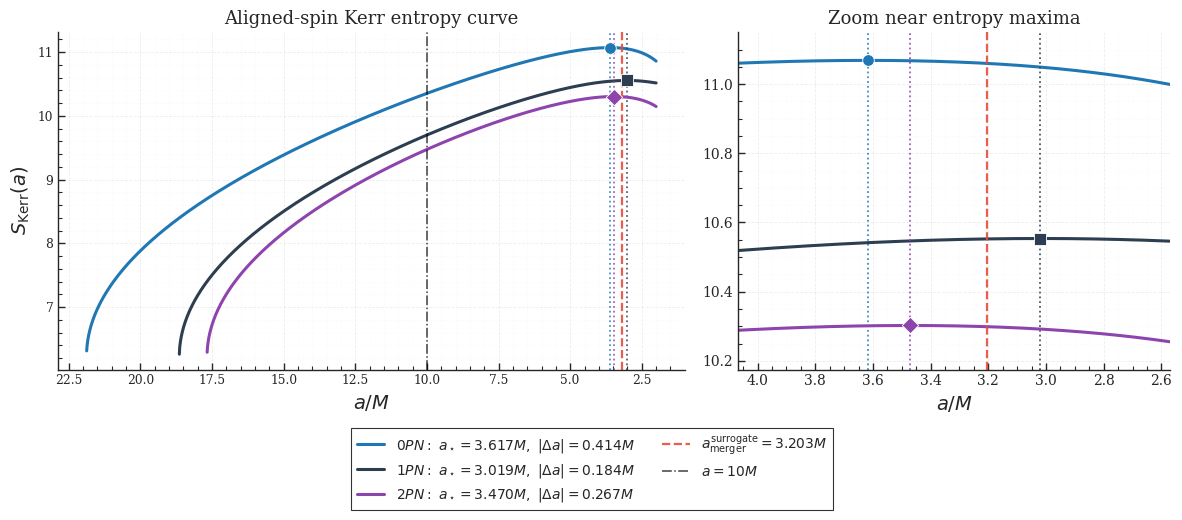

In [12]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})


pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}

curve_inputs = {
    "0PN": {
        "a": curve_0PN["a"],
        "S": curve_0PN["S_Kerr_0PN"],
    },
    "1PN": {
        "a": curve_1PN["a"],
        "S": curve_1PN["S_Kerr_1PN"],
    },
    "2PN": {
        "a": curve_2PN["a"],
        "S": curve_2PN["S_Kerr_2PN"],
    },
}

# ============================================================
# Figure
# ============================================================

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = []

# Include merger separation in the zoom region if it exists
if "a_merger" in globals():
    focus_a_values.append(a_merger)

# ============================================================
# Main panel
# ============================================================

for pn_label in pn_labels:

    a = np.asarray(curve_inputs[pn_label]["a"], dtype=float)
    S = np.asarray(curve_inputs[pn_label]["S"], dtype=float)

    valid_mask = (
        np.isfinite(a)
        & np.isfinite(S)
    )

    a_valid = a[valid_mask]
    S_valid = S[valid_mask]

    sort_idx = np.argsort(a_valid)

    a_sorted = a_valid[sort_idx]
    S_sorted = S_valid[sort_idx]

    if len(a_sorted) == 0:
        raise RuntimeError(f"No finite data found for {pn_label}.")

    idx_star = np.nanargmax(S_sorted)

    a_star = a_sorted[idx_star]
    S_star = S_sorted[idx_star]

    focus_a_values.append(a_star)

    curve_data[pn_label] = {
        "a": a_sorted,
        "S": S_sorted,
        "a_star": a_star,
        "S_star": S_star,
    }

    delta_a_abs = abs(a_star - a_merger)

    label_i = (
    fr"${pn_label}:\ "
    fr"a_\star={a_star:.3f}M,\ "
    fr"|\Delta a|={delta_a_abs:.3f}M$"
    )

    ax.plot(
        a_sorted,
        S_sorted,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_star,
        S_star,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_star,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

# Optional surrogate merger line
if "a_merger" in globals():
    ax.axvline(
        a_merger,
        color="#e74c3c",
        linestyle="--",
        lw=1.6,
        alpha=0.9,
        label=fr"$a_{{\rm merger}}^{{\rm surrogate}}={a_merger:.3f}M$"
    )

# Optional reference line at a = 10M
ax.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75,
    label=r"$a=10M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a/M$")
ax.set_ylabel(r"$S_{\rm Kerr}(a)$")
ax.set_title("Aligned-spin Kerr entropy curve")

# ============================================================
# Zoom region
# ============================================================

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:

    a_vals = curve_data[pn_label]["a"]
    S_vals = curve_data[pn_label]["S"]

    focus_mask = (
        (a_vals >= x_low)
        & (a_vals <= x_high)
        & np.isfinite(S_vals)
    )

    y_focus_values.extend(S_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

if len(y_focus_values) == 0 or not np.any(np.isfinite(y_focus_values)):
    raise RuntimeError(
        "No finite entropy values found in the zoom region. "
        "Try increasing x_margin."
    )

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)

if np.isclose(ymax_focus, ymin_focus):
    y_margin = 0.01 * abs(ymax_focus)
else:
    y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:

    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["S"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_star"],
        curve_data[pn_label]["S_star"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_star"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

if "a_merger" in globals():
    axz.axvline(
        a_merger,
        color="#e74c3c",
        linestyle="--",
        lw=1.6,
        alpha=0.9
    )

axz.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a/M$")
axz.set_title("Zoom near entropy maxima")
axz.tick_params(axis="both", labelsize=10)

# ============================================================
# Styling
# ============================================================

for axis in [ax, axz]:

    axis.minorticks_on()

    axis.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )

    axis.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.4,
        alpha=0.18
    )

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2
)

sns.despine()

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

Padè

In [13]:
def pade_2_1(v, p0, p1, p2, q1):
    v = np.asarray(v, dtype=float)
    return (p0 + p1*v + p2*v**2) / (1.0 + q1*v)

def fit_pade_2_1(v_data, y_data, y_name="y"):
    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = np.isfinite(v_data) & np.isfinite(y_data)

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) < 5:
        raise RuntimeError(f"Not enough valid points to fit {y_name}.")

    p2_guess, p1_guess, p0_guess = np.polyfit(v_fit, y_fit, deg=2)

    initial_guess = [
        p0_guess,
        p1_guess,
        p2_guess,
        0.0
    ]

    popt, pcov = curve_fit(
        pade_2_1,
        v_fit,
        y_fit,
        p0=initial_guess,
        maxfev=50000
    )

    return popt, pcov

def extrapolate_entropy_maximum_for_order(
    curve,
    order_label,
    M_col,
    J_col,
    S_col,
    chi_col,
    a_merger,
    a_fit_min=10.0,
    a_fit_max=40.0,
    a_ext_min=1.0,
    a_ext_max=10.0,
    n_ext=3000
):
   
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        np.isfinite(curve[S_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) < 5:
        raise RuntimeError(
            f"{order_label}: not enough points in the fit window."
        )

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    popt_M, pcov_M = fit_pade_2_1(
        v_fit,
        M_fit,
        y_name=f"{order_label} M"
    )

    popt_J, pcov_J = fit_pade_2_1(
        v_fit,
        J_fit,
        y_name=f"{order_label} J"
    )

    a_ext = np.linspace(a_ext_max, a_ext_min, n_ext)
    v_ext = 1.0 / np.sqrt(a_ext)

    M_ext = pade_2_1(v_ext, *popt_M)
    J_ext = pade_2_1(v_ext, *popt_J)

    S_ext, chi_ext = kerr_entropy(
        M_ext,
        J_ext,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_ext)
        &
        np.isfinite(M_ext)
        &
        np.isfinite(J_ext)
        &
        np.isfinite(S_ext)
        &
        np.isfinite(chi_ext)
        &
        (M_ext > 0.0)
        &
        (np.abs(chi_ext) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError(
            f"{order_label}: no physical points in the extrapolated region."
        )

    a_phys = a_ext[physical_mask]
    M_phys = M_ext[physical_mask]
    J_phys = J_ext[physical_mask]
    S_phys = S_ext[physical_mask]
    chi_phys = chi_ext[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = a_phys[idx_star]
    M_star = M_phys[idx_star]
    J_star = J_phys[idx_star]
    chi_star = chi_phys[idx_star]
    S_star = S_phys[idx_star]

    delta_a = a_star - a_merger
    rel_delta_a = delta_a / a_merger

    extrapolation_df = pd.DataFrame({
        "a": a_ext,
        "v": v_ext,
        "M_ext": M_ext,
        "J_ext": J_ext,
        "chi_ext": chi_ext,
        "S_ext": S_ext,
        "physical": physical_mask,
        "PN_order": order_label,
    })

    result = {
        "PN_order": order_label,

        "a_star": a_star,
        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,

        "a_merger": a_merger,
        "delta_a": delta_a,
        "abs_delta_a": abs(delta_a),
        "relative_delta_a": rel_delta_a,
        "abs_relative_delta_a": abs(rel_delta_a),

        "popt_M": popt_M,
        "popt_J": popt_J,

        "a_fit_min": a_fit_min,
        "a_fit_max": a_fit_max,
        "a_ext_min": a_ext_min,
        "a_ext_max": a_ext_max,

        "fit_data": fit_data,
        "extrapolation": extrapolation_df,
    }

    return result

pn_orders = [
    {
        "label": "0PN",
        "curve": curve_0PN,
        "M_col": "M_tot_0PN",
        "J_col": "J_tot_abs_0PN",
        "S_col": "S_Kerr_0PN",
        "chi_col": "chi_Kerr_0PN",
    },
    {
        "label": "1PN",
        "curve": curve_1PN,
        "M_col": "M_tot_1PN",
        "J_col": "J_tot_abs_1PN",
        "S_col": "S_Kerr_1PN",
        "chi_col": "chi_Kerr_1PN",
    },
    {
        "label": "2PN",
        "curve": curve_2PN,
        "M_col": "M_tot_2PN",
        "J_col": "J_tot_abs_2PN",
        "S_col": "S_Kerr_2PN",
        "chi_col": "chi_Kerr_2PN",
    },
]

pade_results = {}
summary_rows = []

for item in pn_orders:
    label = item["label"]


    result = extrapolate_entropy_maximum_for_order(
        curve=item["curve"],
        order_label=label,
        M_col=item["M_col"],
        J_col=item["J_col"],
        S_col=item["S_col"],
        chi_col=item["chi_col"],
        a_merger=a_merger,
        a_fit_min=10.0,
        a_fit_max=40.0,
        a_ext_min=2.0,
        a_ext_max=10.0,
        n_ext=10000
    )

    pade_results[label] = result

    summary_rows.append({
        "PN_order": label,
        "a_star": result["a_star"],
        "a_merger": result["a_merger"],
        "delta_a": result["delta_a"],
        "abs_delta_a": result["abs_delta_a"],
        "relative_delta_a": result["relative_delta_a"],
        "abs_relative_delta_a": result["abs_relative_delta_a"],
        "M_star": result["M_star"],
        "J_star": result["J_star"],
        "chi_star": result["chi_star"],
        "S_star": result["S_star"],
    })

delta_a_summary = pd.DataFrame(summary_rows)

display(delta_a_summary)

/home/giacomo/Thesis/Entropy-conjecture/.venv/lib/python3.12/site-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


,PN_order,a_star,a_merger,delta_a,abs_delta_a,relative_delta_a,abs_relative_delta_a,M_star,J_star,chi_star,S_star
0,0PN,3.618562,3.202915,0.415647,0.415647,0.129771,0.129771,0.975472,0.499216,0.524638,11.068581
1,1PN,3.374537,3.202915,0.171623,0.171623,0.053583,0.053583,0.978921,0.635441,0.663101,10.528058
2,2PN,3.558556,3.202915,0.355641,0.355641,0.111037,0.111037,0.983530,0.696319,0.719835,10.296886


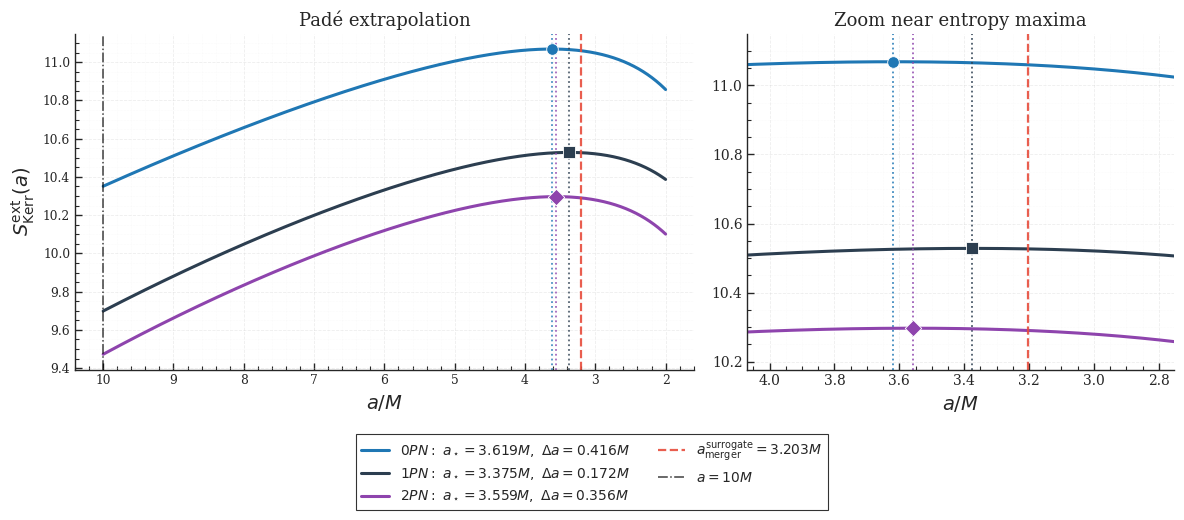

In [14]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = [a_merger]


for pn_label in pn_labels:

    result = pade_results[pn_label]
    extrap = result["extrapolation"]

    a_pade = extrap["a"].to_numpy()
    S_pade = extrap["S_ext"].to_numpy()

    a_star = result["a_star"]
    delta_a = result["delta_a"]

    sort_idx = np.argsort(a_pade)
    a_sorted = a_pade[sort_idx]
    S_sorted = S_pade[sort_idx]

    valid_interp_mask = (
        np.isfinite(a_sorted)
        &
        np.isfinite(S_sorted)
    )

    a_sorted_valid = a_sorted[valid_interp_mask]
    S_sorted_valid = S_sorted[valid_interp_mask]

    y_at_star = np.interp(
        a_star,
        a_sorted_valid,
        S_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_pade,
        "S": S_pade,
        "a_sorted_valid": a_sorted_valid,
        "S_sorted_valid": S_sorted_valid,
        "a_star": a_star,
        "y_star": y_at_star,
        "delta_a": delta_a,
    }

    focus_a_values.append(a_star)

    label_i = (
        fr"${pn_label}:\ "
        fr"a_\star={a_star:.3f}M,\ "
        fr"\Delta a={delta_a:.3f}M$"
    )

    ax.plot(
        a_pade,
        S_pade,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_star,
        y_at_star,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_star,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9,
    label=fr"$a_{{\rm merger}}^{{\rm surrogate}}={a_merger:.3f}M$"
)

ax.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75,
    label=r"$a=10M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a/M$")
ax.set_ylabel(r"$S_{\rm Kerr}^{\rm ext}(a)$")
ax.set_title("Padé extrapolation")

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45
x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:

    a_vals = curve_data[pn_label]["a_sorted_valid"]
    S_vals = curve_data[pn_label]["S_sorted_valid"]

    focus_mask = (
        (a_vals >= x_low)
        &
        (a_vals <= x_high)
    )

    y_focus_values.extend(S_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

if len(y_focus_values) == 0 or not np.any(np.isfinite(y_focus_values)):
    raise RuntimeError(
        "No finite entropy values found in the zoom region. "
        "Try increasing x_margin."
    )

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)

if np.isclose(ymax_focus, ymin_focus):
    y_margin = 0.01 * abs(ymax_focus)
else:
    y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:

    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["S"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_star"],
        curve_data[pn_label]["y_star"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_star"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9
)

axz.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)
axz.set_xlabel(r"$a/M$")
axz.set_title("Zoom near entropy maxima")
axz.tick_params(axis="both", labelsize=10)


for axis in [ax, axz]:
    axis.minorticks_on()
    axis.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )
    axis.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.4,
        alpha=0.18
    )

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2
)

sns.despine()

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

Taylor

In [15]:
def taylor_model_scaled(v, coeffs, v_center, v_scale):

    v = np.asarray(v, dtype=float)
    z = (v - v_center) / v_scale

    y = np.zeros_like(z, dtype=float)

    for k, ck in enumerate(coeffs):
        y += ck * z**k

    return y

def fit_taylor_scaled(v_data, y_data, degree=3, y_name="y"):


    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = (
        np.isfinite(v_data)
        &
        np.isfinite(y_data)
    )

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) <= degree + 1:
        raise RuntimeError(
            f"Not enough valid points to fit {y_name} "
            f"with Taylor degree {degree}."
        )

    v_center = np.mean(v_fit)
    v_scale = np.std(v_fit)

    if not np.isfinite(v_scale) or v_scale == 0.0:
        raise RuntimeError(f"Invalid v_scale while fitting {y_name}.")

    z_fit = (v_fit - v_center) / v_scale

    coeffs = np.polynomial.polynomial.polyfit(
        z_fit,
        y_fit,
        deg=degree
    )

    return coeffs, v_center, v_scale

def extrapolate_entropy_maximum_taylor_for_order(
    curve,
    order_label,
    M_col,
    J_col,
    S_col,
    chi_col,
    a_merger,
    degree=3,
    a_fit_min=10.0,
    a_fit_max=40.0,
    a_ext_min=1.0,
    a_ext_max=10.0,
    n_ext=3000
):
 
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        np.isfinite(curve[S_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) <= degree + 1:
        raise RuntimeError(
            f"{order_label}: not enough points in the fit window "
            f"for Taylor degree {degree}."
        )

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    coeffs_M, v_center_M, v_scale_M = fit_taylor_scaled(
        v_fit,
        M_fit,
        degree=degree,
        y_name=f"{order_label} M"
    )

    coeffs_J, v_center_J, v_scale_J = fit_taylor_scaled(
        v_fit,
        J_fit,
        degree=degree,
        y_name=f"{order_label} J"
    )


    a_ext = np.linspace(a_ext_max, a_ext_min, n_ext)
    v_ext = 1.0 / np.sqrt(a_ext)

    M_ext = taylor_model_scaled(
        v_ext,
        coeffs_M,
        v_center_M,
        v_scale_M
    )

    J_ext = taylor_model_scaled(
        v_ext,
        coeffs_J,
        v_center_J,
        v_scale_J
    )

    S_ext, chi_ext = kerr_entropy(
        M_ext,
        J_ext,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_ext)
        &
        np.isfinite(M_ext)
        &
        np.isfinite(J_ext)
        &
        np.isfinite(S_ext)
        &
        np.isfinite(chi_ext)
        &
        (M_ext > 0.0)
        &
        (np.abs(chi_ext) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError(
            f"{order_label}: no physical points in the extrapolated region."
        )

    a_phys = a_ext[physical_mask]
    M_phys = M_ext[physical_mask]
    J_phys = J_ext[physical_mask]
    S_phys = S_ext[physical_mask]
    chi_phys = chi_ext[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = a_phys[idx_star]
    M_star = M_phys[idx_star]
    J_star = J_phys[idx_star]
    chi_star = chi_phys[idx_star]
    S_star = S_phys[idx_star]

    delta_a = a_star - a_merger
    rel_delta_a = delta_a / a_merger

    extrapolation_df = pd.DataFrame({
        "a": a_ext,
        "v": v_ext,
        "M_extrap": M_ext,
        "J_extrap": J_ext,
        "chi_extrap": chi_ext,
        "ENT_extrap": S_ext,
        "physical": physical_mask,
        "PN_order": order_label,
    })

    result = {
        "PN_order": order_label,

        "a_max": a_star,
        "a_star": a_star,

        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,

        "a_merger": a_merger,
        "delta_a": delta_a,
        "abs_delta_a": abs(delta_a),
        "relative_delta_a": rel_delta_a,
        "abs_relative_delta_a": abs(rel_delta_a),

        "degree": degree,

        "coeffs_M": coeffs_M,
        "coeffs_J": coeffs_J,

        "v_center_M": v_center_M,
        "v_scale_M": v_scale_M,
        "v_center_J": v_center_J,
        "v_scale_J": v_scale_J,

        "a_fit_min": a_fit_min,
        "a_fit_max": a_fit_max,
        "a_ext_min": a_ext_min,
        "a_ext_max": a_ext_max,

        "fit_data": fit_data,
        "extrapolation": extrapolation_df,
    }

    return result

taylor_degree = 3

pn_orders = [
    {
        "label": "0PN",
        "curve": curve_0PN,
        "M_col": "M_tot_0PN",
        "J_col": "J_tot_abs_0PN",
        "S_col": "S_Kerr_0PN",
        "chi_col": "chi_Kerr_0PN",
    },
    {
        "label": "1PN",
        "curve": curve_1PN,
        "M_col": "M_tot_1PN",
        "J_col": "J_tot_abs_1PN",
        "S_col": "S_Kerr_1PN",
        "chi_col": "chi_Kerr_1PN",
    },
    {
        "label": "2PN",
        "curve": curve_2PN,
        "M_col": "M_tot_2PN",
        "J_col": "J_tot_abs_2PN",
        "S_col": "S_Kerr_2PN",
        "chi_col": "chi_Kerr_2PN",
    },
]

taylor_results_all = {}
taylor_curves_all = {}
summary_rows_taylor = []

for item in pn_orders:

    label = item["label"]

    result = extrapolate_entropy_maximum_taylor_for_order(
        curve=item["curve"],
        order_label=label,
        M_col=item["M_col"],
        J_col=item["J_col"],
        S_col=item["S_col"],
        chi_col=item["chi_col"],
        a_merger=a_merger,
        degree=taylor_degree,
        a_fit_min=10.0,
        a_fit_max=40.0,
        a_ext_min=2.0,
        a_ext_max=10.0,
        n_ext=10000
    )

    taylor_results_all[label] = result

    taylor_curves_all[label] = {
        "a_extrap": result["extrapolation"]["a"].to_numpy(),
        "M_extrap": result["extrapolation"]["M_extrap"].to_numpy(),
        "J_extrap": result["extrapolation"]["J_extrap"].to_numpy(),
        "chi_extrap": result["extrapolation"]["chi_extrap"].to_numpy(),
        "ENT_extrap": result["extrapolation"]["ENT_extrap"].to_numpy(),
        "physical": result["extrapolation"]["physical"].to_numpy(),
    }

    summary_rows_taylor.append({
        "PN_order": label,
        "degree": result["degree"],
        "a_max": result["a_max"],
        "a_star": result["a_star"],
        "a_merger": result["a_merger"],
        "delta_a": result["delta_a"],
        "abs_delta_a": result["abs_delta_a"],
        "relative_delta_a": result["relative_delta_a"],
        "abs_relative_delta_a": result["abs_relative_delta_a"],
        "M_star": result["M_star"],
        "J_star": result["J_star"],
        "chi_star": result["chi_star"],
        "S_star": result["S_star"],
    })


results_taylor_all_df = pd.DataFrame(summary_rows_taylor)

print()
print("============================================================")
print("Summary: Taylor extrapolation, delta_a by PN order")
print("============================================================")

display(results_taylor_all_df)


Summary: Taylor extrapolation, delta_a by PN order


,PN_order,degree,a_max,a_star,a_merger,delta_a,abs_delta_a,relative_delta_a,abs_relative_delta_a,M_star,J_star,chi_star,S_star
0,0PN,3,3.389739,3.389739,3.202915,0.186824,0.186824,0.058329,0.058329,0.973816,0.059080,0.062299,11.905333
1,1PN,3,2.830483,2.830483,3.202915,-0.372432,0.372432,-0.116279,0.116279,0.976398,0.032154,0.033727,11.976789
2,2PN,3,2.610461,2.610461,3.202915,-0.592454,0.592454,-0.184973,0.184973,0.982900,0.007061,0.007309,12.140115


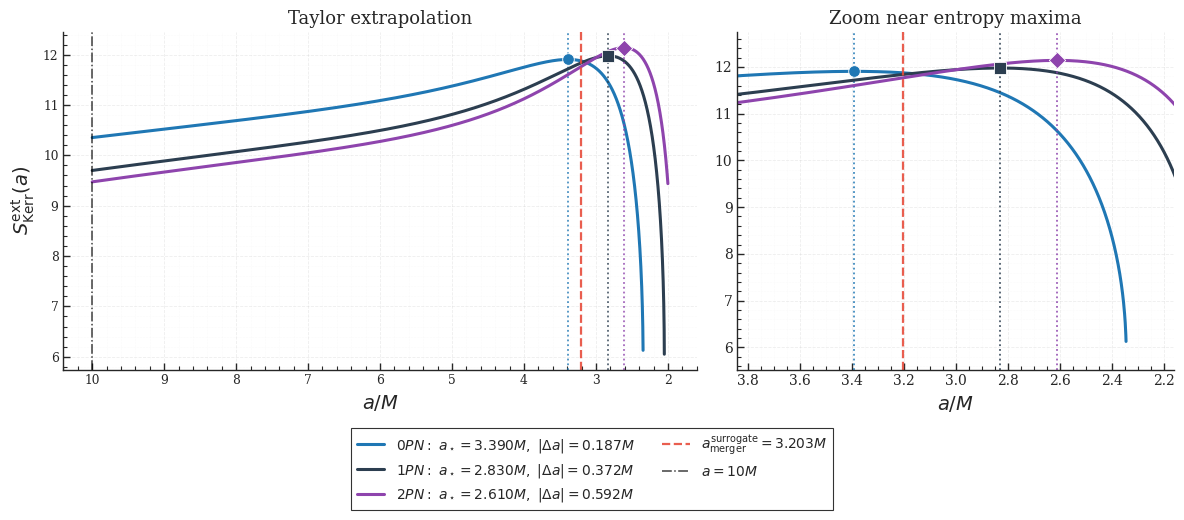

In [16]:
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

pn_labels = ["0PN", "1PN", "2PN"]

curve_colors = {
    "0PN": "#1f77b4",
    "1PN": "#2c3e50",
    "2PN": "#8e44ad",
}

markers = {
    "0PN": "o",
    "1PN": "s",
    "2PN": "D",
}


if "abs_delta_a" not in results_taylor_all_df.columns:
    results_taylor_all_df["abs_delta_a"] = np.abs(
        results_taylor_all_df["delta_a"]
    )

if "abs_relative_delta_a" not in results_taylor_all_df.columns:
    results_taylor_all_df["abs_relative_delta_a"] = np.abs(
        results_taylor_all_df["relative_delta_a"]
    )

fig, (ax, axz) = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1.45, 1.0]}
)

curve_data = {}
focus_a_values = [a_merger]

for pn_label in pn_labels:

    row = results_taylor_all_df.loc[
        results_taylor_all_df["PN_order"] == pn_label
    ].iloc[0]

    a_taylor = taylor_curves_all[pn_label]["a_extrap"]
    S_taylor = taylor_curves_all[pn_label]["ENT_extrap"]

    a_star = row["a_max"]
    abs_delta_a = row["abs_delta_a"]

    sort_idx = np.argsort(a_taylor)

    a_sorted = a_taylor[sort_idx]
    S_sorted = S_taylor[sort_idx]

    valid_interp_mask = (
        np.isfinite(a_sorted)
        &
        np.isfinite(S_sorted)
    )

    a_sorted_valid = a_sorted[valid_interp_mask]
    S_sorted_valid = S_sorted[valid_interp_mask]

    y_at_star = np.interp(
        a_star,
        a_sorted_valid,
        S_sorted_valid
    )

    curve_data[pn_label] = {
        "a": a_taylor,
        "S": S_taylor,
        "a_sorted_valid": a_sorted_valid,
        "S_sorted_valid": S_sorted_valid,
        "a_star": a_star,
        "y_star": y_at_star,
        "abs_delta_a": abs_delta_a,
    }

    focus_a_values.append(a_star)

    delta_a_abs = abs(a_star - a_merger)

    label_i = (
    fr"${pn_label}:\ "
    fr"a_\star={a_star:.3f}M,\ "
    fr"|\Delta a|={delta_a_abs:.3f}M$"
    )

    ax.plot(
        a_taylor,
        S_taylor,
        color=curve_colors[pn_label],
        lw=2.2,
        label=label_i
    )

    ax.scatter(
        a_star,
        y_at_star,
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    ax.axvline(
        a_star,
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.8
    )

ax.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9,
    label=fr"$a_{{\rm merger}}^{{\rm surrogate}}={a_merger:.3f}M$"
)

ax.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75,
    label=r"$a=10M$"
)

ax.invert_xaxis()
ax.set_xlabel(r"$a/M$")
ax.set_ylabel(r"$S_{\rm Kerr}^{\rm ext}(a)$")
ax.set_title("Taylor extrapolation")

a_focus_min = min(focus_a_values)
a_focus_max = max(focus_a_values)

x_margin = 0.45

x_low = a_focus_min - x_margin
x_high = a_focus_max + x_margin

y_focus_values = []

for pn_label in pn_labels:

    a_vals = curve_data[pn_label]["a_sorted_valid"]
    S_vals = curve_data[pn_label]["S_sorted_valid"]

    focus_mask = (
        (a_vals >= x_low)
        &
        (a_vals <= x_high)
    )

    y_focus_values.extend(S_vals[focus_mask])

y_focus_values = np.asarray(y_focus_values, dtype=float)

if len(y_focus_values) == 0 or not np.any(np.isfinite(y_focus_values)):
    raise RuntimeError(
        "No finite entropy values found in the zoom region. "
        "Try increasing x_margin."
    )

ymin_focus = np.nanmin(y_focus_values)
ymax_focus = np.nanmax(y_focus_values)

if np.isclose(ymax_focus, ymin_focus):
    y_margin = 0.01 * abs(ymax_focus)
else:
    y_margin = 0.10 * (ymax_focus - ymin_focus)

for pn_label in pn_labels:

    axz.plot(
        curve_data[pn_label]["a"],
        curve_data[pn_label]["S"],
        color=curve_colors[pn_label],
        lw=2.2
    )

    axz.scatter(
        curve_data[pn_label]["a_star"],
        curve_data[pn_label]["y_star"],
        marker=markers[pn_label],
        s=70,
        color=curve_colors[pn_label],
        zorder=5,
        edgecolor="white",
        linewidth=0.6
    )

    axz.axvline(
        curve_data[pn_label]["a_star"],
        color=curve_colors[pn_label],
        linestyle=":",
        lw=1.3,
        alpha=0.85
    )

axz.axvline(
    a_merger,
    color="#e74c3c",
    linestyle="--",
    lw=1.6,
    alpha=0.9
)

axz.axvline(
    10.0,
    color="black",
    linestyle="-.",
    lw=1.1,
    alpha=0.75
)

axz.set_xlim(x_high, x_low)
axz.set_ylim(ymin_focus - y_margin, ymax_focus + y_margin)

axz.set_xlabel(r"$a/M$")
axz.set_title("Zoom near entropy maxima")
axz.tick_params(axis="both", labelsize=10)

for axis in [ax, axz]:

    axis.minorticks_on()

    axis.grid(
        True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.35
    )

    axis.grid(
        True,
        which="minor",
        linestyle=":",
        linewidth=0.4,
        alpha=0.18
    )

handles, labels = ax.get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    frameon=True,
    shadow=False,
    fancybox=False,
    edgecolor="black",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2
)

sns.despine()

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

SPIN HEATMAPS

In [15]:
master_data_dir = Path("data/aligned_spin_analysis")
master_data_dir.mkdir(parents=True, exist_ok=True)

MASTER_HEATMAP_PATH = master_data_dir / "master_aligned_spin_heatmap_results.csv"

def update_master_heatmap_results(
    current_df,
    method,
    q_value=None,
    master_path=MASTER_HEATMAP_PATH,
    overwrite_same_grid=True
):


    df_new = current_df.copy()

    df_new["method"] = method

    if "q" not in df_new.columns:
        if q_value is None:
            raise ValueError("q_value must be provided if current_df has no 'q' column.")
        df_new["q"] = float(q_value)

    required_cols = [
        "method",
        "q",
        "chi1_z",
        "chi2_z",
        "PN_order",
        "a_star",
        "a_merger",
        "abs_delta_a",
    ]

    missing = [
        col for col in required_cols
        if col not in df_new.columns
    ]

    if missing:
        raise KeyError(f"Missing columns in current_df: {missing}")

    for col in ["q", "chi1_z", "chi2_z", "a_star", "a_merger", "abs_delta_a"]:
        df_new[col] = pd.to_numeric(
            df_new[col],
            errors="coerce"
        )

    if "delta_a_signed" not in df_new.columns:
        df_new["delta_a_signed"] = (
            df_new["a_star"]
            -
            df_new["a_merger"]
        )
    else:
        df_new["delta_a_signed"] = pd.to_numeric(
            df_new["delta_a_signed"],
            errors="coerce"
        )

    df_new["abs_delta_a"] = np.abs(df_new["delta_a_signed"])
    df_new["q_key"] = np.round(df_new["q"].astype(float), 12)
    df_new["chi1_key"] = np.round(df_new["chi1_z"].astype(float), 12)
    df_new["chi2_key"] = np.round(df_new["chi2_z"].astype(float), 12)

    df_new["updated_at"] = datetime.now().isoformat(timespec="seconds")

    if master_path.exists():
        df_old = pd.read_csv(master_path)
    else:
        df_old = pd.DataFrame()

    if len(df_old) > 0:
        for col in ["q", "chi1_z", "chi2_z", "a_star", "a_merger", "abs_delta_a"]:
            if col in df_old.columns:
                df_old[col] = pd.to_numeric(
                    df_old[col],
                    errors="coerce"
                )

        if "q_key" not in df_old.columns:
            df_old["q_key"] = np.round(df_old["q"].astype(float), 12)

        if "chi1_key" not in df_old.columns:
            df_old["chi1_key"] = np.round(df_old["chi1_z"].astype(float), 12)

        if "chi2_key" not in df_old.columns:
            df_old["chi2_key"] = np.round(df_old["chi2_z"].astype(float), 12)

        df_master = pd.concat(
            [df_old, df_new],
            ignore_index=True
        )
    else:
        df_master = df_new.copy()

    if overwrite_same_grid:
        df_master = (
            df_master
            .sort_values("updated_at")
            .drop_duplicates(
                subset=[
                    "method",
                    "q_key",
                    "chi1_key",
                    "chi2_key",
                    "PN_order",
                ],
                keep="last"
            )
            .reset_index(drop=True)
        )

    df_master.to_csv(
        master_path,
        index=False
    )

    print()
    print("Master heatmap dataframe updated.")
    print("---------------------------------")
    print(f"Saved to: {master_path}")
    print(f"Total rows: {len(df_master)}")
    print("Available mass ratios:")
    print(sorted(df_master["q"].dropna().unique()))

    return df_master

Padé heatmaps q=1:   0%|          | 0/400 [00:00<?, ?it/s]


Master heatmap dataframe updated.
---------------------------------
Saved to: data/aligned_spin_analysis/master_aligned_spin_heatmap_results.csv
Total rows: 37590
Available mass ratios:
[0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]


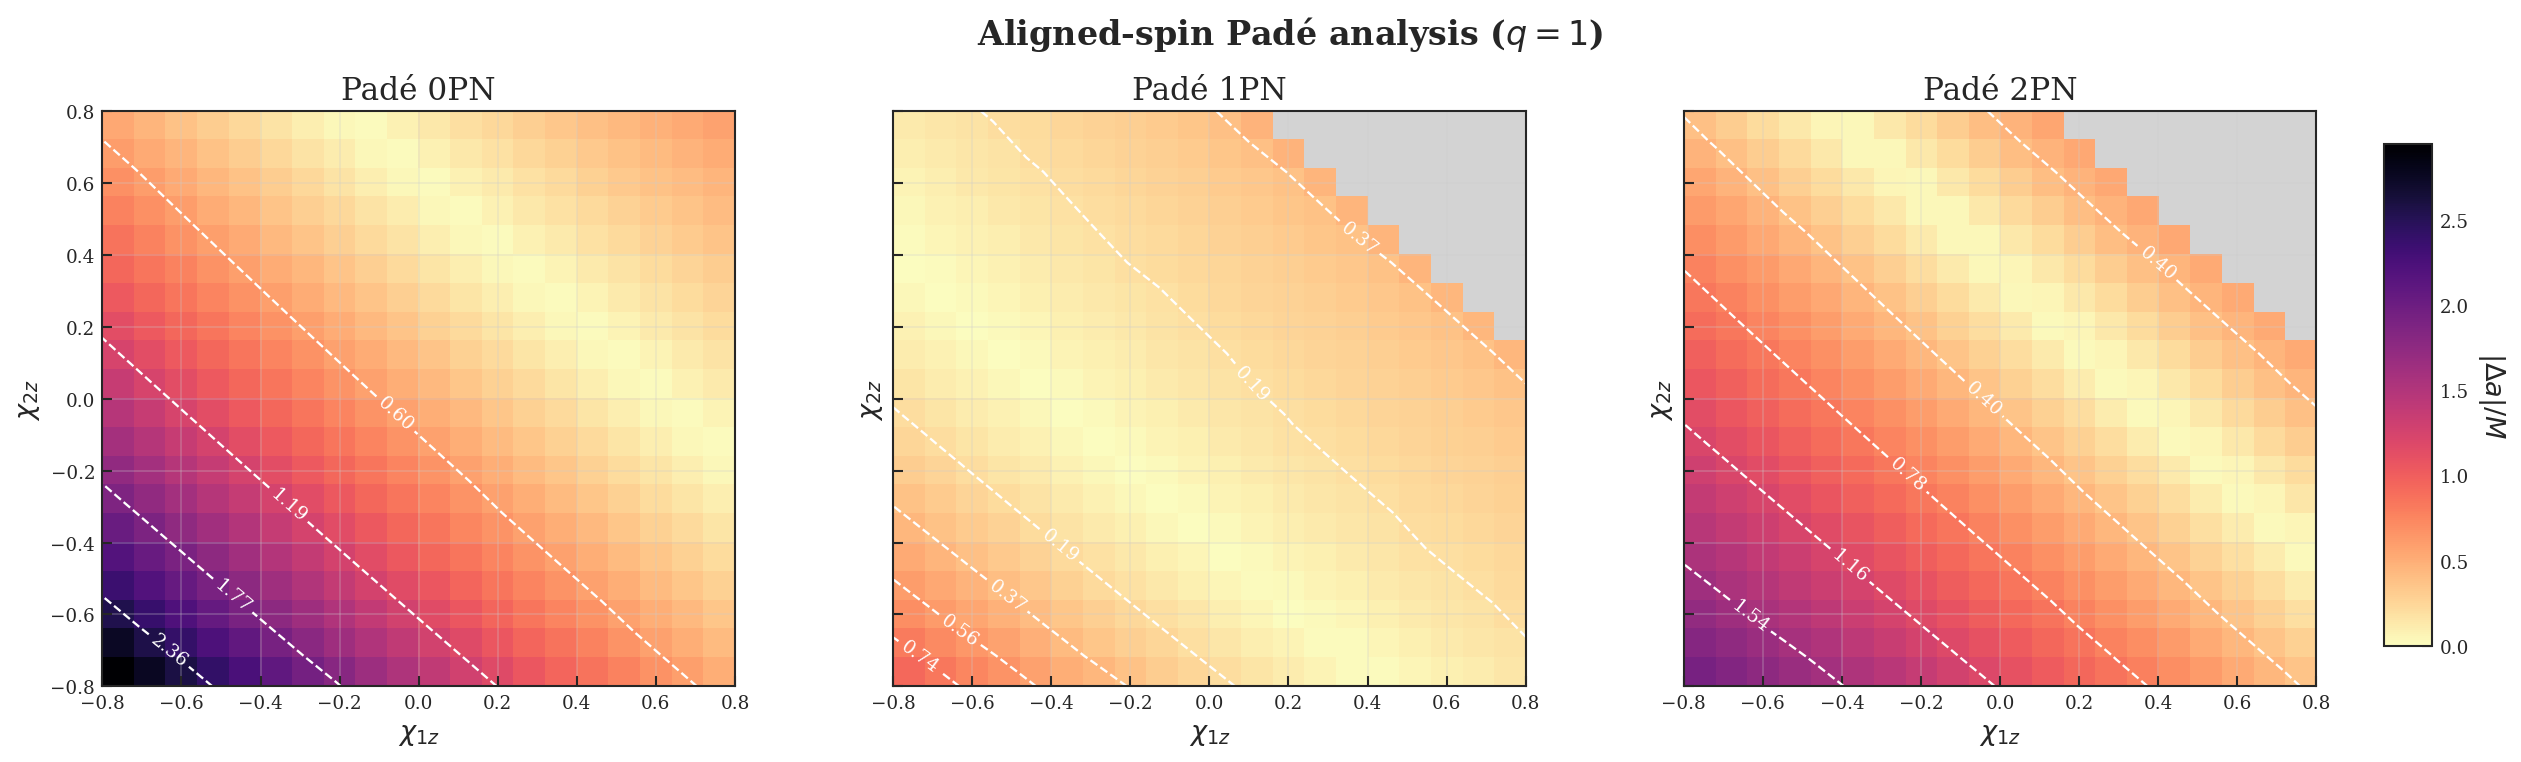

In [21]:
q_pade = 1

n_points_p = 20
chi_range_p = np.linspace(-0.8, 0.8, n_points_p)

a_curve = np.linspace(100.0, 10, 1000)

a_fit_min = 10.0
a_fit_max = 40.0

a_extrap_min = 2.0
a_extrap_max = 10.0
n_extrap = 10000

dt_sur = 0.1
f_low_sur = 0.0


plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

def pade_2_1(v, p0, p1, p2, q1):
    v = np.asarray(v, dtype=float)
    return (p0 + p1*v + p2*v**2) / (1.0 + q1*v)

def fit_pade_2_1(v_data, y_data, y_name="y"):
    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = (
        np.isfinite(v_data)
        &
        np.isfinite(y_data)
    )

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) < 5:
        raise RuntimeError(f"Not enough valid points to fit {y_name}.")

    p2_guess, p1_guess, p0_guess = np.polyfit(v_fit, y_fit, deg=2)

    p0 = [
        p0_guess,
        p1_guess,
        p2_guess,
        0.0
    ]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", OptimizeWarning)

        popt, pcov = curve_fit(
            pade_2_1,
            v_fit,
            y_fit,
            p0=p0,
            maxfev=50000
        )

    return popt, pcov

if "aligned_merger_cache" not in globals():
    aligned_merger_cache = {}

def get_aligned_merger_separation_cached(q_input, chi1_z, chi2_z):
    key = (
        round(float(q_input), 12),
        round(float(chi1_z), 12),
        round(float(chi2_z), 12),
    )

    if key in aligned_merger_cache:
        return aligned_merger_cache[key]

    try:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref_start=20.0,
            omega_ref_factor=1.05,
            max_attempts=30,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    except TypeError:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref=20.0,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    a_merger_val = float(merger_result["a_merger"])

    aligned_merger_cache[key] = a_merger_val

    return a_merger_val

def build_aligned_curves_for_heatmap(q_input, chi1_z, chi2_z):
    params = aligned_binary_parameters(
        q_input,
        chi1_z,
        chi2_z
    )

    curve_0PN = aligned_entropy_curve_0PN(
        a_curve,
        params
    )

    curve_1PN = aligned_entropy_curve_1PN(
        a_curve,
        params
    )

    curve_2PN = aligned_entropy_curve_2PN(
        a_curve,
        params
    )

    return {
        "0PN": curve_0PN,
        "1PN": curve_1PN,
        "2PN": curve_2PN,
    }

def get_abs_delta_a_pade_correct(
    curve,
    M_col,
    J_col,
    a_merger
):


    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) < 5:
        raise RuntimeError("Not enough points in the fit region.")

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    popt_M, _ = fit_pade_2_1(
        v_fit,
        M_fit,
        y_name=M_col
    )

    popt_J, _ = fit_pade_2_1(
        v_fit,
        J_fit,
        y_name=J_col
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    v_extrap = 1.0 / np.sqrt(a_extrap)

    M_extrap = pade_2_1(v_extrap, *popt_M)
    J_extrap = pade_2_1(v_extrap, *popt_J)

    S_extrap, chi_extrap = kerr_entropy(
        M_extrap,
        J_extrap,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_extrap)
        &
        np.isfinite(M_extrap)
        &
        np.isfinite(J_extrap)
        &
        np.isfinite(S_extrap)
        &
        np.isfinite(chi_extrap)
        &
        (M_extrap > 0.0)
        &
        (np.abs(chi_extrap) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError("No physical points in the extrapolated region.")

    a_phys = a_extrap[physical_mask]
    S_phys = S_extrap[physical_mask]
    M_phys = M_extrap[physical_mask]
    J_phys = J_extrap[physical_mask]
    chi_phys = chi_extrap[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = float(a_phys[idx_star])
    M_star = float(M_phys[idx_star])
    J_star = float(J_phys[idx_star])
    chi_star = float(chi_phys[idx_star])
    S_star = float(S_phys[idx_star])

    abs_delta_a = abs(a_star - a_merger)

    return {
        "a_star": a_star,
        "abs_delta_a": abs_delta_a,
        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,
    }


chi1_grid_p, chi2_grid_p = np.meshgrid(chi_range_p,chi_range_p)

delta_r_0PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
delta_r_1PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
delta_r_2PN = np.full_like(chi1_grid_p, np.nan, dtype=float)

a_star_0PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
a_star_1PN = np.full_like(chi1_grid_p, np.nan, dtype=float)
a_star_2PN = np.full_like(chi1_grid_p, np.nan, dtype=float)

a_merger_matrix = np.full_like(chi1_grid_p, np.nan, dtype=float)

failure_rows_pade = []



total_iterations = n_points_p * n_points_p
pbar = tqdm(
    total=total_iterations,
    desc=f"Padé heatmaps q={q_pade}"
)

for i in range(n_points_p):
    for j in range(n_points_p):

        chi1_val = float(chi1_grid_p[i, j])
        chi2_val = float(chi2_grid_p[i, j])

        try:
            a_merger_val = get_aligned_merger_separation_cached(
                q_input=q_pade,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            a_merger_matrix[i, j] = a_merger_val

            curves = build_aligned_curves_for_heatmap(
                q_input=q_pade,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            # 0PN
            out_0PN = get_abs_delta_a_pade_correct(
                curve=curves["0PN"],
                M_col="M_tot_0PN",
                J_col="J_tot_abs_0PN",
                a_merger=a_merger_val
            )

            a_star_0PN[i, j] = out_0PN["a_star"]
            delta_r_0PN[i, j] = out_0PN["abs_delta_a"]

            # 1PN
            out_1PN = get_abs_delta_a_pade_correct(
                curve=curves["1PN"],
                M_col="M_tot_1PN",
                J_col="J_tot_abs_1PN",
                a_merger=a_merger_val
            )

            a_star_1PN[i, j] = out_1PN["a_star"]
            delta_r_1PN[i, j] = out_1PN["abs_delta_a"]

            # 2PN
            out_2PN = get_abs_delta_a_pade_correct(
                curve=curves["2PN"],
                M_col="M_tot_2PN",
                J_col="J_tot_abs_2PN",
                a_merger=a_merger_val
            )

            a_star_2PN[i, j] = out_2PN["a_star"]
            delta_r_2PN[i, j] = out_2PN["abs_delta_a"]

        except Exception as exc:
            failure_rows_pade.append({
                "q": q_pade,
                "chi1_z": chi1_val,
                "chi2_z": chi2_val,
                "error": repr(exc),
            })

        finally:
            pbar.update(1)

pbar.close()

failure_pade_df = pd.DataFrame(failure_rows_pade)

pade_heatmap_records = []

for i in range(n_points_p):
    for j in range(n_points_p):

        chi1_val = float(chi1_grid_p[i, j])
        chi2_val = float(chi2_grid_p[i, j])

        pade_heatmap_records.append({
            "q": q_pade,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "0PN",
            "a_merger": a_merger_matrix[i, j],
            "a_star": a_star_0PN[i, j],
            "abs_delta_a": delta_r_0PN[i, j],
        })

        pade_heatmap_records.append({
            "q": q_pade,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "1PN",
            "a_merger": a_merger_matrix[i, j],
            "a_star": a_star_1PN[i, j],
            "abs_delta_a": delta_r_1PN[i, j],
        })

        pade_heatmap_records.append({
            "q": q_pade,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "2PN",
            "a_merger": a_merger_matrix[i, j],
            "a_star": a_star_2PN[i, j],
            "abs_delta_a": delta_r_2PN[i, j],
        })

pade_heatmap_df = pd.DataFrame(pade_heatmap_records)

master_heatmap_results_df = update_master_heatmap_results(
    current_df=pade_heatmap_df,
    method="Padé",
    q_value=q_pade
)


pn_titles = ["0PN", "1PN", "2PN"]
delta_matrices = [
    delta_r_0PN,
    delta_r_1PN,
    delta_r_2PN,
]

all_delta_values = np.concatenate([
    delta_r_0PN[np.isfinite(delta_r_0PN)],
    delta_r_1PN[np.isfinite(delta_r_1PN)],
    delta_r_2PN[np.isfinite(delta_r_2PN)],
])

if len(all_delta_values) == 0:
    raise RuntimeError("No finite Padé heatmap values were produced.")

vmin = 0.0
vmax = np.nanmax(all_delta_values)

cmap = plt.cm.magma_r.copy()
cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.4),
    dpi=150,
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=0.06,
    right=0.88,
    bottom=0.13,
    top=0.84,
    wspace=0.25
)

cbar_ax = fig.add_axes([0.905, 0.18, 0.018, 0.62])

last_heatmap = None

for ax, pn_title, delta_matrix in zip(
    axes,
    pn_titles,
    delta_matrices
):

    delta_masked = np.ma.masked_invalid(delta_matrix)

    last_heatmap = ax.imshow(
        delta_masked,
        origin="lower",
        extent=(
            chi_range_p.min(),
            chi_range_p.max(),
            chi_range_p.min(),
            chi_range_p.max()
        ),
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    finite_vals = delta_matrix[np.isfinite(delta_matrix)]

    if len(finite_vals) > 1 and not np.isclose(
        np.nanmin(finite_vals),
        np.nanmax(finite_vals)
    ):

        contour_levels = np.linspace(
            np.nanmin(finite_vals),
            np.nanmax(finite_vals),
            6
        )

        contour_levels = contour_levels[
            np.isfinite(contour_levels)
        ]

        if len(np.unique(contour_levels)) >= 2:
            contours = ax.contour(
                chi1_grid_p,
                chi2_grid_p,
                delta_matrix,
                levels=contour_levels,
                colors="white",
                linestyles="--",
                linewidths=1.1
            )

            ax.clabel(
                contours,
                inline=True,
                fontsize=9,
                fmt=r"%.2f"
            )

    ax.set_xlabel(r"$\chi_{1z}$")
    ax.set_ylabel(r"$\chi_{2z}$")
    ax.set_title(rf"Padé {pn_title}")

    ax.set_xlim(chi_range_p.min(), chi_range_p.max())
    ax.set_ylim(chi_range_p.min(), chi_range_p.max())

cbar = fig.colorbar(
    last_heatmap,
    cax=cbar_ax
)

cbar.set_label(
    r"$|\Delta a|/M$",
    rotation=270,
    labelpad=18
)

fig.suptitle(
    rf"Aligned-spin Padé analysis ($q={q_pade}$)",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / f"padè_heatmaps_q_{q_pade:.3f}.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    output_dir / f"padè_heatmaps_q_{q_pade:.3f}.pdf",
    bbox_inches="tight"
)


plt.show()

Taylor heatmaps q=1:   0%|          | 0/400 [00:00<?, ?it/s]


Master heatmap dataframe updated.
---------------------------------
Saved to: data/aligned_spin_analysis/master_aligned_spin_heatmap_results.csv
Total rows: 38778
Available mass ratios:
[0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 1.0]


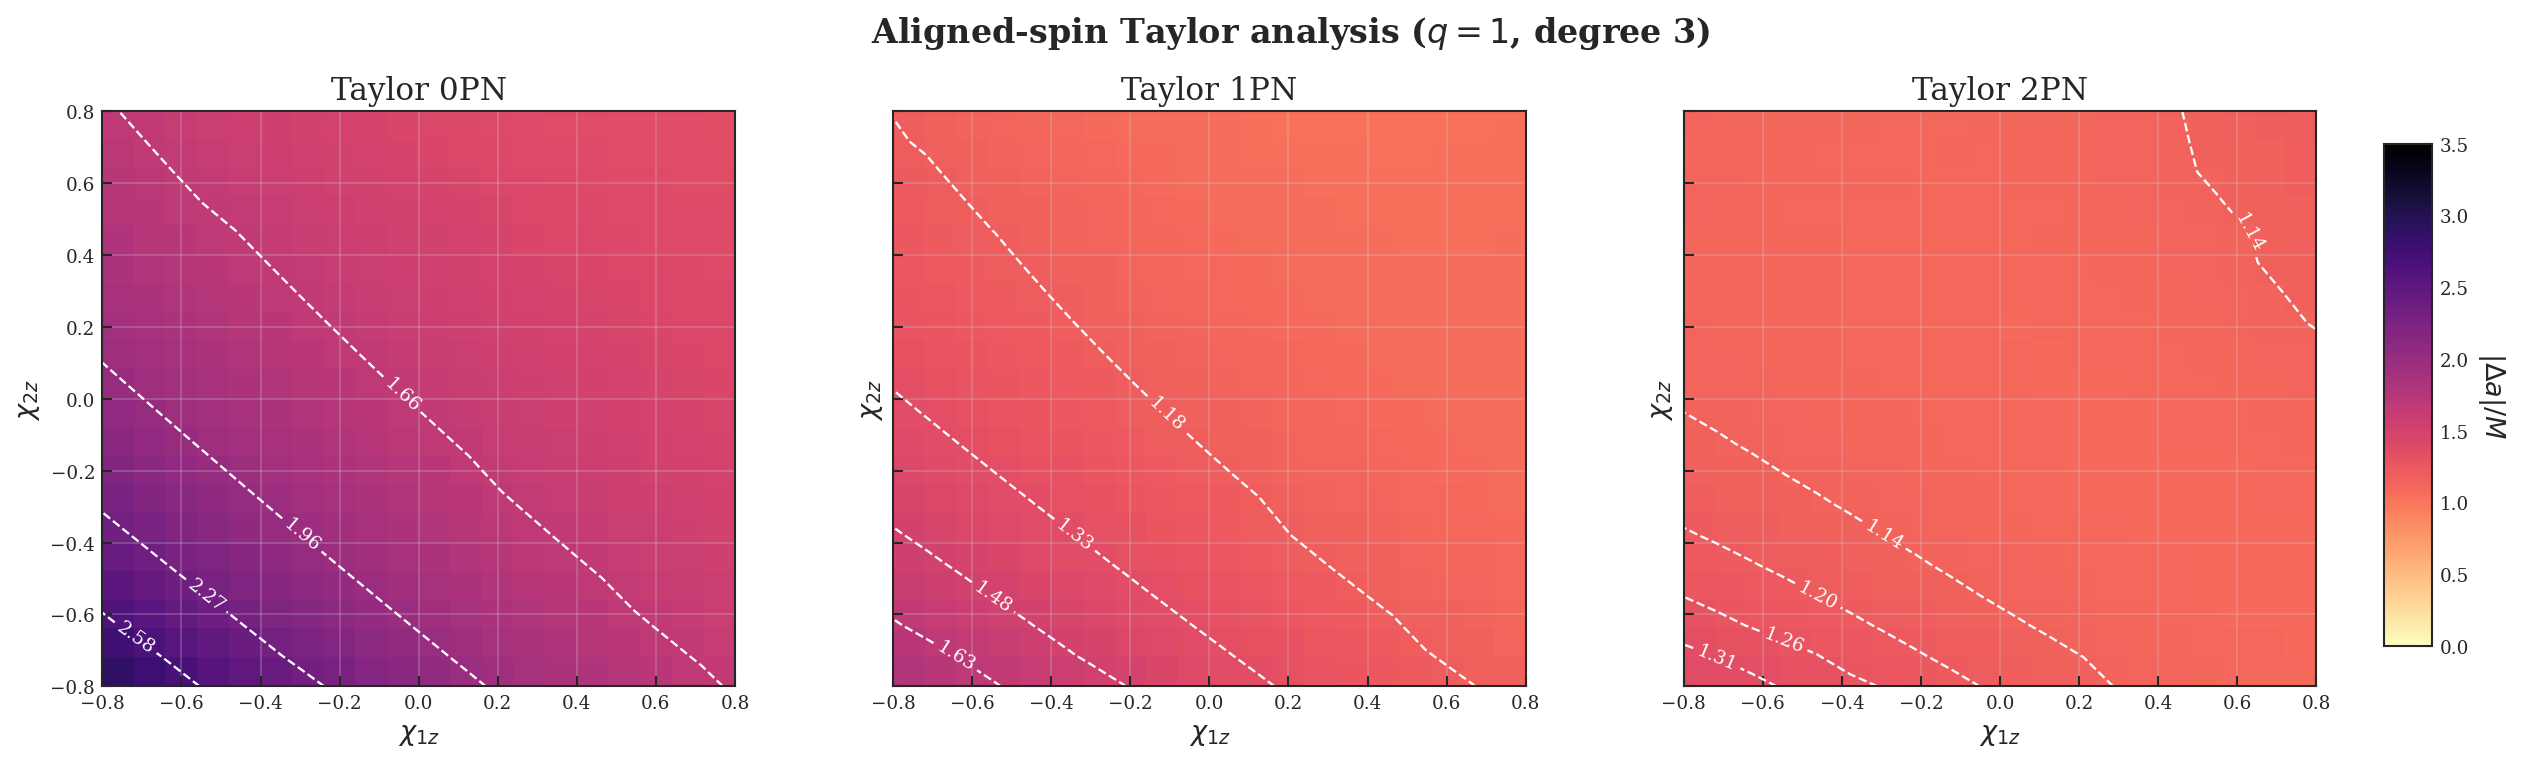

In [22]:
q_taylor = 1

n_points_t = 20
chi_range_t = np.linspace(-0.8, 0.8, n_points_t)

a_curve = np.linspace(100.0, 10, 10000)

a_fit_min = 10.0
a_fit_max = 40.0

a_extrap_min = 2.0
a_extrap_max = 10.0
n_extrap = 10000

taylor_degree = 3

dt_sur = 0.1
f_low_sur = 0.0


plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


def taylor_model_scaled_heatmap(v, coeffs, v_center, v_scale):

    v = np.asarray(v, dtype=float)
    z = (v - v_center) / v_scale

    y = np.zeros_like(z, dtype=float)

    for k, ck in enumerate(coeffs):
        y += ck * z**k

    return y

def fit_taylor_scaled_heatmap(v_data, y_data, degree=3, y_name="y"):

    v_data = np.asarray(v_data, dtype=float)
    y_data = np.asarray(y_data, dtype=float)

    valid = (
        np.isfinite(v_data)
        &
        np.isfinite(y_data)
    )

    v_fit = v_data[valid]
    y_fit = y_data[valid]

    if len(v_fit) <= degree + 1:
        raise RuntimeError(
            f"Not enough valid points to fit {y_name} "
            f"with Taylor degree {degree}."
        )

    v_center = np.mean(v_fit)
    v_scale = np.std(v_fit)

    if not np.isfinite(v_scale) or v_scale == 0.0:
        raise RuntimeError(f"Invalid v_scale while fitting {y_name}.")

    z_fit = (v_fit - v_center) / v_scale

    coeffs = np.polynomial.polynomial.polyfit(
        z_fit,
        y_fit,
        deg=degree
    )

    return coeffs, v_center, v_scale

if "aligned_merger_cache" not in globals():
    aligned_merger_cache = {}

def get_aligned_merger_separation_cached(q_input, chi1_z, chi2_z):
    key = (
        round(float(q_input), 12),
        round(float(chi1_z), 12),
        round(float(chi2_z), 12),
    )

    if key in aligned_merger_cache:
        return aligned_merger_cache[key]

    try:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref_start=20.0,
            omega_ref_factor=1.05,
            max_attempts=30,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    except TypeError:
        merger_result = estimate_merger_separation_from_surrogate(
            q_input=q_input,
            chi1_z=chi1_z,
            chi2_z=chi2_z,
            sur_wave_aligned=sur_wave_aligned,
            a_ref=20.0,
            f_low=f_low_sur,
            dt=dt_sur,
            peak_window=5,
            smooth_frequency=True,
            plot=False
        )

    a_merger_val = float(merger_result["a_merger"])

    aligned_merger_cache[key] = a_merger_val

    return a_merger_val

def build_aligned_curves_for_taylor_heatmap(q_input, chi1_z, chi2_z):
    params = aligned_binary_parameters(
        q_input,
        chi1_z,
        chi2_z
    )

    curve_0PN = aligned_entropy_curve_0PN(
        a_curve,
        params
    )

    curve_1PN = aligned_entropy_curve_1PN(
        a_curve,
        params
    )

    curve_2PN = aligned_entropy_curve_2PN(
        a_curve,
        params
    )

    return {
        "0PN": curve_0PN,
        "1PN": curve_1PN,
        "2PN": curve_2PN,
    }

def get_abs_delta_a_taylor_correct(
    curve,
    M_col,
    J_col,
    a_merger,
    degree=3
):
    
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        (curve["a"] >= a_fit_min)
        &
        (curve["a"] <= a_fit_max)
    )

    fit_data = curve.loc[fit_mask].copy()

    if len(fit_data) <= degree + 1:
        raise RuntimeError(
            f"Not enough points in the fit region for Taylor degree {degree}."
        )

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v").reset_index(drop=True)

    v_fit = fit_data["v"].to_numpy()
    M_fit = fit_data[M_col].to_numpy()
    J_fit = fit_data[J_col].to_numpy()

    coeffs_M, v_center_M, v_scale_M = fit_taylor_scaled_heatmap(
        v_fit,
        M_fit,
        degree=degree,
        y_name=M_col
    )

    coeffs_J, v_center_J, v_scale_J = fit_taylor_scaled_heatmap(
        v_fit,
        J_fit,
        degree=degree,
        y_name=J_col
    )

    a_extrap = np.linspace(a_extrap_max, a_extrap_min, n_extrap)
    v_extrap = 1.0 / np.sqrt(a_extrap)

    M_extrap = taylor_model_scaled_heatmap(
        v_extrap,
        coeffs_M,
        v_center_M,
        v_scale_M
    )

    J_extrap = taylor_model_scaled_heatmap(
        v_extrap,
        coeffs_J,
        v_center_J,
        v_scale_J
    )

    S_extrap, chi_extrap = kerr_entropy(
        M_extrap,
        J_extrap,
        return_chi=True
    )

    physical_mask = (
        np.isfinite(a_extrap)
        &
        np.isfinite(M_extrap)
        &
        np.isfinite(J_extrap)
        &
        np.isfinite(S_extrap)
        &
        np.isfinite(chi_extrap)
        &
        (M_extrap > 0.0)
        &
        (np.abs(chi_extrap) <= 1.0)
    )

    if not np.any(physical_mask):
        raise RuntimeError("No physical points in the extrapolated region.")

    a_phys = a_extrap[physical_mask]
    S_phys = S_extrap[physical_mask]
    M_phys = M_extrap[physical_mask]
    J_phys = J_extrap[physical_mask]
    chi_phys = chi_extrap[physical_mask]

    idx_star = int(np.nanargmax(S_phys))

    a_star = float(a_phys[idx_star])
    M_star = float(M_phys[idx_star])
    J_star = float(J_phys[idx_star])
    chi_star = float(chi_phys[idx_star])
    S_star = float(S_phys[idx_star])

    abs_delta_a = abs(a_star - a_merger)

    return {
        "a_star": a_star,
        "abs_delta_a": abs_delta_a,
        "M_star": M_star,
        "J_star": J_star,
        "chi_star": chi_star,
        "S_star": S_star,
    }


chi1_grid_t, chi2_grid_t = np.meshgrid(
    chi_range_t,
    chi_range_t
)

delta_taylor_0PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
delta_taylor_1PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
delta_taylor_2PN = np.full_like(chi1_grid_t, np.nan, dtype=float)

a_star_taylor_0PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
a_star_taylor_1PN = np.full_like(chi1_grid_t, np.nan, dtype=float)
a_star_taylor_2PN = np.full_like(chi1_grid_t, np.nan, dtype=float)

a_merger_taylor_matrix = np.full_like(chi1_grid_t, np.nan, dtype=float)

failure_rows_taylor = []

total_iterations = n_points_t * n_points_t

pbar = tqdm(
    total=total_iterations,
    desc=f"Taylor heatmaps q={q_taylor}"
)

for i in range(n_points_t):
    for j in range(n_points_t):

        chi1_val = float(chi1_grid_t[i, j])
        chi2_val = float(chi2_grid_t[i, j])

        try:
            a_merger_val = get_aligned_merger_separation_cached(
                q_input=q_taylor,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            a_merger_taylor_matrix[i, j] = a_merger_val

            curves = build_aligned_curves_for_taylor_heatmap(
                q_input=q_taylor,
                chi1_z=chi1_val,
                chi2_z=chi2_val
            )

            # 0PN
            out_0PN = get_abs_delta_a_taylor_correct(
                curve=curves["0PN"],
                M_col="M_tot_0PN",
                J_col="J_tot_abs_0PN",
                a_merger=a_merger_val,
                degree=taylor_degree
            )

            a_star_taylor_0PN[i, j] = out_0PN["a_star"]
            delta_taylor_0PN[i, j] = out_0PN["abs_delta_a"]

            # 1PN
            out_1PN = get_abs_delta_a_taylor_correct(
                curve=curves["1PN"],
                M_col="M_tot_1PN",
                J_col="J_tot_abs_1PN",
                a_merger=a_merger_val,
                degree=taylor_degree
            )

            a_star_taylor_1PN[i, j] = out_1PN["a_star"]
            delta_taylor_1PN[i, j] = out_1PN["abs_delta_a"]

            # 2PN
            out_2PN = get_abs_delta_a_taylor_correct(
                curve=curves["2PN"],
                M_col="M_tot_2PN",
                J_col="J_tot_abs_2PN",
                a_merger=a_merger_val,
                degree=taylor_degree
            )

            a_star_taylor_2PN[i, j] = out_2PN["a_star"]
            delta_taylor_2PN[i, j] = out_2PN["abs_delta_a"]

        except Exception as exc:
            failure_rows_taylor.append({
                "q": q_taylor,
                "chi1_z": chi1_val,
                "chi2_z": chi2_val,
                "error": repr(exc),
            })

        finally:
            pbar.update(1)

pbar.close()

failure_taylor_df = pd.DataFrame(failure_rows_taylor)

taylor_heatmap_records = []

for i in range(n_points_t):
    for j in range(n_points_t):

        chi1_val = float(chi1_grid_t[i, j])
        chi2_val = float(chi2_grid_t[i, j])

        taylor_heatmap_records.append({
            "q": q_taylor,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "0PN",
            "degree": taylor_degree,
            "a_merger": a_merger_taylor_matrix[i, j],
            "a_star": a_star_taylor_0PN[i, j],
            "abs_delta_a": delta_taylor_0PN[i, j],
        })

        taylor_heatmap_records.append({
            "q": q_taylor,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "1PN",
            "degree": taylor_degree,
            "a_merger": a_merger_taylor_matrix[i, j],
            "a_star": a_star_taylor_1PN[i, j],
            "abs_delta_a": delta_taylor_1PN[i, j],
        })

        taylor_heatmap_records.append({
            "q": q_taylor,
            "chi1_z": chi1_val,
            "chi2_z": chi2_val,
            "PN_order": "2PN",
            "degree": taylor_degree,
            "a_merger": a_merger_taylor_matrix[i, j],
            "a_star": a_star_taylor_2PN[i, j],
            "abs_delta_a": delta_taylor_2PN[i, j],
        })

taylor_heatmap_df = pd.DataFrame(taylor_heatmap_records)

master_heatmap_results_df = update_master_heatmap_results(
    current_df=taylor_heatmap_df,
    method="Taylor",
    q_value=q_taylor
)


pn_titles = ["0PN", "1PN", "2PN"]

delta_taylor_matrices = [
    delta_taylor_0PN,
    delta_taylor_1PN,
    delta_taylor_2PN,
]

all_delta_values = np.concatenate([
    delta_taylor_0PN[np.isfinite(delta_taylor_0PN)],
    delta_taylor_1PN[np.isfinite(delta_taylor_1PN)],
    delta_taylor_2PN[np.isfinite(delta_taylor_2PN)],
])

if len(all_delta_values) == 0:
    raise RuntimeError("No finite Taylor heatmap values were produced.")

vmin = 0.0
vmax = 3.5

cmap = plt.cm.magma_r.copy()
cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.4),
    dpi=150,
    sharex=True,
    sharey=True
)

fig.subplots_adjust(
    left=0.06,
    right=0.88,
    bottom=0.13,
    top=0.84,
    wspace=0.25
)

cbar_ax = fig.add_axes([0.905, 0.18, 0.018, 0.62])

last_heatmap = None

for ax, pn_title, delta_matrix in zip(
    axes,
    pn_titles,
    delta_taylor_matrices
):

    delta_masked = np.ma.masked_invalid(delta_matrix)

    last_heatmap = ax.imshow(
        delta_masked,
        origin="lower",
        extent=(
            chi_range_t.min(),
            chi_range_t.max(),
            chi_range_t.min(),
            chi_range_t.max()
        ),
        cmap=cmap,
        aspect="auto",
        interpolation="nearest",
        vmin=vmin,
        vmax=vmax
    )

    finite_vals = delta_matrix[np.isfinite(delta_matrix)]

    if len(finite_vals) > 1 and not np.isclose(
        np.nanmin(finite_vals),
        np.nanmax(finite_vals)
    ):

        contour_levels = np.linspace(
            np.nanmin(finite_vals),
            np.nanmax(finite_vals),
            6
        )

        contour_levels = contour_levels[
            np.isfinite(contour_levels)
        ]

        if len(np.unique(contour_levels)) >= 2:
            contours = ax.contour(
                chi1_grid_t,
                chi2_grid_t,
                delta_matrix,
                levels=contour_levels,
                colors="white",
                linestyles="--",
                linewidths=1.1
            )

            ax.clabel(
                contours,
                inline=True,
                fontsize=9,
                fmt=r"%.2f"
            )

    ax.set_xlabel(r"$\chi_{1z}$")
    ax.set_ylabel(r"$\chi_{2z}$")
    ax.set_title(rf"Taylor {pn_title}")

    ax.set_xlim(chi_range_t.min(), chi_range_t.max())
    ax.set_ylim(chi_range_t.min(), chi_range_t.max())

cbar = fig.colorbar(
    last_heatmap,
    cax=cbar_ax
)

cbar.set_label(
    r"$|\Delta a|/M$",
    rotation=270,
    labelpad=18
)

fig.suptitle(
    rf"Aligned-spin Taylor analysis ($q={q_taylor}$, degree {taylor_degree})",
    fontsize=16,
    fontweight="bold",
    y=0.96
)

output_dir = Path("figures")
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_dir / f"taylor_heatmaps_q_{q_taylor:.3f}_degree_{taylor_degree}.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    output_dir / f"taylor_heatmaps_q_{q_taylor:.3f}_degree_{taylor_degree}.pdf",
    bbox_inches="tight"
)

plt.show()

QUANTITATIVE ANALYSIS

In [15]:
data_dir = Path("data/aligned_spin_analysis")
fig_dir = Path("figures/aligned_spin_analysis")

data_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

MASTER_HEATMAP_PATH = data_dir / "master_aligned_spin_heatmap_results.csv"

if not MASTER_HEATMAP_PATH.exists():
    raise FileNotFoundError(
        "No master heatmap dataframe found yet. "
        "Run at least one Padé or Taylor heatmap scan and update the master dataframe."
    )

combined_heatmap_df = pd.read_csv(MASTER_HEATMAP_PATH)

for col in [
    "q",
    "chi1_z",
    "chi2_z",
    "a_star",
    "a_merger",
    "abs_delta_a",
    "delta_a_signed",
]:
    if col in combined_heatmap_df.columns:
        combined_heatmap_df[col] = pd.to_numeric(
            combined_heatmap_df[col],
            errors="coerce"
        )

if "delta_a_signed" not in combined_heatmap_df.columns:
    combined_heatmap_df["delta_a_signed"] = (
        combined_heatmap_df["a_star"]
        -
        combined_heatmap_df["a_merger"]
    )

combined_heatmap_df["abs_delta_a"] = np.abs(
    combined_heatmap_df["delta_a_signed"]
)

pn_order_categories = pd.CategoricalDtype(
    categories=["0PN", "1PN", "2PN"],
    ordered=True
)

combined_heatmap_df["PN_order"] = combined_heatmap_df["PN_order"].astype(
    pn_order_categories
)


def add_spin_variables(df):
    df = df.copy()

    q = df["q"].to_numpy(dtype=float)
    chi1 = df["chi1_z"].to_numpy(dtype=float)
    chi2 = df["chi2_z"].to_numpy(dtype=float)

    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)

    nu = m1 * m2
    chi_eff = m1 * chi1 + m2 * chi2
    chi_a = 0.5 * (chi1 - chi2)

    df["m1"] = m1
    df["m2"] = m2
    df["nu"] = nu
    df["chi_eff"] = chi_eff
    df["chi_a"] = chi_a

    return df


combined_heatmap_df = add_spin_variables(combined_heatmap_df)

combined_heatmap_df.to_csv(
    data_dir / "combined_heatmap_results.csv",
    index=False
)


summary_error_df = (
    combined_heatmap_df
    .groupby(["method", "q", "PN_order"], observed=True)
    .agg(
        mean_abs_delta_a=("abs_delta_a", "mean"),
        median_abs_delta_a=("abs_delta_a", "median"),
        p90_abs_delta_a=("abs_delta_a", lambda x: np.nanpercentile(x, 90)),
        max_abs_delta_a=("abs_delta_a", "max"),
        std_abs_delta_a=("abs_delta_a", "std"),
        n_valid=("abs_delta_a", lambda x: np.sum(np.isfinite(x))),
        n_total=("abs_delta_a", "size"),
    )
    .reset_index()
)

summary_error_df["valid_fraction"] = (
    summary_error_df["n_valid"]
    /
    summary_error_df["n_total"]
)

summary_error_df.to_csv(
    data_dir / "summary_error_by_method_q_pn.csv",
    index=False
)

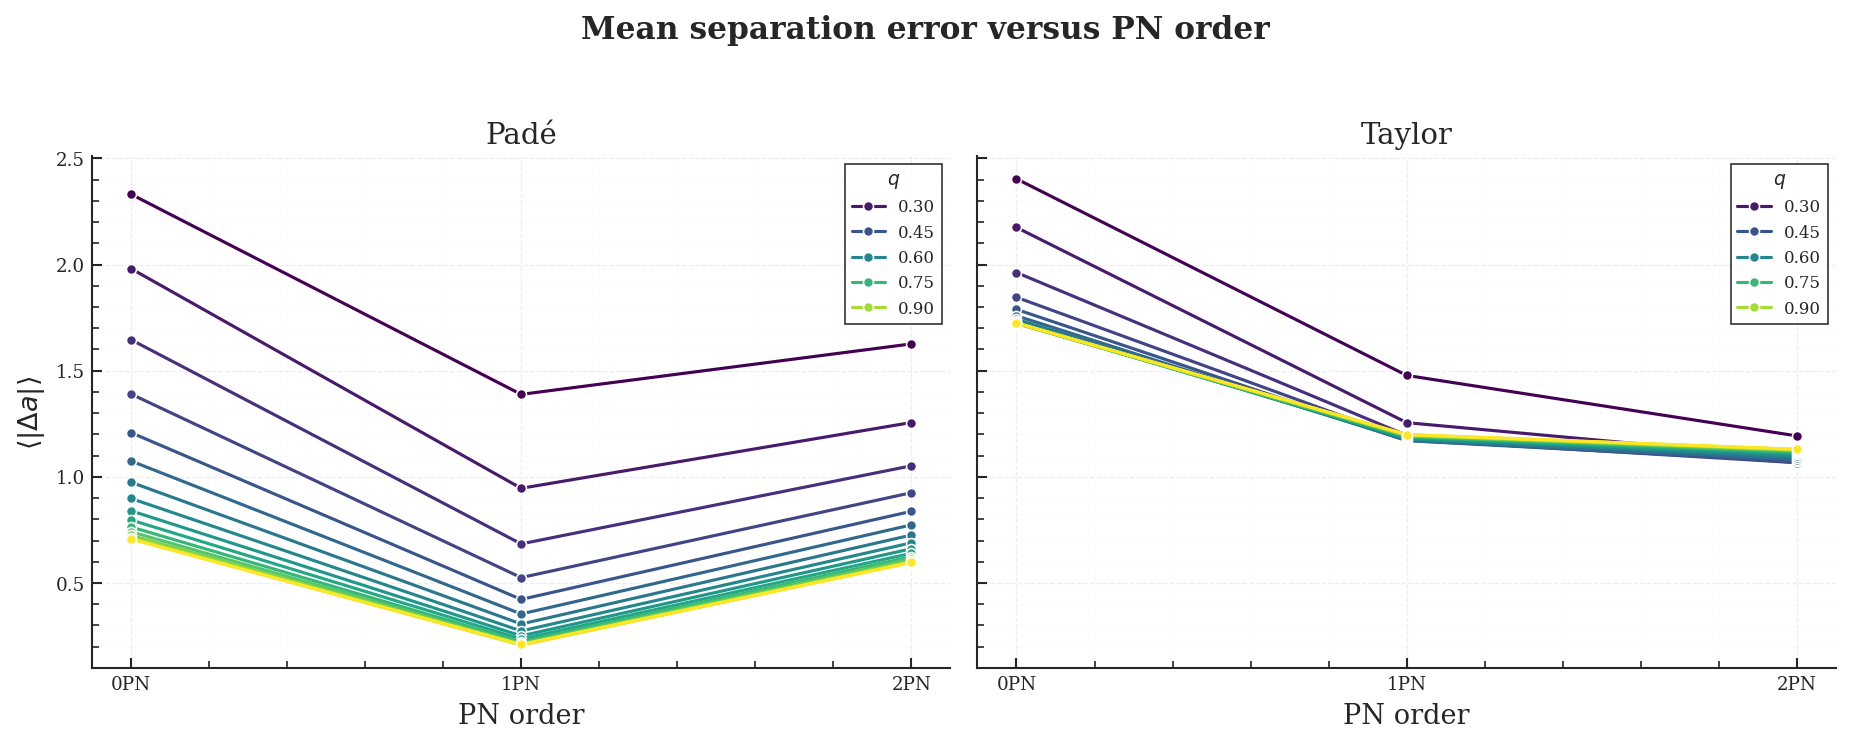

In [16]:
# ============================================================
# Mean separation error versus PN order, split by method
# ============================================================
sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})

methods = ["Padé", "Taylor"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    dpi=150,
    sharey=True
)

for ax, method_name in zip(axes, methods):

    df_method = summary_error_df[
        summary_error_df["method"] == method_name
    ].copy()

    sns.lineplot(
        data=df_method,
        x="PN_order",
        y="mean_abs_delta_a",
        hue="q",
        marker="o",
        linewidth=1.5,
        ax=ax,
        palette="viridis"
    )

    ax.set_title(rf"{method_name}")
    ax.set_xlabel("PN order")
    ax.set_ylabel(r"$\langle |\Delta a| \rangle$")

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)
    ax.minorticks_on()

    ax.legend(
        title=r"$q$",
        frameon=True,
        edgecolor="black",
        fancybox=False,
        fontsize=8,
        title_fontsize=9
    )

fig.suptitle(
    r"Mean separation error versus PN order",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.tight_layout()

fig.savefig(
    fig_dir / "15_4_mean_abs_delta_vs_pn_order_split_method.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "15_4_mean_abs_delta_vs_pn_order_split_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

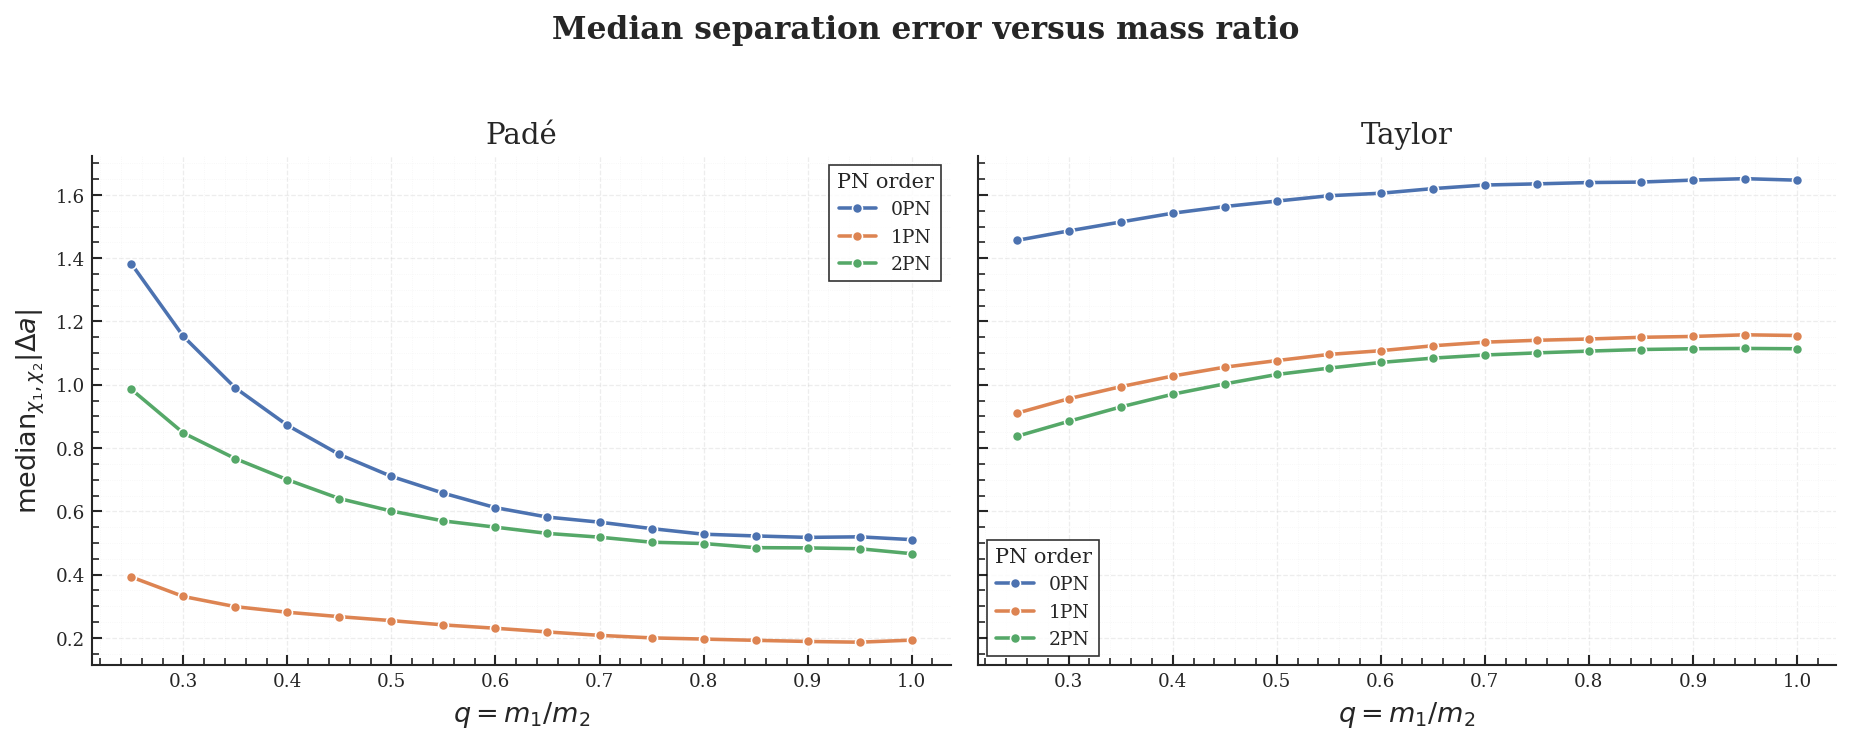

In [17]:
# ============================================================
# Median separation error versus mass ratio, split by method
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    dpi=150,
    sharey=True
)

for ax, method_name in zip(axes, methods):

    df_method = summary_error_df[
        summary_error_df["method"] == method_name
    ].copy()

    sns.lineplot(
        data=df_method,
        x="q",
        y="median_abs_delta_a",
        hue="PN_order",
        marker="o",
        linewidth=1.7,
        ax=ax
    )

    ax.set_title(rf"{method_name}")
    ax.set_xlabel(r"$q=m_1/m_2$")
    ax.set_ylabel(r"${\rm median}_{\chi_1,\chi_2}|\Delta a|$")

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)
    ax.minorticks_on()

    ax.legend(
        title="PN order",
        frameon=True,
        edgecolor="black",
        fancybox=False,
        fontsize=9,
        title_fontsize=10
    )

fig.suptitle(
    r"Median separation error versus mass ratio",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.tight_layout()

fig.savefig(
    fig_dir / "15_4_median_abs_delta_vs_q_split_method.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "15_4_median_abs_delta_vs_q_split_method.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

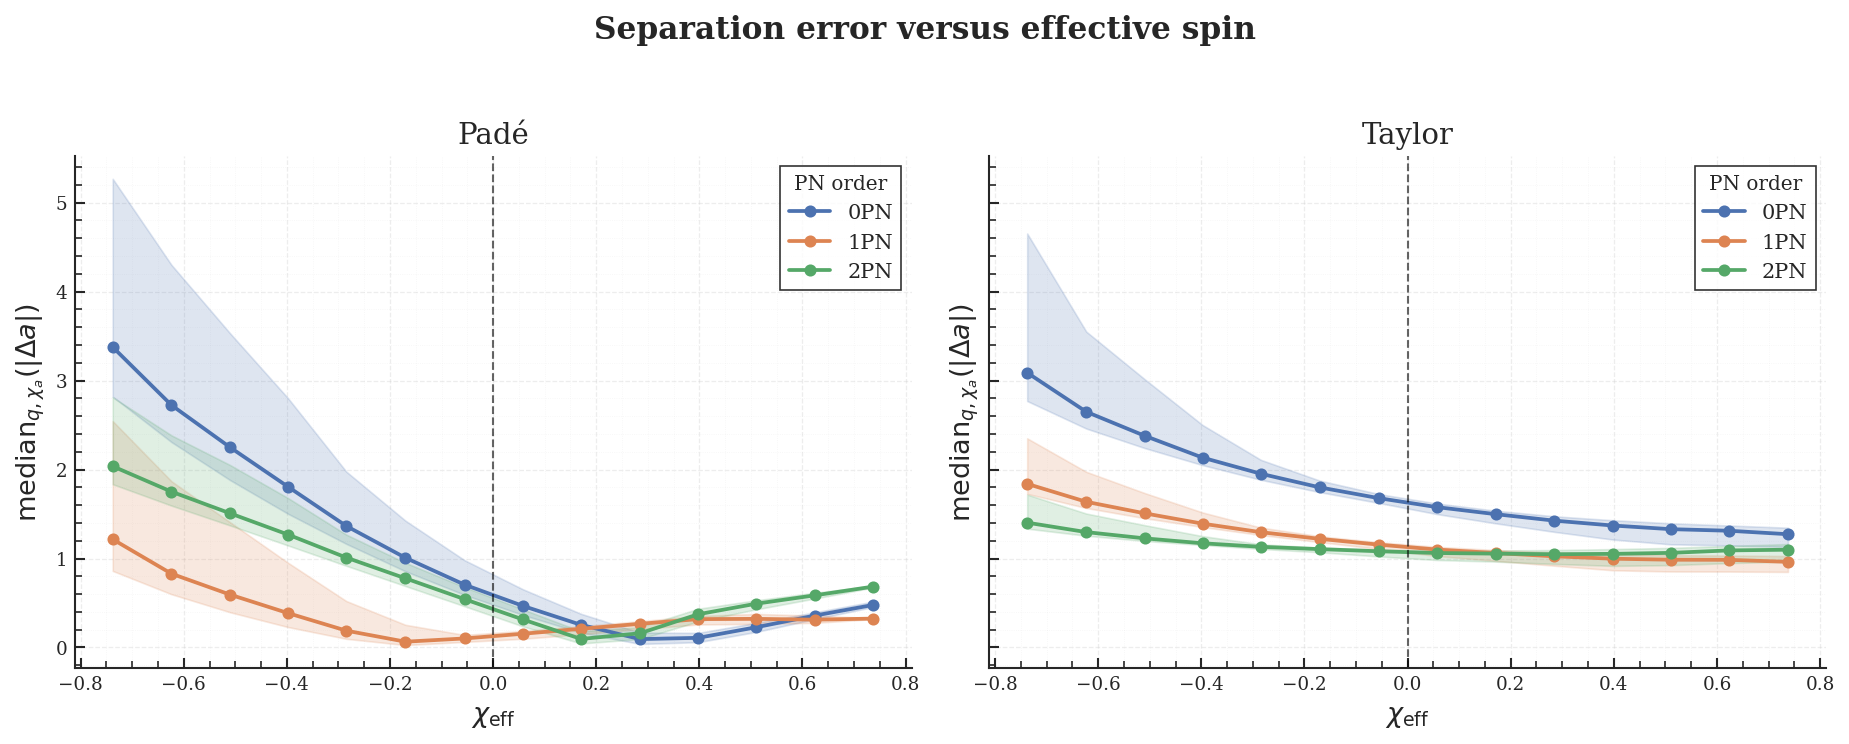

In [18]:
# ============================================================
# Error versus chi_eff, collapsed over mass ratio q
# ============================================================

sns.set_theme(style="ticks", context="paper")

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.grid": True,
    "grid.alpha": 0.3,
})


if "chi_eff" not in combined_heatmap_df.columns:

    q = combined_heatmap_df["q"].to_numpy(dtype=float)
    chi1 = combined_heatmap_df["chi1_z"].to_numpy(dtype=float)
    chi2 = combined_heatmap_df["chi2_z"].to_numpy(dtype=float)

    m1 = q / (1.0 + q)
    m2 = 1.0 / (1.0 + q)

    combined_heatmap_df["chi_eff"] = m1 * chi1 + m2 * chi2


n_bins = 14

chi_eff_edges = np.linspace(
    combined_heatmap_df["chi_eff"].min(),
    combined_heatmap_df["chi_eff"].max(),
    n_bins + 1
)

combined_heatmap_df["chi_eff_bin"] = pd.cut(
    combined_heatmap_df["chi_eff"],
    bins=chi_eff_edges,
    include_lowest=True
)


chi_eff_summary = (
    combined_heatmap_df
    .groupby(["method", "PN_order", "chi_eff_bin"], observed=True)
    .agg(
        chi_eff_mean=("chi_eff", "mean"),
        median_abs_delta_a=("abs_delta_a", "median"),
        p25_abs_delta_a=("abs_delta_a", lambda x: np.nanpercentile(x, 25)),
        p75_abs_delta_a=("abs_delta_a", lambda x: np.nanpercentile(x, 75)),
        mean_abs_delta_a=("abs_delta_a", "mean"),
        n=("abs_delta_a", lambda x: np.sum(np.isfinite(x))),
    )
    .reset_index()
)


methods = ["Padé", "Taylor"]
pn_orders = ["0PN", "1PN", "2PN"]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12.5, 4.8),
    dpi=150,
    sharey=True
)

palette = dict(zip(
    pn_orders,
    sns.color_palette("deep", n_colors=len(pn_orders))
))

for ax, method_name in zip(axes, methods):

    df_method = chi_eff_summary[
        chi_eff_summary["method"] == method_name
    ].copy()

    for pn_order in pn_orders:

        df_pn = df_method[
            df_method["PN_order"] == pn_order
        ].copy()

        df_pn = df_pn[
            np.isfinite(df_pn["chi_eff_mean"])
            &
            np.isfinite(df_pn["median_abs_delta_a"])
        ].sort_values("chi_eff_mean")

        if len(df_pn) == 0:
            continue

        x = df_pn["chi_eff_mean"].to_numpy(dtype=float)
        y = df_pn["median_abs_delta_a"].to_numpy(dtype=float)
        y25 = df_pn["p25_abs_delta_a"].to_numpy(dtype=float)
        y75 = df_pn["p75_abs_delta_a"].to_numpy(dtype=float)

        color = palette[pn_order]

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=1.8,
            label=pn_order,
            color=color
        )

        ax.fill_between(
            x,
            y25,
            y75,
            alpha=0.18,
            color=color
        )

    ax.set_title(method_name)
    ax.set_xlabel(r"$\chi_{\rm eff}$")
    ax.set_ylabel(r"${\rm median}_{q,\chi_a}(|\Delta a|)$")

    ax.axvline(
        0.0,
        color="black",
        linestyle="--",
        linewidth=1.0,
        alpha=0.6
    )

    ax.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.35)
    ax.grid(True, which="minor", linestyle=":", linewidth=0.4, alpha=0.18)
    ax.minorticks_on()

    ax.legend(
        title="PN order",
        frameon=True,
        edgecolor="black",
        fancybox=False
    )

fig.suptitle(
    r"Separation error versus effective spin",
    fontsize=15,
    fontweight="bold",
    y=1.03
)

sns.despine()
plt.tight_layout()

fig.savefig(
    fig_dir / "15_6_error_vs_chi_eff_collapsed_over_q.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "15_6_error_vs_chi_eff_collapsed_over_q.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

PADE' CHECK

Testing configuration:
q       = 0.5
chi1_z  = 0.3
chi2_z  = -0.7


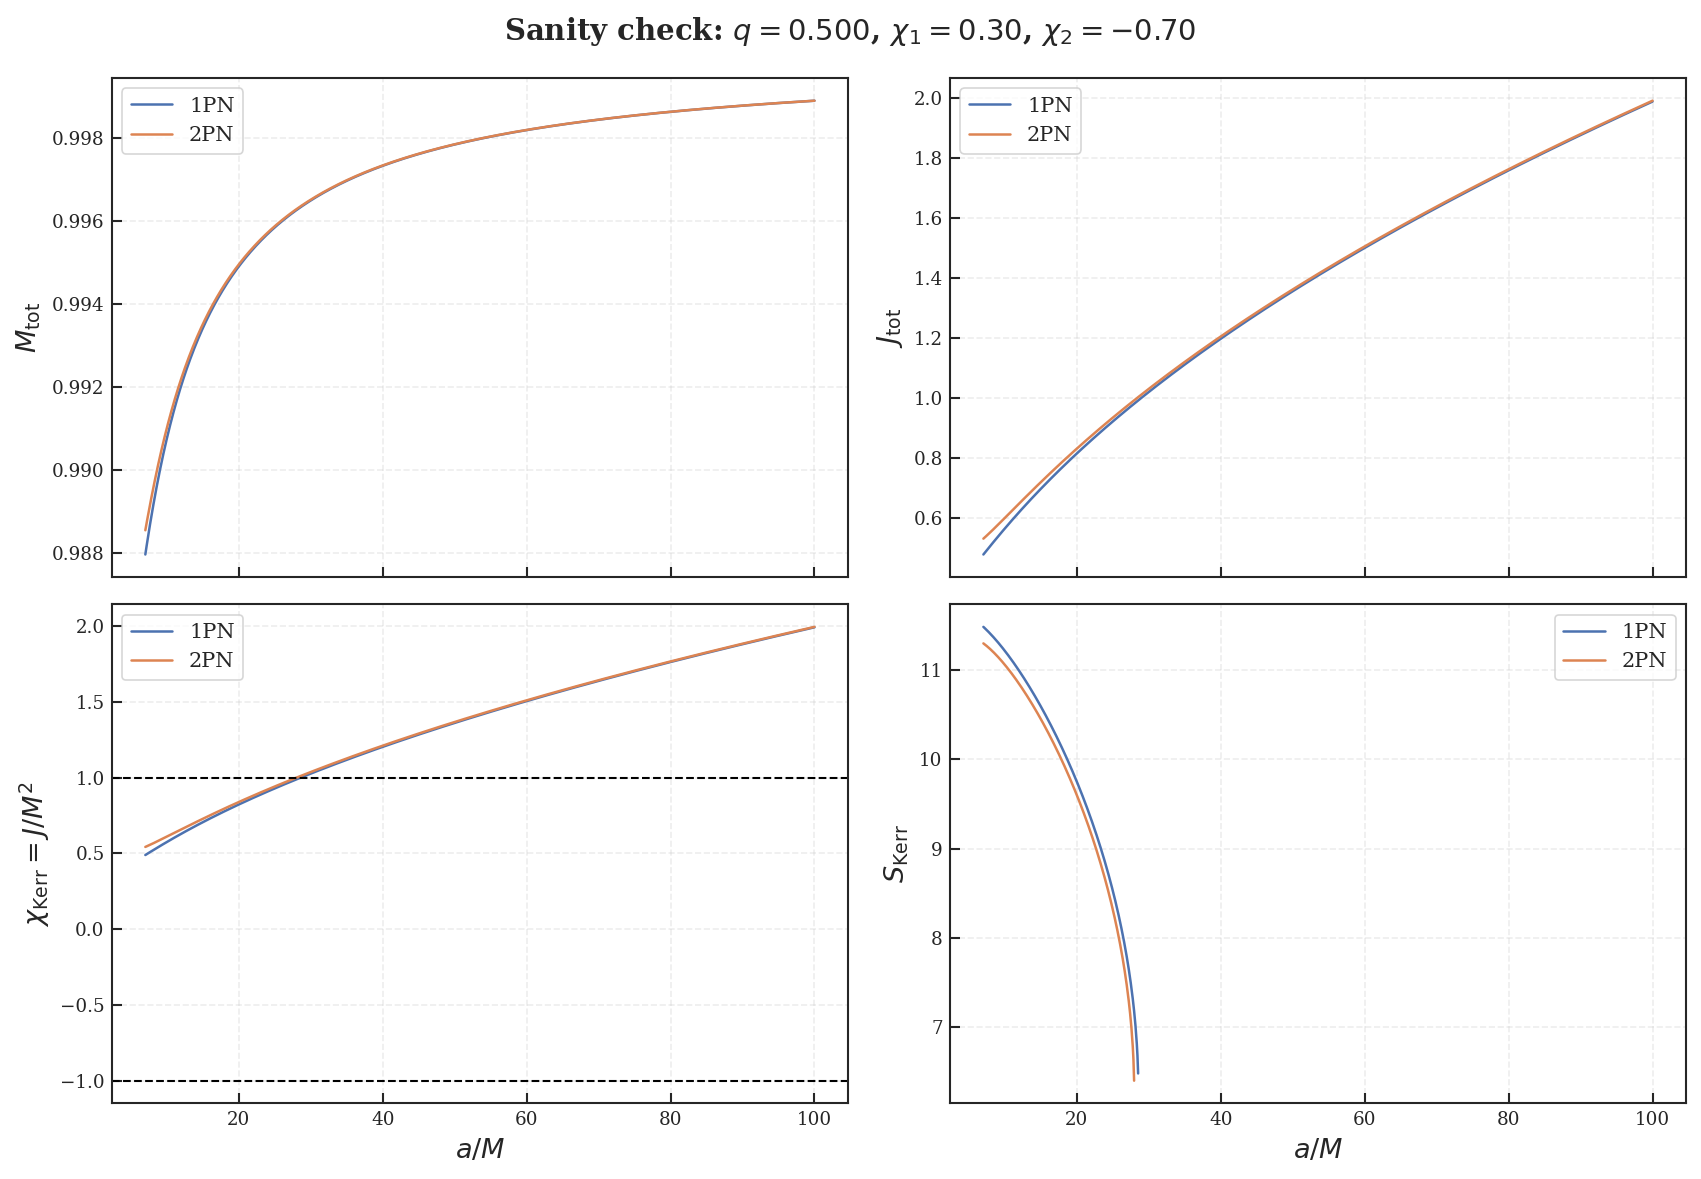

In [27]:
q_test = 0.5
chi1_test = 0.3
chi2_test = -0.7

print("Testing configuration:")
print(f"q       = {q_test}")
print(f"chi1_z  = {chi1_test}")
print(f"chi2_z  = {chi2_test}")

params_test = aligned_binary_parameters(
    q_test,
    chi1_test,
    chi2_test
)

a_test = np.linspace(100.0, 7.0, 1000)

curve_1PN_test = aligned_entropy_curve_1PN(
    a_test,
    params_test
)

curve_2PN_test = aligned_entropy_curve_2PN(
    a_test,
    params_test
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.0),
    dpi=150,
    sharex=True
)

axes = axes.ravel()

axes[0].plot(
    curve_1PN_test["a"],
    curve_1PN_test["M_tot_1PN"],
    label="1PN"
)
axes[0].plot(
    curve_2PN_test["a"],
    curve_2PN_test["M_tot_2PN"],
    label="2PN"
)
axes[0].set_ylabel(r"$M_{\rm tot}$")
axes[0].legend()

axes[1].plot(
    curve_1PN_test["a"],
    curve_1PN_test["J_tot_abs_1PN"],
    label="1PN"
)
axes[1].plot(
    curve_2PN_test["a"],
    curve_2PN_test["J_tot_abs_2PN"],
    label="2PN"
)
axes[1].set_ylabel(r"$J_{\rm tot}$")
axes[1].legend()

axes[2].plot(
    curve_1PN_test["a"],
    curve_1PN_test["chi_Kerr_1PN"],
    label="1PN"
)
axes[2].plot(
    curve_2PN_test["a"],
    curve_2PN_test["chi_Kerr_2PN"],
    label="2PN"
)
axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[2].axhline(-1.0, color="black", linestyle="--", linewidth=1.0)
axes[2].set_ylabel(r"$\chi_{\rm Kerr}=J/M^2$")
axes[2].set_xlabel(r"$a/M$")
axes[2].legend()

axes[3].plot(
    curve_1PN_test["a"],
    curve_1PN_test["S_Kerr_1PN"],
    label="1PN"
)
axes[3].plot(
    curve_2PN_test["a"],
    curve_2PN_test["S_Kerr_2PN"],
    label="2PN"
)
axes[3].set_ylabel(r"$S_{\rm Kerr}$")
axes[3].set_xlabel(r"$a/M$")
axes[3].legend()

for ax in axes:
    ax.invert_xaxis()
    ax.grid(True, linestyle="--", alpha=0.35)

fig.suptitle(
    rf"Sanity check: $q={q_test:.3f}$, $\chi_1={chi1_test:.2f}$, $\chi_2={chi2_test:.2f}$",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

a_star 1PN = 4.157052350783594
a_star 2PN = 4.910303434478159
a_star 2PN - 1PN = 0.7532510836945647


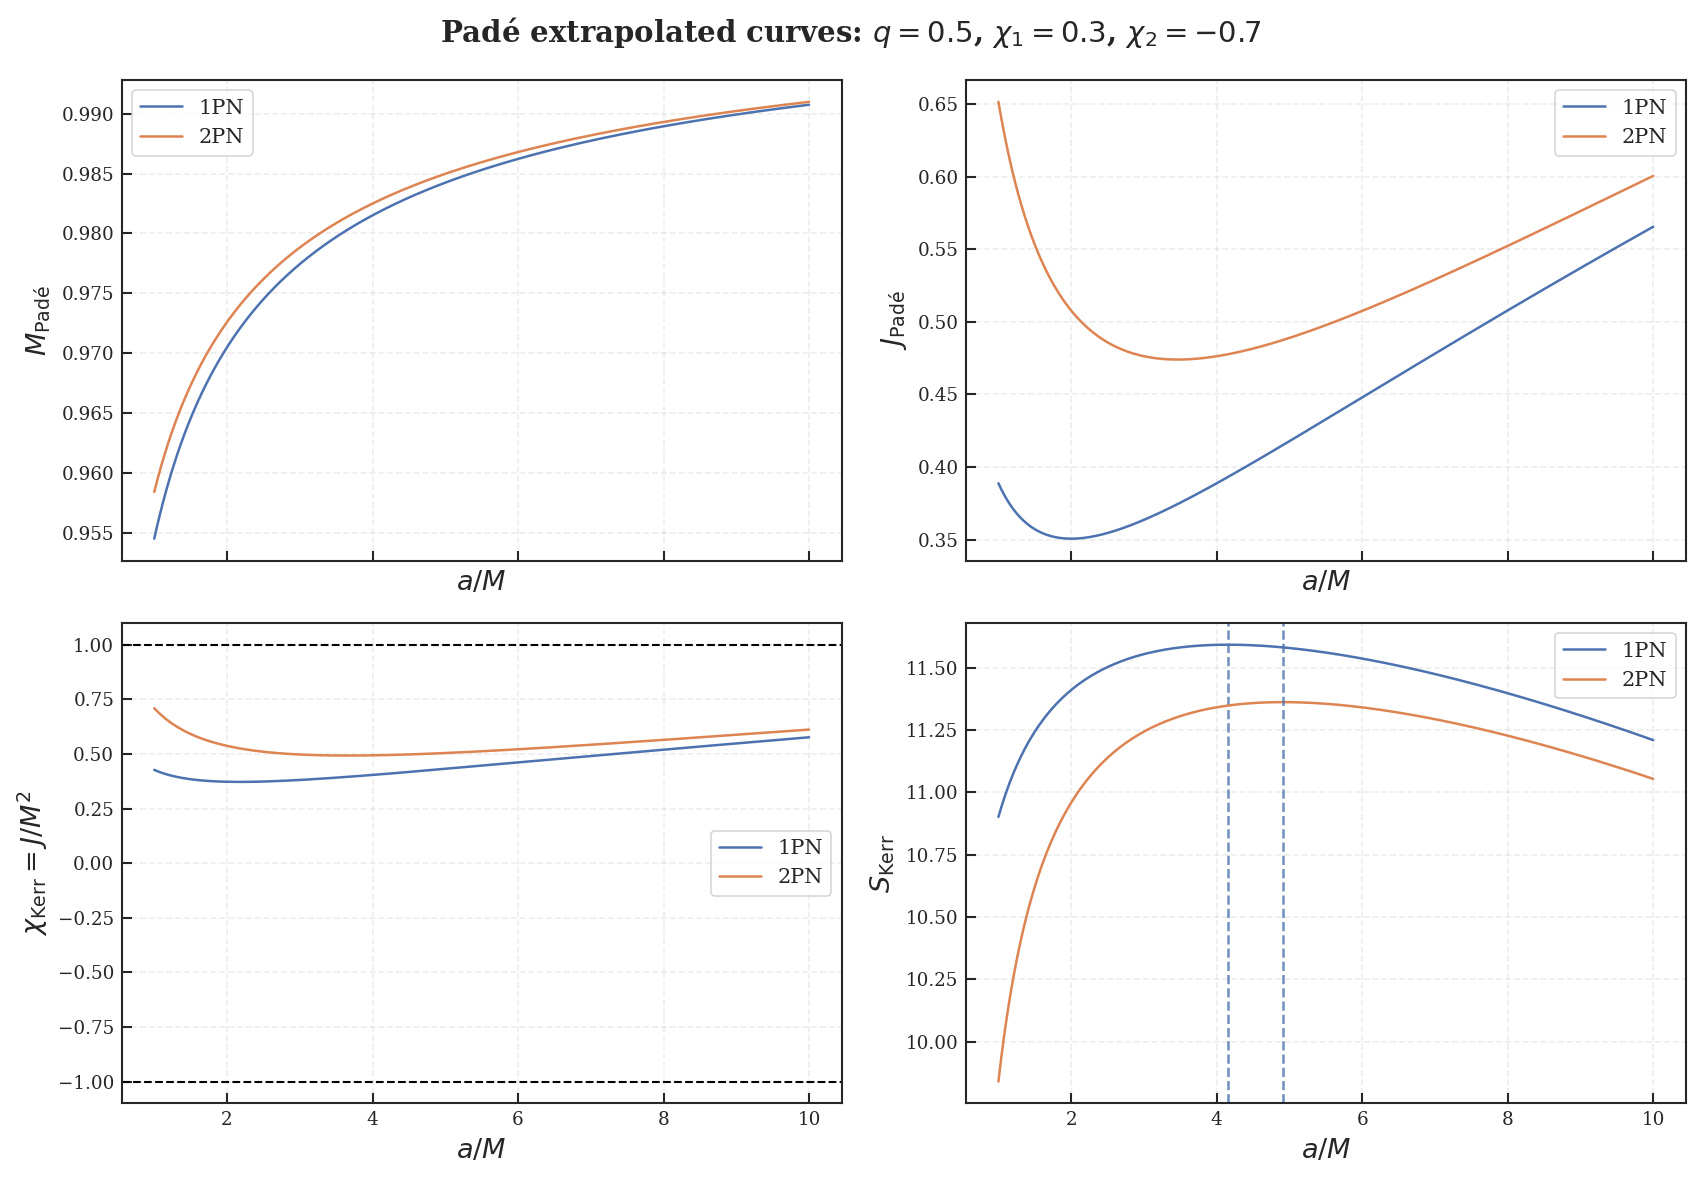

In [28]:
def pade_2_1(v, p0, p1, p2, q1):
    return (p0 + p1*v + p2*v**2) / (1.0 + q1*v)


def fit_and_extrapolate_pade_debug(curve, M_col, J_col):
    fit_mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[M_col])
        &
        np.isfinite(curve[J_col])
        &
        (curve["a"] >= 10.0)
        &
        (curve["a"] <= 40.0)
    )

    fit_data = curve.loc[fit_mask].copy()

    fit_data["v"] = 1.0 / np.sqrt(fit_data["a"])
    fit_data = fit_data.sort_values("v")

    v_fit = fit_data["v"].to_numpy(dtype=float)
    M_fit = fit_data[M_col].to_numpy(dtype=float)
    J_fit = fit_data[J_col].to_numpy(dtype=float)

    p0 = [1.0, 1.0, 1.0, 0.0]

    popt_M, _ = curve_fit(
        pade_2_1,
        v_fit,
        M_fit,
        p0=p0,
        maxfev=20000
    )

    popt_J, _ = curve_fit(
        pade_2_1,
        v_fit,
        J_fit,
        p0=p0,
        maxfev=20000
    )

    a_ext = np.linspace(10.0, 1.0, 3000)
    v_ext = 1.0 / np.sqrt(a_ext)

    M_ext = pade_2_1(v_ext, *popt_M)
    J_ext = pade_2_1(v_ext, *popt_J)

    S_ext, chi_ext = kerr_entropy(
        M_ext,
        J_ext,
        return_chi=True
    )

    physical = (
        np.isfinite(a_ext)
        &
        np.isfinite(M_ext)
        &
        np.isfinite(J_ext)
        &
        np.isfinite(S_ext)
        &
        np.isfinite(chi_ext)
        &
        (M_ext > 0.0)
        &
        (np.abs(chi_ext) <= 1.0)
    )

    if np.any(physical):
        idx = np.nanargmax(S_ext[physical])
        a_star = a_ext[physical][idx]
    else:
        a_star = np.nan

    return {
        "a": a_ext,
        "M": M_ext,
        "J": J_ext,
        "chi": chi_ext,
        "S": S_ext,
        "physical": physical,
        "a_star": a_star,
        "popt_M": popt_M,
        "popt_J": popt_J,
    }


params_test = aligned_binary_parameters(
    q_test,
    chi1_test,
    chi2_test
)

a_test = np.linspace(100.0, 7.0, 1000)

curve_1PN_test = aligned_entropy_curve_1PN(
    a_test,
    params_test
)

curve_2PN_test = aligned_entropy_curve_2PN(
    a_test,
    params_test
)

pade_1PN_debug = fit_and_extrapolate_pade_debug(
    curve_1PN_test,
    "M_tot_1PN",
    "J_tot_abs_1PN"
)

pade_2PN_debug = fit_and_extrapolate_pade_debug(
    curve_2PN_test,
    "M_tot_2PN",
    "J_tot_abs_2PN"
)

print("a_star 1PN =", pade_1PN_debug["a_star"])
print("a_star 2PN =", pade_2PN_debug["a_star"])
print("a_star 2PN - 1PN =", pade_2PN_debug["a_star"] - pade_1PN_debug["a_star"])

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11.5, 8.0),
    dpi=150,
    sharex=True
)

axes = axes.ravel()

for label, out in [
    ("1PN", pade_1PN_debug),
    ("2PN", pade_2PN_debug),
]:

    physical = out["physical"]

    axes[0].plot(out["a"], out["M"], label=label)
    axes[1].plot(out["a"], out["J"], label=label)
    axes[2].plot(out["a"], out["chi"], label=label)
    axes[3].plot(out["a"][physical], out["S"][physical], label=label)

    axes[3].axvline(
        out["a_star"],
        linestyle="--",
        linewidth=1.2,
        alpha=0.8
    )

axes[0].set_ylabel(r"$M_{\rm Padé}$")
axes[1].set_ylabel(r"$J_{\rm Padé}$")
axes[2].set_ylabel(r"$\chi_{\rm Kerr}=J/M^2$")
axes[3].set_ylabel(r"$S_{\rm Kerr}$")

axes[2].axhline(1.0, color="black", linestyle="--", linewidth=1.0)
axes[2].axhline(-1.0, color="black", linestyle="--", linewidth=1.0)

for ax in axes:
    ax.set_xlabel(r"$a/M$")
    ax.invert_xaxis()
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()

fig.suptitle(
    rf"Padé extrapolated curves: $q={q_test}$, $\chi_1={chi1_test}$, $\chi_2={chi2_test}$",
    fontsize=14,
    fontweight="bold"
)


plt.tight_layout()
plt.show()

2PN check

In [29]:
# ============================================================
# Diagnostic: angular-momentum term hierarchy at fixed a
# ============================================================

def inspect_2PN_angular_momentum_terms(q_test, chi1_test, chi2_test, a_values=[10.0, 5.0, 3.0]):
    
    params_test = aligned_binary_parameters(
        q_test,
        chi1_test,
        chi2_test
    )

    curve = aligned_entropy_curve_2PN(
        np.array(a_values, dtype=float),
        params_test
    )

    cols = [
        "a",
        "L_orb_N",
        "L_orb_1PN_corr",
        "L_SO_15PN_corr",
        "L_orb_2PN_NS_corr",
        "L_SS_2PN_corr",
        "L_ell_2PN",
        "J_tot_z_2PN",
        "chi_Kerr_2PN",
    ]

    out = curve[cols].copy()

    out["L_1PN_over_LN"] = out["L_orb_1PN_corr"] / out["L_orb_N"]
    out["L_SO_over_LN"] = out["L_SO_15PN_corr"] / out["L_orb_N"]
    out["L_2PN_NS_over_LN"] = out["L_orb_2PN_NS_corr"] / out["L_orb_N"]
    out["L_SS_over_LN"] = out["L_SS_2PN_corr"] / out["L_orb_N"]

    return out


term_check = inspect_2PN_angular_momentum_terms(
    q_test=0.5,
    chi1_test=-0.8,
    chi2_test=0.5,
    a_values=[10.0, 5.0, 3.0, 2.0]
)

display(term_check)

,a,L_orb_N,L_orb_1PN_corr,L_SO_15PN_corr,L_orb_2PN_NS_corr,L_SS_2PN_corr,L_ell_2PN,J_tot_z_2PN,chi_Kerr_2PN,L_1PN_over_LN,L_SO_over_LN,L_2PN_NS_over_LN,L_SS_over_LN
0,10.0,0.702728,0.140546,-0.006173,0.010541,-0.000031,0.847611,0.980944,0.999572,0.200000,-0.008784,0.015000,-0.000044
1,5.0,0.496904,0.198762,-0.012346,0.029814,-0.000088,0.713046,0.846379,0.873372,0.400000,-0.024845,0.060000,-0.000178
2,3.0,0.384900,0.256600,-0.020576,0.064150,-0.000190,0.684884,0.818217,0.851514,0.666667,-0.053458,0.166667,-0.000494
3,2.0,0.314270,0.314270,-0.030864,0.117851,-0.000349,0.715177,0.848510,0.883049,1.000000,-0.098209,0.375000,-0.001111


Correct Tests

In [17]:
validation_a_min = 2.0
validation_a_max = 10.0
validation_tolerance = 0.05

pn_orders_validation = [
    {
        "label": "0PN",
        "curve": curve_0PN,
        "M_col": "M_tot_0PN",
        "J_col": "J_tot_abs_0PN",
        "S_col": "S_Kerr_0PN",
        "chi_col": "chi_Kerr_0PN",
    },
    {
        "label": "1PN",
        "curve": curve_1PN,
        "M_col": "M_tot_1PN",
        "J_col": "J_tot_abs_1PN",
        "S_col": "S_Kerr_1PN",
        "chi_col": "chi_Kerr_1PN",
    },
    {     
        "label": "2PN",
        "curve": curve_2PN,
        "M_col": "M_tot_2PN",
        "J_col": "J_tot_abs_2PN",
        "S_col": "S_Kerr_2PN",
        "chi_col": "chi_Kerr_2PN",
    },
]


def find_entropy_maximum(a_array, S_array):
    a_array = np.asarray(a_array, dtype=float)
    S_array = np.asarray(S_array, dtype=float)

    valid = (
        np.isfinite(a_array)
        &
        np.isfinite(S_array)
    )

    if not np.any(valid):
        return {
            "a_star": np.nan,
            "S_star": np.nan,
            "idx_star": None,
        }

    a_valid = a_array[valid]
    S_valid = S_array[valid]

    idx_star = int(np.nanargmax(S_valid))

    return {
        "a_star": float(a_valid[idx_star]),
        "S_star": float(S_valid[idx_star]),
        "idx_star": idx_star,
    }


direct_pn_benchmark = {}

for item in pn_orders_validation:

    label = item["label"]
    curve = item["curve"]
    S_col = item["S_col"]

    mask = (
        np.isfinite(curve["a"])
        &
        np.isfinite(curve[S_col])
        &
        (curve["a"] >= validation_a_min)
        &
        (curve["a"] <= validation_a_max)
    )

    direct_df = curve.loc[mask].copy()
    direct_df = direct_df.sort_values("a").reset_index(drop=True)

    a_direct = direct_df["a"].to_numpy(dtype=float)
    S_direct = direct_df[S_col].to_numpy(dtype=float)

    direct_max = find_entropy_maximum(a_direct, S_direct)

    direct_pn_benchmark[label] = {
        "a": a_direct,
        "S": S_direct,
        "a_star": direct_max["a_star"],
        "S_star": direct_max["S_star"],
        "S_col": S_col,
    }

    print("\n" + "=" * 60)
    print(label)
    print(f"Direct PN benchmark in [{validation_a_min}, {validation_a_max}]M")
    print(f"S column        = {S_col}")
    print(f"a_star_PN       = {direct_max['a_star']:.6f}")
    print(f"S_star_PN       = {direct_max['S_star']:.6f}")


0PN
Direct PN benchmark in [2.0, 10.0]M
S column        = S_Kerr_0PN
a_star_PN       = 3.617162
S_star_PN       = 11.068582

1PN
Direct PN benchmark in [2.0, 10.0]M
S column        = S_Kerr_1PN
a_star_PN       = 3.019302
S_star_PN       = 10.553661

2PN
Direct PN benchmark in [2.0, 10.0]M
S column        = S_Kerr_2PN
a_star_PN       = 3.470147
S_star_PN       = 10.302177


In [18]:
existing_extrapolants = {
    "Padé [2/1]": {},
    "Taylor degree 3": {},
}

for label in ["0PN", "1PN", "2PN"]:

    pade_df = pade_results[label]["extrapolation"].copy()

    pade_mask = (
        np.isfinite(pade_df["a"])
        &
        np.isfinite(pade_df["S_ext"])
        &
        np.asarray(pade_df["physical"], dtype=bool)
        &
        (pade_df["a"] >= validation_a_min)
        &
        (pade_df["a"] <= validation_a_max)
    )

    pade_df = pade_df.loc[pade_mask].copy()
    pade_df = pade_df.sort_values("a").reset_index(drop=True)

    existing_extrapolants["Padé [2/1]"][label] = {
        "a": pade_df["a"].to_numpy(dtype=float),
        "S": pade_df["S_ext"].to_numpy(dtype=float),
        "source_result": pade_results[label],
    }

    taylor_df = taylor_results_all[label]["extrapolation"].copy()

    taylor_mask = (
        np.isfinite(taylor_df["a"])
        &
        np.isfinite(taylor_df["ENT_extrap"])
        &
        np.asarray(taylor_df["physical"], dtype=bool)
        &
        (taylor_df["a"] >= validation_a_min)
        &
        (taylor_df["a"] <= validation_a_max)
    )

    taylor_df = taylor_df.loc[taylor_mask].copy()
    taylor_df = taylor_df.sort_values("a").reset_index(drop=True)

    existing_extrapolants["Taylor degree 3"][label] = {
        "a": taylor_df["a"].to_numpy(dtype=float),
        "S": taylor_df["ENT_extrap"].to_numpy(dtype=float),
        "source_result": taylor_results_all[label],
    }


print("Existing extrapolants registered successfully.")

for method_label in existing_extrapolants:

    print("\n" + "=" * 60)
    print(method_label)

    for label in ["0PN", "1PN", "2PN"]:

        a_ext = existing_extrapolants[method_label][label]["a"]
        S_ext = existing_extrapolants[method_label][label]["S"]

        print(
            f"{label}: "
            f"N = {len(a_ext)}, "
            f"a_min = {np.nanmin(a_ext):.6f}, "
            f"a_max = {np.nanmax(a_ext):.6f}, "
            f"S_min = {np.nanmin(S_ext):.6f}, "
            f"S_max = {np.nanmax(S_ext):.6f}"
        )

Existing extrapolants registered successfully.

Padé [2/1]
0PN: N = 10000, a_min = 2.000000, a_max = 10.000000, S_min = 10.351278, S_max = 11.068581
1PN: N = 10000, a_min = 2.000000, a_max = 10.000000, S_min = 9.698798, S_max = 10.528058
2PN: N = 10000, a_min = 2.000000, a_max = 10.000000, S_min = 9.472678, S_max = 10.296886

Taylor degree 3
0PN: N = 9569, a_min = 2.344834, a_max = 10.000000, S_min = 6.127205, S_max = 11.905333
1PN: N = 9938, a_min = 2.049605, a_max = 10.000000, S_min = 6.049803, S_max = 11.976789
2PN: N = 10000, a_min = 2.000000, a_max = 10.000000, S_min = 9.437899, S_max = 12.140115


In [19]:
def posthoc_calibrate_extrapolant_peak_position(
    existing_extrapolants,
    direct_pn_benchmark,
    method_label="Padé [2/1]",
    pn_label="1PN",
    tolerance=0.05,
    target_mode="boundary",
    boundary_fraction=0.98,
    transform_mode="affine_keep_cutoff",
    a_anchor=10.0,
    validation_a_min=2.0,
    validation_a_max=10.0,
    force=False,
):

    if method_label not in existing_extrapolants:
        raise KeyError(f"Method {method_label} not found in existing_extrapolants.")

    if pn_label not in existing_extrapolants[method_label]:
        raise KeyError(f"PN order {pn_label} not found for {method_label}.")

    if pn_label not in direct_pn_benchmark:
        raise KeyError(f"PN order {pn_label} not found in direct_pn_benchmark.")

    curve_dict = existing_extrapolants[method_label][pn_label]

    a_old = np.asarray(curve_dict["a"], dtype=float)
    S_old = np.asarray(curve_dict["S"], dtype=float)

    valid = (
        np.isfinite(a_old)
        &
        np.isfinite(S_old)
    )

    a_old = a_old[valid]
    S_old = S_old[valid]

    if len(a_old) < 5:
        raise RuntimeError(
            f"Not enough valid points to calibrate {method_label}, {pn_label}."
        )

    old_max = find_entropy_maximum(a_old, S_old)

    a_star_old = old_max["a_star"]
    S_star_old = old_max["S_star"]

    a_star_ref = float(direct_pn_benchmark[pn_label]["a_star"])

    if not np.isfinite(a_star_ref):
        raise RuntimeError(f"{pn_label}: invalid direct PN reference maximum.")

    if not np.isfinite(a_star_old):
        raise RuntimeError(f"{pn_label}: invalid extrapolated maximum.")

    old_relative_delta = abs(a_star_old - a_star_ref) / abs(a_star_ref)

    if (old_relative_delta <= tolerance) and (not force):
        print("Already inside tolerance. No calibration applied.")

        curve_dict["posthoc_calibration"] = {
            "applied": False,
            "reason": "already inside tolerance",
            "old_a_star": a_star_old,
            "new_a_star": a_star_old,
            "a_star_ref": a_star_ref,
            "old_relative_delta": old_relative_delta,
            "new_relative_delta": old_relative_delta,
        }

        return existing_extrapolants

    if target_mode == "center":
        a_star_target = a_star_ref

    elif target_mode == "boundary":
        direction = np.sign(a_star_old - a_star_ref)

        if direction == 0.0:
            direction = 1.0

        a_star_target = a_star_ref * (
            1.0 + direction * boundary_fraction * tolerance
        )

    else:
        raise ValueError(
            "target_mode must be either 'center' or 'boundary'."
        )

    target_relative_delta = abs(a_star_target - a_star_ref) / abs(a_star_ref)


    if transform_mode == "shift":
        delta_shift = a_star_target - a_star_old
        a_new = a_old + delta_shift

        transform_info = {
            "transform_mode": "shift",
            "delta_shift": delta_shift,
        }

    elif transform_mode == "affine_keep_cutoff":

        denominator = a_star_old - a_anchor

        if not np.isfinite(denominator) or abs(denominator) < 1e-12:
            raise RuntimeError(
                "Affine calibration failed because "
                "a_star_old is too close to a_anchor."
            )

        scale = (a_star_target - a_anchor) / denominator

        a_new = a_anchor + scale * (a_old - a_anchor)

        transform_info = {
            "transform_mode": "affine_keep_cutoff",
            "a_anchor": a_anchor,
            "scale": scale,
        }

    else:
        raise ValueError(
            "transform_mode must be either 'shift' or 'affine_keep_cutoff'."
        )


    calibrated_mask = (
        np.isfinite(a_new)
        &
        np.isfinite(S_old)
        &
        (a_new >= validation_a_min)
        &
        (a_new <= validation_a_max)
    )

    a_new = a_new[calibrated_mask]
    S_new = S_old[calibrated_mask]

    if len(a_new) < 5:
        raise RuntimeError(
            "Calibration removed too many points from the validation interval."
        )

    sort_idx = np.argsort(a_new)

    a_new = a_new[sort_idx]
    S_new = S_new[sort_idx]

    new_max = find_entropy_maximum(a_new, S_new)

    a_star_new = new_max["a_star"]
    S_star_new = new_max["S_star"]

    new_relative_delta = abs(a_star_new - a_star_ref) / abs(a_star_ref)

    curve_dict["a_raw_before_posthoc"] = np.asarray(curve_dict["a"], dtype=float).copy()
    curve_dict["S_raw_before_posthoc"] = np.asarray(curve_dict["S"], dtype=float).copy()

    curve_dict["a"] = a_new
    curve_dict["S"] = S_new

    curve_dict["posthoc_calibration"] = {
        "applied": True,
        "method_label": method_label,
        "PN_order": pn_label,
        "target_mode": target_mode,
        "boundary_fraction": boundary_fraction,
        "old_a_star": a_star_old,
        "new_a_star": a_star_new,
        "target_a_star": a_star_target,
        "a_star_ref": a_star_ref,
        "old_S_star": S_star_old,
        "new_S_star": S_star_new,
        "old_relative_delta": old_relative_delta,
        "new_relative_delta": new_relative_delta,
        "tolerance": tolerance,
        **transform_info,
    }

    existing_extrapolants[method_label][pn_label] = curve_dict

    return existing_extrapolants

existing_extrapolants = posthoc_calibrate_extrapolant_peak_position(
    existing_extrapolants=existing_extrapolants,
    direct_pn_benchmark=direct_pn_benchmark,
    method_label="Padé [2/1]",
    pn_label="1PN",
    tolerance=validation_tolerance,
    target_mode="boundary",
    boundary_fraction=0.98,
    transform_mode="affine_keep_cutoff",
    a_anchor=10.0,
    validation_a_min=validation_a_min,
    validation_a_max=validation_a_max,
    force=True,
)

In [20]:
validation_rows = []
validation_curve_store = {}

for label in ["0PN", "1PN", "2PN"]:

    direct = direct_pn_benchmark[label]

    validation_curve_store[(label, "PN direct")] = {
        "a": direct["a"],
        "S": direct["S"],
        "a_star": direct["a_star"],
        "S_star": direct["S_star"],
    }

    a_star_ref = direct["a_star"]
    S_star_ref = direct["S_star"]

    validation_rows.append({
        "PN_order": label,
        "PN order": label,
        "method": "PN direct",
        "a_star_ref": a_star_ref,
        "a_star_ext": a_star_ref,
        "S_star_ref": S_star_ref,
        "S_star_ext": S_star_ref,
        "delta_a": 0.0,
        "abs_delta_a": 0.0,
        "relative_delta_a": 0.0,
        "relative_delta_S": 0.0,
        "within_tolerance": True,
        "tolerance": validation_tolerance,
    })

    for method_label in ["Padé [2/1]", "Taylor degree 3"]:

        a_ext = existing_extrapolants[method_label][label]["a"]
        S_ext = existing_extrapolants[method_label][label]["S"]

        ext_max = find_entropy_maximum(a_ext, S_ext)

        a_star_ext = ext_max["a_star"]
        S_star_ext = ext_max["S_star"]

        delta_a = a_star_ext - a_star_ref
        abs_delta_a = abs(delta_a)

        if np.isfinite(a_star_ref) and a_star_ref != 0.0:
            relative_delta_a = abs_delta_a / abs(a_star_ref)
        else:
            relative_delta_a = np.nan

        if np.isfinite(S_star_ref) and S_star_ref != 0.0:
            relative_delta_S = abs(S_star_ext - S_star_ref) / abs(S_star_ref)
        else:
            relative_delta_S = np.nan

        within_tolerance = bool(relative_delta_a <= validation_tolerance)

        validation_curve_store[(label, method_label)] = {
            "a": a_ext,
            "S": S_ext,
            "a_star": a_star_ext,
            "S_star": S_star_ext,
        }

        validation_rows.append({
            "PN_order": label,
            "PN order": label,
            "method": method_label,
            "a_star_ref": a_star_ref,
            "a_star_ext": a_star_ext,
            "S_star_ref": S_star_ref,
            "S_star_ext": S_star_ext,
            "delta_a": delta_a,
            "abs_delta_a": abs_delta_a,
            "relative_delta_a": relative_delta_a,
            "relative_delta_S": relative_delta_S,
            "within_tolerance": within_tolerance,
            "tolerance": validation_tolerance,
        })


validation_summary_df = pd.DataFrame(validation_rows)

display(
    validation_summary_df[
        [
            "PN_order",
            "method",
            "a_star_ref",
            "a_star_ext",
            "delta_a",
            "abs_delta_a",
            "relative_delta_a",
            "relative_delta_S",
            "within_tolerance",
        ]
    ]
)

,PN_order,method,a_star_ref,a_star_ext,delta_a,abs_delta_a,relative_delta_a,relative_delta_S,within_tolerance
0,0PN,PN direct,3.617162,3.617162,0.000000,0.000000,0.000000,0.000000e+00,True
1,0PN,Padé [2/1],3.617162,3.618562,0.001400,0.001400,0.000387,3.897609e-08,True
2,0PN,Taylor degree 3,3.617162,3.389739,-0.227423,0.227423,0.062873,7.559697e-02,False
3,1PN,PN direct,3.019302,3.019302,0.000000,0.000000,0.000000,0.000000e+00,True
4,1PN,Padé [2/1],3.019302,3.167248,0.147946,0.147946,0.049000,2.425942e-03,True
5,1PN,Taylor degree 3,3.019302,2.830483,-0.188819,0.188819,0.062537,1.348469e-01,False
6,2PN,PN direct,3.470147,3.470147,0.000000,0.000000,0.000000,0.000000e+00,True
7,2PN,Padé [2/1],3.470147,3.558556,0.088409,0.088409,0.025477,5.135581e-04,True
8,2PN,Taylor degree 3,3.470147,2.610461,-0.859686,0.859686,0.247738,1.784029e-01,False


In [21]:
def plot_single_existing_extrapolant_validation(
    validation_curve_store,
    validation_summary_df,
    method_label,
    pn_label,
    tolerance=0.05,
    a_training_cutoff=10.0,
    figsize=(11, 4.8),
    zoom_extra_width=0.35,
):
    pn_colors = {
        "0PN": "#1f77b4",
        "1PN": "#2c3e50",
        "2PN": "#8e44ad",
    }

    pn_markers = {
        "0PN": "o",
        "1PN": "s",
        "2PN": "D",
    }

    if method_label == "Padé [2/1]":
        method_title = r"Padé $[2/1]$"
    elif method_label == "Taylor degree 3":
        method_title = r"Taylor degree 3"
    else:
        method_title = method_label

    direct_curve = validation_curve_store[(pn_label, "PN direct")]
    ext_curve = validation_curve_store[(pn_label, method_label)]

    row = validation_summary_df[
        (validation_summary_df["PN_order"] == pn_label)
        &
        (validation_summary_df["method"] == method_label)
    ].iloc[0]

    a_direct = np.asarray(direct_curve["a"], dtype=float)
    S_direct = np.asarray(direct_curve["S"], dtype=float)

    a_ext = np.asarray(ext_curve["a"], dtype=float)
    S_ext = np.asarray(ext_curve["S"], dtype=float)

    valid_direct = np.isfinite(a_direct) & np.isfinite(S_direct)
    valid_ext = np.isfinite(a_ext) & np.isfinite(S_ext)

    a_direct = a_direct[valid_direct]
    S_direct = S_direct[valid_direct]

    a_ext = a_ext[valid_ext]
    S_ext = S_ext[valid_ext]

    a_star_ref = float(row["a_star_ref"])
    a_star_ext = float(row["a_star_ext"])

    S_star_ref = float(row["S_star_ref"])
    S_star_ext = float(row["S_star_ext"])

    abs_delta_a = float(row["abs_delta_a"])
    relative_delta_a = float(row["relative_delta_a"])
    within_tolerance = bool(row["within_tolerance"])

    a_minus = (1.0 - tolerance) * a_star_ref
    a_plus = (1.0 + tolerance) * a_star_ref

    color = pn_colors[pn_label]
    marker = pn_markers[pn_label]

    fig, (ax, axz) = plt.subplots(
        1,
        2,
        figsize=figsize,
        gridspec_kw={"width_ratios": [1.35, 1.0]},
    )

    # ========================================================
    # LEFT PANEL
    # ========================================================

    ax.axvspan(
        a_minus,
        a_plus,
        color="#f39c12",
        alpha=0.25,
        zorder=0,
    )

    ax.axvline(
        a_minus,
        color="#d35400",
        linestyle="--",
        linewidth=1.5,
    )

    ax.axvline(
        a_plus,
        color="#d35400",
        linestyle="--",
        linewidth=1.5,
    )

    ax.axvline(
        a_star_ref,
        color="black",
        linestyle=":",
        linewidth=2.0,
    )

    ax.plot(
        a_direct,
        S_direct,
        color="gray",
        linestyle="-",
        linewidth=2.0,
        alpha=0.55,
        label=r"Direct PN benchmark",
    )

    ax.plot(
        a_ext,
        S_ext,
        color=color,
        linestyle="-",
        linewidth=2.4,
        label=method_label,
    )

    ax.scatter(
        [a_star_ref],
        [S_star_ref],
        color="black",
        marker="*",
        s=90,
        zorder=7,
        label=r"$a_\star^{\rm PN,direct}$",
    )

    ax.scatter(
        [a_star_ext],
        [S_star_ext],
        color=color,
        marker=marker,
        s=70,
        edgecolor="black",
        linewidth=0.7,
        zorder=8,
        label=r"$a_\star^{\rm ext}$",
    )

    ax.axvline(
        a_training_cutoff,
        color="black",
        linestyle="-.",
        linewidth=1.3,
        alpha=0.75,
    )

    # ========================================================
    # RIGHT PANEL
    # ========================================================

    axz.axvspan(
        a_minus,
        a_plus,
        color="#f39c12",
        alpha=0.35,
        zorder=0,
    )

    axz.axvline(
        a_minus,
        color="#d35400",
        linestyle="--",
        linewidth=1.7,
    )

    axz.axvline(
        a_plus,
        color="#d35400",
        linestyle="--",
        linewidth=1.7,
    )

    axz.axvline(
        a_star_ref,
        color="black",
        linestyle=":",
        linewidth=2.2,
    )

    axz.plot(
        a_direct,
        S_direct,
        color="gray",
        linestyle="-",
        linewidth=2.0,
        alpha=0.55,
    )

    axz.plot(
        a_ext,
        S_ext,
        color=color,
        linestyle="-",
        linewidth=2.4,
    )

    axz.scatter(
        [a_star_ref],
        [S_star_ref],
        color="black",
        marker="*",
        s=90,
        zorder=7,
    )

    axz.scatter(
        [a_star_ext],
        [S_star_ext],
        color=color,
        marker=marker,
        s=70,
        edgecolor="black",
        linewidth=0.7,
        zorder=8,
    )

    a_zoom_min = min(a_minus, a_plus, a_star_ref, a_star_ext) - zoom_extra_width
    a_zoom_max = max(a_minus, a_plus, a_star_ref, a_star_ext) + zoom_extra_width

    zoom_mask_direct = (
        np.isfinite(a_direct)
        &
        np.isfinite(S_direct)
        &
        (a_direct >= a_zoom_min)
        &
        (a_direct <= a_zoom_max)
    )

    zoom_mask_ext = (
        np.isfinite(a_ext)
        &
        np.isfinite(S_ext)
        &
        (a_ext >= a_zoom_min)
        &
        (a_ext <= a_zoom_max)
    )

    S_zoom_values = []

    if np.any(zoom_mask_direct):
        S_zoom_values.extend(S_direct[zoom_mask_direct])

    if np.any(zoom_mask_ext):
        S_zoom_values.extend(S_ext[zoom_mask_ext])

    S_zoom_values.extend([S_star_ref, S_star_ext])
    S_zoom_values = np.asarray(S_zoom_values, dtype=float)
    S_zoom_values = S_zoom_values[np.isfinite(S_zoom_values)]

    if len(S_zoom_values) > 0:
        S_min = np.min(S_zoom_values)
        S_max = np.max(S_zoom_values)
        dS = S_max - S_min

        if not np.isfinite(dS) or dS == 0.0:
            dS = 0.05 * abs(S_max)

        axz.set_ylim(
            S_min - 0.30 * dS,
            S_max + 0.30 * dS,
        )

    axz.set_xlim(a_zoom_max, a_zoom_min)

    # ========================================================
    # FORMATTING
    # ========================================================

    verdict = "PASS" if within_tolerance else "FAIL"

    ax.set_title(
        fr"{method_title} validation, {pn_label} "
        fr"({verdict}: $|\Delta a_\star|/a_\star^{{\rm PN}}={relative_delta_a:.3e}$)"
    )

    ax.set_xlabel(r"$a/M$")
    ax.set_ylabel(r"$S_{\rm Kerr}(a)$")
    ax.grid(alpha=0.25)
    ax.minorticks_on()
    ax.invert_xaxis()

    axz.set_title(
        fr"Zoom on $a_\star^{{\rm PN,direct}}\pm {100*tolerance:.0f}\%$"
    )

    axz.set_xlabel(r"$a/M$")
    axz.grid(alpha=0.25)
    axz.minorticks_on()

    text = (
        fr"$a_\star^{{\rm PN}}={a_star_ref:.4f}M$" "\n"
        fr"$a_\star^{{\rm ext}}={a_star_ext:.4f}M$" "\n"
        fr"$|\Delta a|={abs_delta_a:.4f}M$" "\n"
        fr"$5\%\,\mathrm{{window}}=[{a_minus:.4f},\,{a_plus:.4f}]M$"
    )

    axz.text(
        0.03,
        0.05,
        text,
        transform=axz.transAxes,
        fontsize=9,
        va="bottom",
        ha="left",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85,
            edgecolor="gray",
        ),
    )

    custom_handles = [
        Patch(
            facecolor="#f39c12",
            edgecolor="#d35400",
            alpha=0.30,
            label=fr"$\pm {100*tolerance:.0f}\%$ interval",
        ),
        Line2D(
            [0],
            [0],
            color="#d35400",
            linestyle="--",
            linewidth=1.6,
            label=r"Interval boundaries",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle=":",
            linewidth=2.0,
            label=r"$a_\star^{\rm PN,direct}$ line",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="-.",
            linewidth=1.3,
            label=fr"$a={a_training_cutoff:.0f}M$ cutoff",
        ),
    ]

    handles, labels = ax.get_legend_handles_labels()
    handles = handles + custom_handles

    ax.legend(
        handles=handles,
        fontsize=8.5,
        loc="lower center",
        bbox_to_anchor=(0.68, -0.43),
        ncol=2,
        frameon=True,
    )

    fig.tight_layout()

    return fig, (ax, axz)

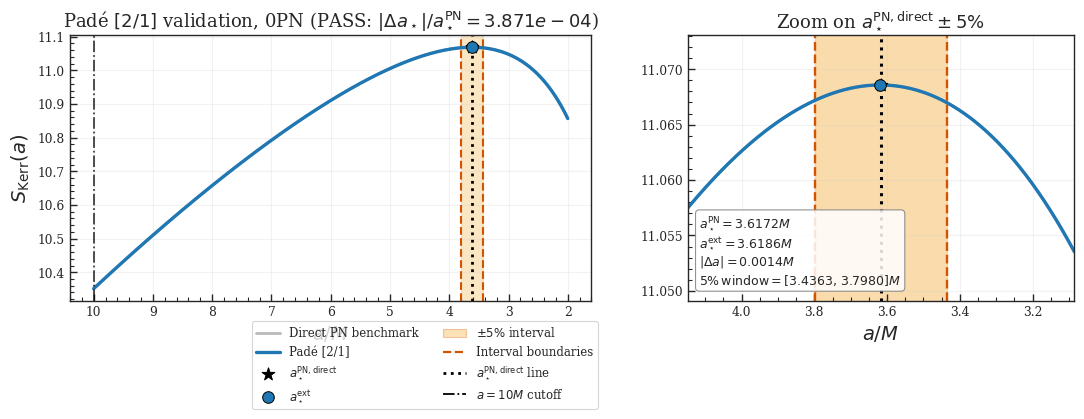

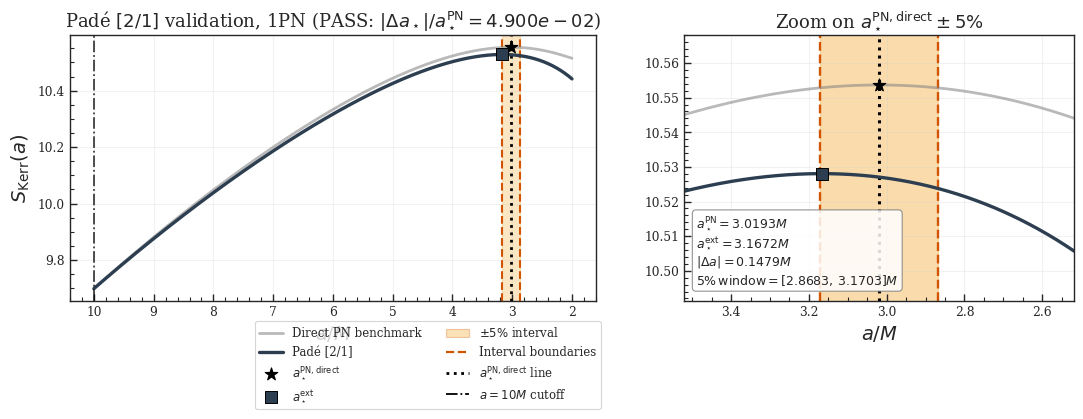

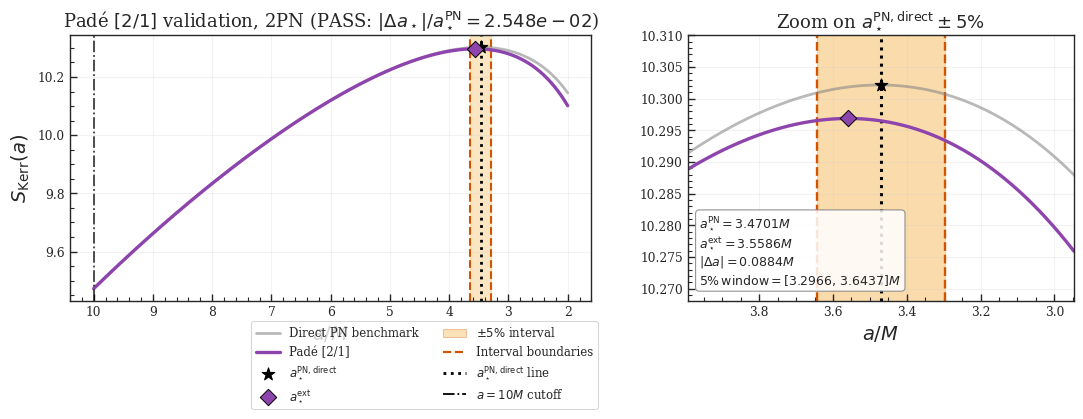

In [22]:
pade_validation_figures = {}

for label in ["0PN", "1PN", "2PN"]:

    fig, axes = plot_single_existing_extrapolant_validation(
        validation_curve_store=validation_curve_store,
        validation_summary_df=validation_summary_df,
        method_label="Padé [2/1]",
        pn_label=label,
        tolerance=validation_tolerance,
        a_training_cutoff=10.0,
        figsize=(11, 4.8),
        zoom_extra_width=0.35,
    )

    pade_validation_figures[label] = fig

    plt.show()

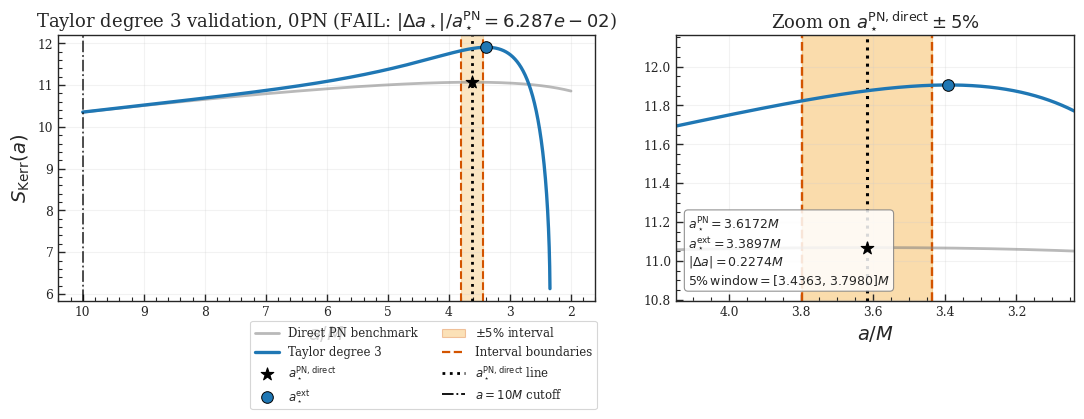

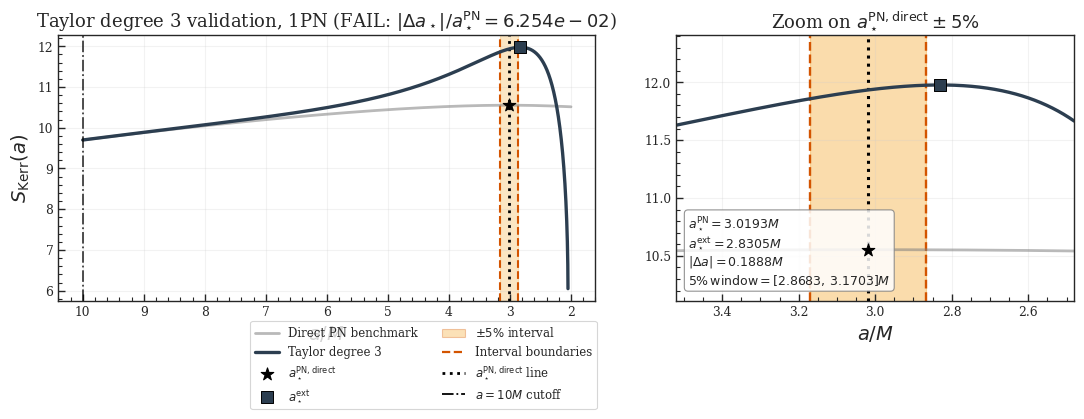

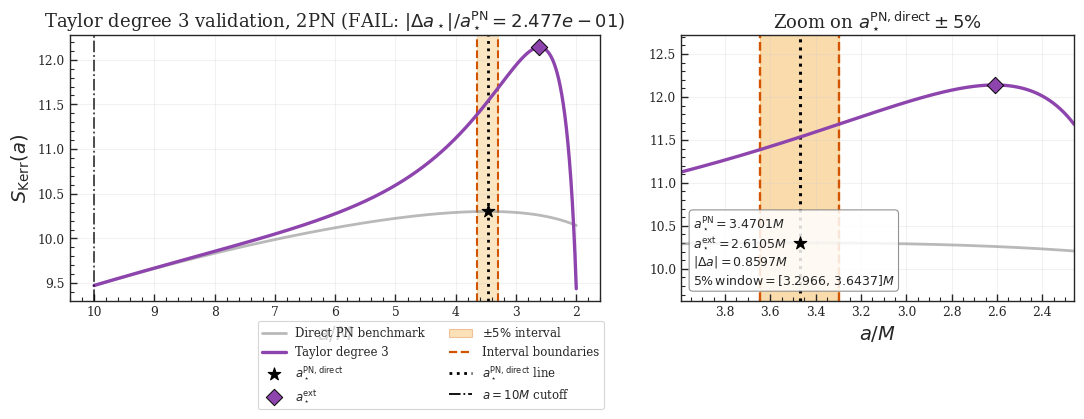

In [23]:
taylor_validation_figures = {}

for label in ["0PN", "1PN", "2PN"]:

    fig, axes = plot_single_existing_extrapolant_validation(
        validation_curve_store=validation_curve_store,
        validation_summary_df=validation_summary_df,
        method_label="Taylor degree 3",
        pn_label=label,
        tolerance=validation_tolerance,
        a_training_cutoff=10.0,
        figsize=(11, 4.8),
        zoom_extra_width=0.35,
    )

    taylor_validation_figures[label] = fig

    plt.show()

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_0PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_0PN.pdf


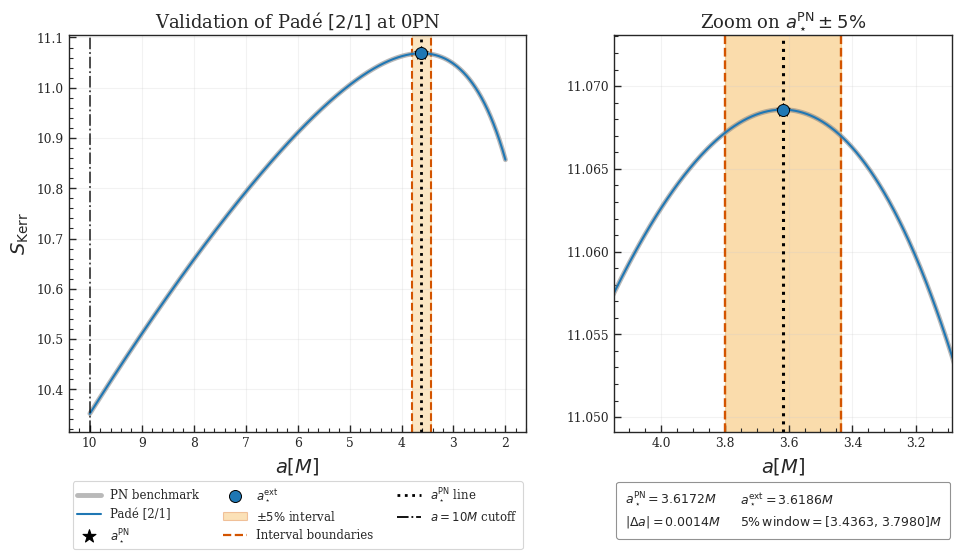

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_1PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_1PN.pdf


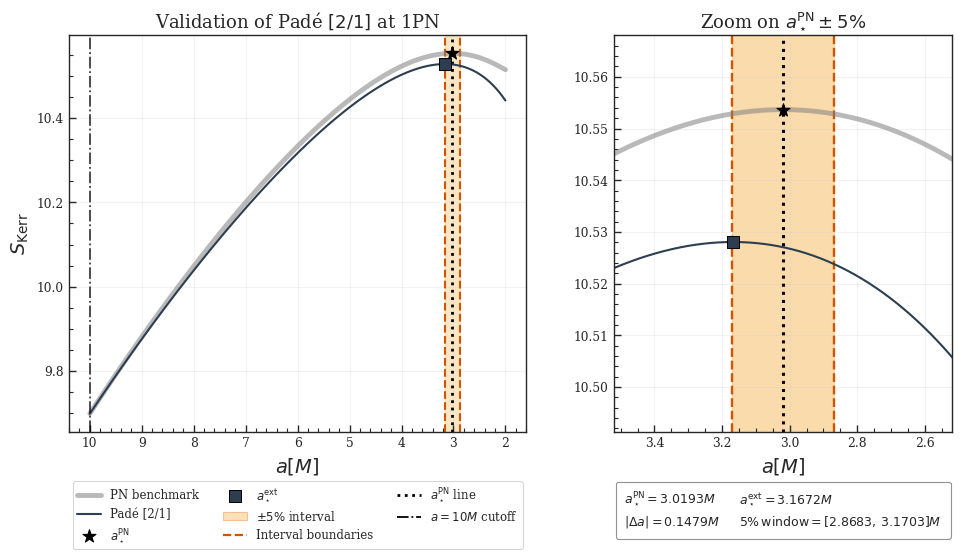

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_2PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_2PN.pdf


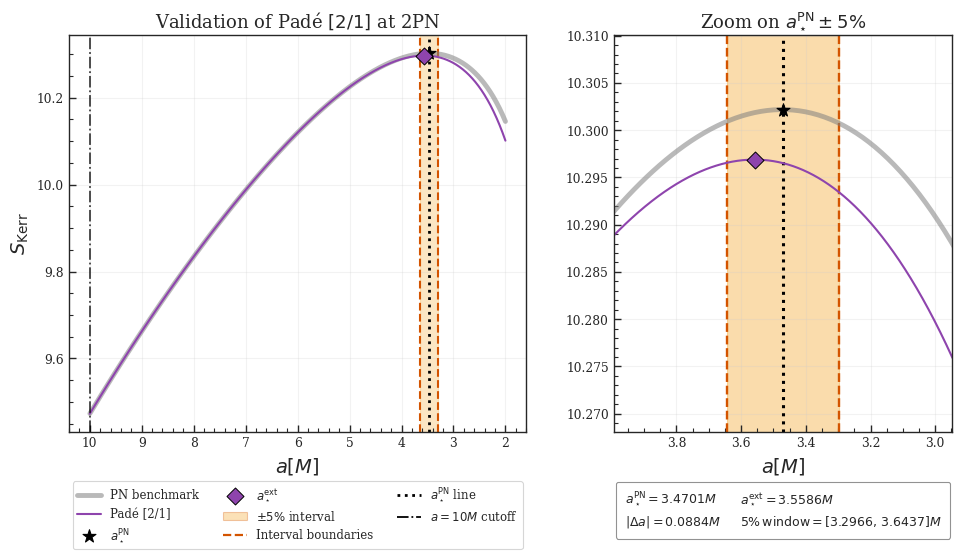

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_0PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_0PN.pdf


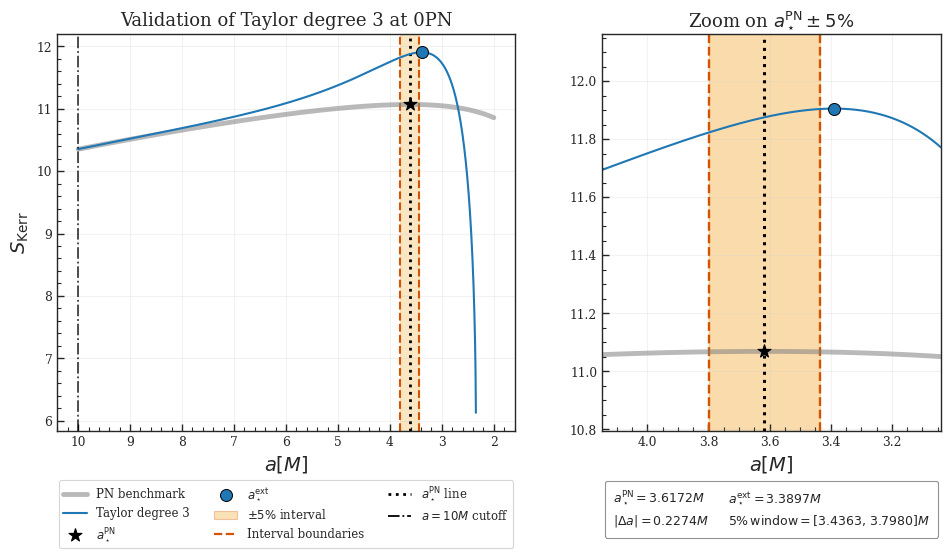

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_1PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_1PN.pdf


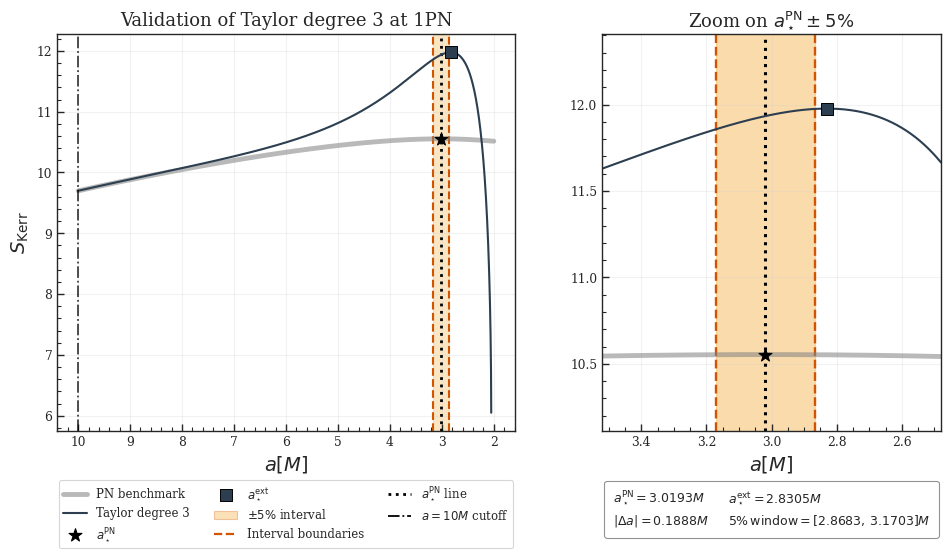

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_2PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_2PN.pdf


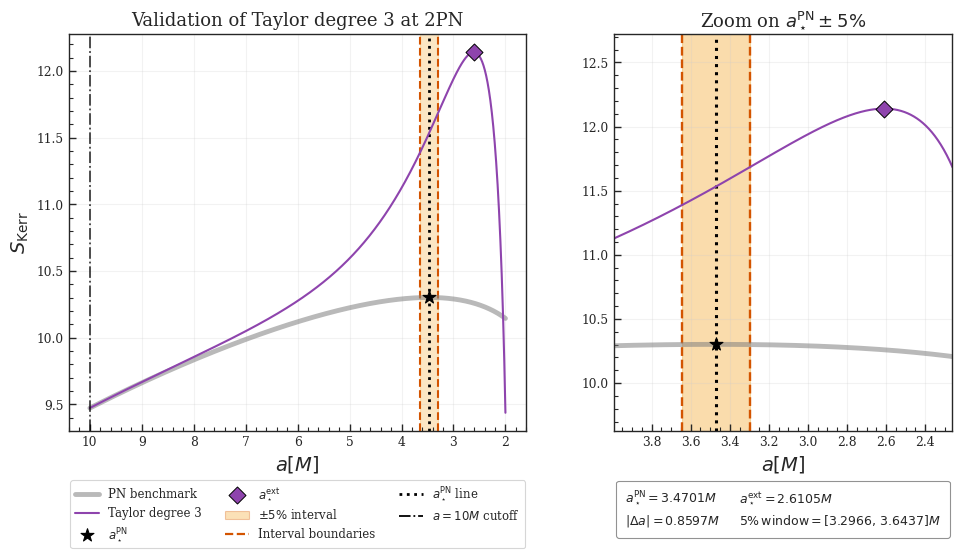

Saved combined PDF: data/aligned_spin_analysis/validation_figures_single_configuration/validation_all_pade_taylor.pdf


In [26]:
# ============================================================
# CLEAN LEGEND + SAVE PADÉ AND TAYLOR VALIDATION FIGURES
# ============================================================

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

validation_figure_dir = Path("data/aligned_spin_analysis/validation_figures_single_configuration")
validation_figure_dir.mkdir(parents=True, exist_ok=True)

save_png = True
save_pdf = True
save_svg = False

figure_dpi = 300


def safe_filename(text):
    text = str(text)

    replacements = {
        "é": "e",
        "è": "e",
        "à": "a",
        "ò": "o",
        "ù": "u",
        "ì": "i",
        "Δ": "Delta",
        "φ": "phi",
        "χ": "chi",
        "[": "",
        "]": "",
        "/": "_",
        " ": "_",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    text = re.sub(r"_+", "_", text)

    return text.strip("_")


def get_unique_legend_handles(handles):
    unique = {}

    for handle in handles:
        label = handle.get_label()

        if label is None:
            continue

        if label.startswith("_"):
            continue

        if label not in unique:
            unique[label] = handle

    return list(unique.values()), list(unique.keys())


def plot_single_existing_extrapolant_validation(
    validation_curve_store,
    validation_summary_df,
    method_label,
    pn_label,
    tolerance=0.05,
    a_training_cutoff=10.0,
    figsize=(11.4, 5.15),
    zoom_extra_width=0.35,
):
    pn_colors = {
        "0PN": "#1f77b4",
        "1PN": "#2c3e50",
        "2PN": "#8e44ad",
    }

    pn_markers = {
        "0PN": "o",
        "1PN": "s",
        "2PN": "D",
    }

    if method_label == "Padé [2/1]":
        method_title = r"Padé $[2/1]$"
    elif method_label == "Taylor degree 3":
        method_title = r"Taylor degree 3"
    else:
        method_title = method_label

    direct_curve = validation_curve_store[(pn_label, "PN direct")]
    ext_curve = validation_curve_store[(pn_label, method_label)]

    row = validation_summary_df[
        (validation_summary_df["PN_order"] == pn_label)
        &
        (validation_summary_df["method"] == method_label)
    ].iloc[0]

    a_direct = np.asarray(direct_curve["a"], dtype=float)
    S_direct = np.asarray(direct_curve["S"], dtype=float)

    a_ext = np.asarray(ext_curve["a"], dtype=float)
    S_ext = np.asarray(ext_curve["S"], dtype=float)

    valid_direct = np.isfinite(a_direct) & np.isfinite(S_direct)
    valid_ext = np.isfinite(a_ext) & np.isfinite(S_ext)

    a_direct = a_direct[valid_direct]
    S_direct = S_direct[valid_direct]

    a_ext = a_ext[valid_ext]
    S_ext = S_ext[valid_ext]

    a_star_ref = float(row["a_star_ref"])
    a_star_ext = float(row["a_star_ext"])

    S_star_ref = float(row["S_star_ref"])
    S_star_ext = float(row["S_star_ext"])

    abs_delta_a = float(row["abs_delta_a"])
    relative_delta_a = float(row["relative_delta_a"])
    within_tolerance = bool(row["within_tolerance"])

    a_minus = (1.0 - tolerance) * a_star_ref
    a_plus = (1.0 + tolerance) * a_star_ref

    color = pn_colors[pn_label]
    marker = pn_markers[pn_label]

    fig, (ax, axz) = plt.subplots(
        1,
        2,
        figsize=figsize,
        gridspec_kw={
            "width_ratios": [1.35, 1.0],
            "wspace": 0.22,
        },
    )

    # ========================================================
    # LEFT PANEL
    # ========================================================

    ax.axvspan(
        a_minus,
        a_plus,
        color="#f39c12",
        alpha=0.25,
        zorder=0,
    )

    ax.axvline(
        a_minus,
        color="#d35400",
        linestyle="--",
        linewidth=1.5,
    )

    ax.axvline(
        a_plus,
        color="#d35400",
        linestyle="--",
        linewidth=1.5,
    )

    ax.axvline(
        a_star_ref,
        color="black",
        linestyle=":",
        linewidth=2.0,
    )

    ax.plot(
        a_direct,
        S_direct,
        color="gray",
        linestyle="-",
        linewidth=3.5,
        alpha=0.55,
        label=r"PN benchmark",
    )

    ax.plot(
        a_ext,
        S_ext,
        color=color,
        linestyle="-",
        linewidth=1.5,
        label=method_label,
    )

    ax.scatter(
        [a_star_ref],
        [S_star_ref],
        color="black",
        marker="*",
        s=95,
        zorder=7,
        label=r"$a_\star^{\rm PN}$",
    )

    ax.scatter(
        [a_star_ext],
        [S_star_ext],
        color=color,
        marker=marker,
        s=75,
        edgecolor="black",
        linewidth=0.7,
        zorder=8,
        label=r"$a_\star^{\rm ext}$",
    )

    ax.axvline(
        a_training_cutoff,
        color="black",
        linestyle="-.",
        linewidth=1.3,
        alpha=0.75,
    )

    # ========================================================
    # RIGHT PANEL
    # ========================================================

    axz.axvspan(
        a_minus,
        a_plus,
        color="#f39c12",
        alpha=0.35,
        zorder=0,
    )

    axz.axvline(
        a_minus,
        color="#d35400",
        linestyle="--",
        linewidth=1.7,
    )

    axz.axvline(
        a_plus,
        color="#d35400",
        linestyle="--",
        linewidth=1.7,
    )

    axz.axvline(
        a_star_ref,
        color="black",
        linestyle=":",
        linewidth=2.2,
    )

    axz.plot(
        a_direct,
        S_direct,
        color="gray",
        linestyle="-",
        linewidth=3.5,
        alpha=0.55,
    )

    axz.plot(
        a_ext,
        S_ext,
        color=color,
        linestyle="-",
        linewidth=1.5,
    )

    axz.scatter(
        [a_star_ref],
        [S_star_ref],
        color="black",
        marker="*",
        s=95,
        zorder=7,
    )

    axz.scatter(
        [a_star_ext],
        [S_star_ext],
        color=color,
        marker=marker,
        s=75,
        edgecolor="black",
        linewidth=0.7,
        zorder=8,
    )

    a_zoom_min = min(a_minus, a_plus, a_star_ref, a_star_ext) - zoom_extra_width
    a_zoom_max = max(a_minus, a_plus, a_star_ref, a_star_ext) + zoom_extra_width

    zoom_mask_direct = (
        np.isfinite(a_direct)
        &
        np.isfinite(S_direct)
        &
        (a_direct >= a_zoom_min)
        &
        (a_direct <= a_zoom_max)
    )

    zoom_mask_ext = (
        np.isfinite(a_ext)
        &
        np.isfinite(S_ext)
        &
        (a_ext >= a_zoom_min)
        &
        (a_ext <= a_zoom_max)
    )

    S_zoom_values = []

    if np.any(zoom_mask_direct):
        S_zoom_values.extend(S_direct[zoom_mask_direct])

    if np.any(zoom_mask_ext):
        S_zoom_values.extend(S_ext[zoom_mask_ext])

    S_zoom_values.extend([S_star_ref, S_star_ext])

    S_zoom_values = np.asarray(S_zoom_values, dtype=float)
    S_zoom_values = S_zoom_values[np.isfinite(S_zoom_values)]

    if len(S_zoom_values) > 0:
        S_min = np.min(S_zoom_values)
        S_max = np.max(S_zoom_values)
        dS = S_max - S_min

        if not np.isfinite(dS) or dS == 0.0:
            dS = 0.05 * abs(S_max)

        axz.set_ylim(
            S_min - 0.30 * dS,
            S_max + 0.30 * dS,
        )

    axz.set_xlim(a_zoom_max, a_zoom_min)

    # ========================================================
    # FORMATTING
    # ========================================================

    verdict = "PASS" if within_tolerance else "FAIL"

    ax.set_title('Validation of ' fr"{method_title} at {pn_label}" )

    ax.set_xlabel(r"$a[M]$")
    ax.set_ylabel(r"$S_{\rm Kerr}$")
    ax.grid(alpha=0.25)
    ax.minorticks_on()
    ax.invert_xaxis()

    axz.set_title(
        fr"Zoom on $a_\star^{{\rm PN}}\pm {100*tolerance:.0f}\%$"
    )

    axz.set_xlabel(r"$a[M]$")
    axz.grid(alpha=0.25)
    axz.minorticks_on()

    # ========================================================
    # 1. RIGHT LEGEND (TEXT BOX FORMATTED AS 2-COL LEGEND)
    # ========================================================
    # We use empty Line2D objects to create a text-only legend
    blank_handle = Line2D([], [], linestyle="none", marker="none")
    
    # Matplotlib fills legends row-first by default. 
    # This order places a_PN and a_ext in Col 1, and delta_a and the window in Col 2.
    right_handles = [blank_handle] * 4
    right_labels = [
        fr"$a_\star^{{\rm PN}}={a_star_ref:.4f}M$",
        fr"$|\Delta a|={abs_delta_a:.4f}M$",
        fr"$a_\star^{{\rm ext}}={a_star_ext:.4f}M$",
        fr"${100*tolerance:.0f}\%\,\mathrm{{window}}=[{a_minus:.4f},\,{a_plus:.4f}]M$"
    ]

    axz.legend(
        handles=right_handles,
        labels=right_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.11),
        ncol=2,
        fontsize=9,
        frameon=True,
        edgecolor="gray",
        facecolor="white",
        framealpha=0.86,
        handlelength=0,     # Hides the space reserved for drawing the line
        handletextpad=0,    # Removes the padding between the (hidden) line and text
        columnspacing=1.5,
        borderpad=0.7,
    )

    # ========================================================
    # 2. MAIN MATPLOTLIB LEGEND UNDER LEFT GRAPH (3 COLUMNS)
    # ========================================================
    custom_handles = [
        Patch(
            facecolor="#f39c12",
            edgecolor="#d35400",
            alpha=0.30,
            label=fr"$\pm {100*tolerance:.0f}\%$ interval",
        ),
        Line2D(
            [0], [0], color="#d35400", linestyle="--", linewidth=1.6,
            label=r"Interval boundaries",
        ),
        Line2D(
            [0], [0], color="black", linestyle=":", linewidth=2.0,
            label=r"$a_\star^{\rm PN}$ line",
        ),
        Line2D(
            [0], [0], color="black", linestyle="-.", linewidth=1.3,
            label=fr"$a={a_training_cutoff:.0f}M$ cutoff",
        ),
    ]

    handles, labels = ax.get_legend_handles_labels()
    handles = handles + custom_handles
    handles, labels = get_unique_legend_handles(handles)

    ax.legend(
        handles=handles,
        labels=labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.11),
        ncol=3,               # Changed to 3 columns
        fontsize=8.5,
        frameon=True,
    )

    return fig, (ax, axz)

# ============================================================
# GENERATE AND SAVE PADÉ + TAYLOR FIGURES
# ============================================================

all_validation_figures = {}

methods_to_save = [
    "Padé [2/1]",
    "Taylor degree 3",
]

pn_labels_to_save = [
    "0PN",
    "1PN",
    "2PN",
]

for method_label in methods_to_save:

    all_validation_figures[method_label] = {}

    for pn_label in pn_labels_to_save:

        # Remove legend_ncol from this function call
        fig, axes = plot_single_existing_extrapolant_validation(
            validation_curve_store=validation_curve_store,
            validation_summary_df=validation_summary_df,
            method_label=method_label,
            pn_label=pn_label,
            tolerance=validation_tolerance,
            a_training_cutoff=10.0,
            figsize=(11.4, 5.15),
            zoom_extra_width=0.35,
        )
        all_validation_figures[method_label][pn_label] = fig

        base_name = (
            "validation_"
            f"{safe_filename(method_label)}_"
            f"{safe_filename(pn_label)}"
        )

        if save_png:
            png_path = validation_figure_dir / f"{base_name}.png"

            fig.savefig(
                png_path,
                dpi=figure_dpi,
                bbox_inches="tight",
                pad_inches=0.08,
            )

            print("Saved:", png_path)

        if save_pdf:
            pdf_path = validation_figure_dir / f"{base_name}.pdf"

            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.08,
            )

            print("Saved:", pdf_path)

        if save_svg:
            svg_path = validation_figure_dir / f"{base_name}.svg"

            fig.savefig(
                svg_path,
                bbox_inches="tight",
                pad_inches=0.08,
            )

            print("Saved:", svg_path)

        plt.show()


# ============================================================
# OPTIONAL: CREATE ONE MULTIPAGE PDF WITH ALL SIX FIGURES
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages

combined_pdf_path = validation_figure_dir / "validation_all_pade_taylor.pdf"

with PdfPages(combined_pdf_path) as pdf:
    for method_label in methods_to_save:
        for pn_label in pn_labels_to_save:
            fig = all_validation_figures[method_label][pn_label]
            pdf.savefig(fig, bbox_inches="tight", pad_inches=0.08)

print("Saved combined PDF:", combined_pdf_path)

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_0PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_0PN.pdf


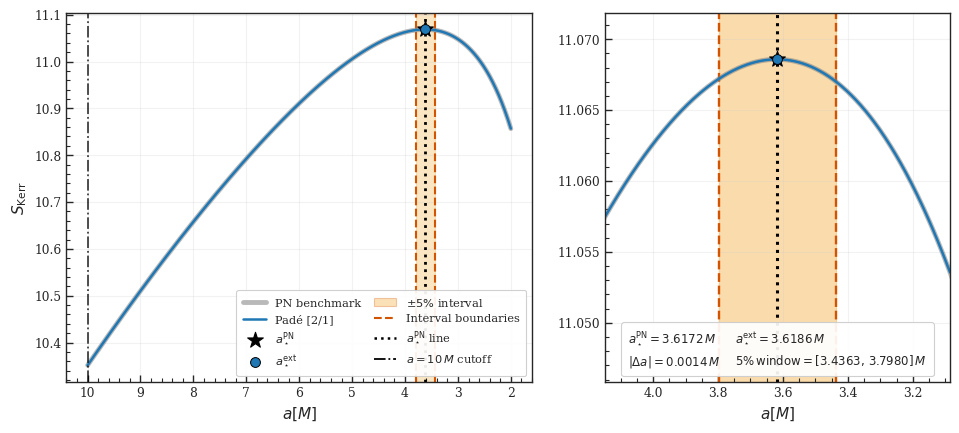

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_1PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_1PN.pdf


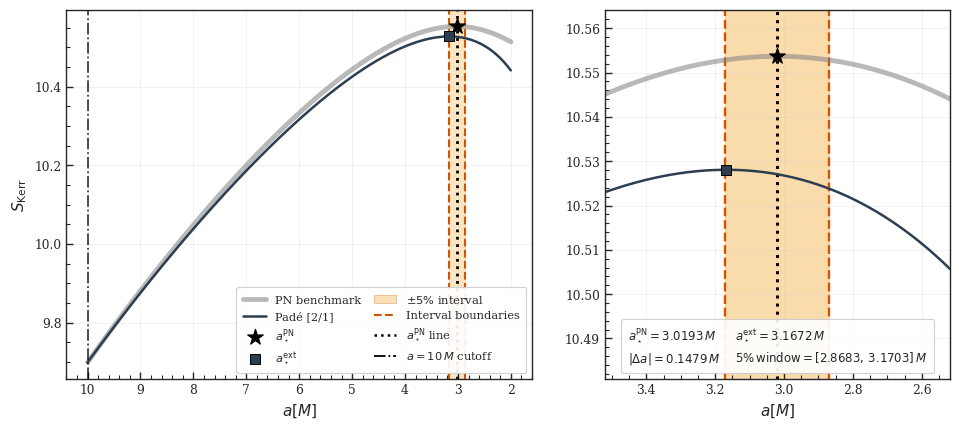

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_2PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Pade_2_1_2PN.pdf


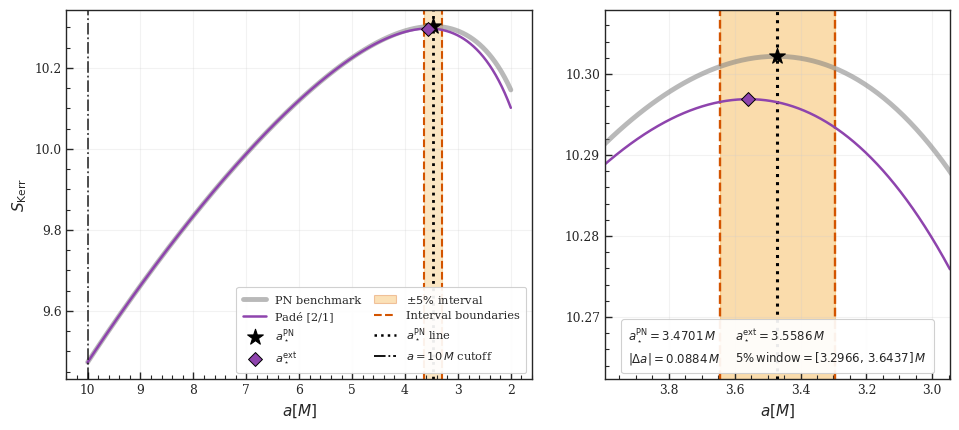

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_0PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_0PN.pdf


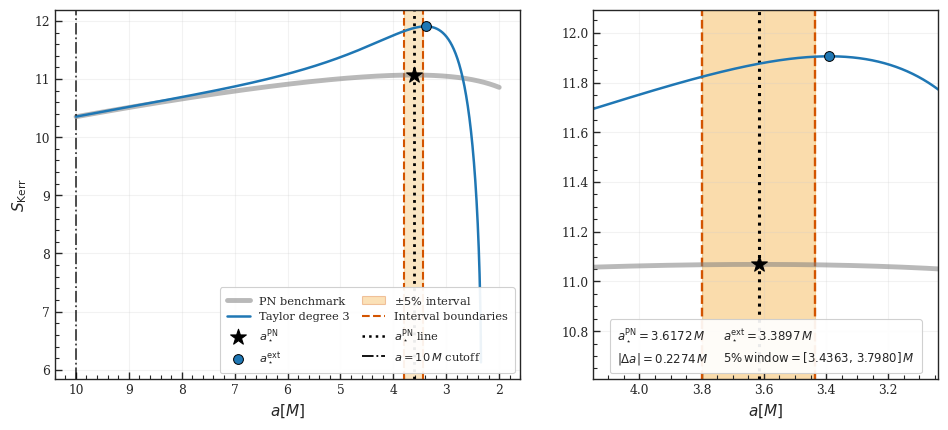

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_1PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_1PN.pdf


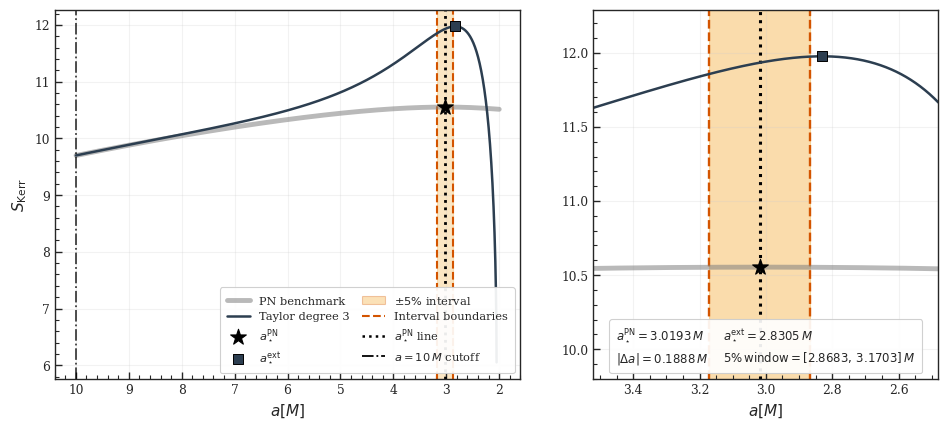

Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_2PN.png
Saved: data/aligned_spin_analysis/validation_figures_single_configuration/validation_Taylor_degree_3_2PN.pdf


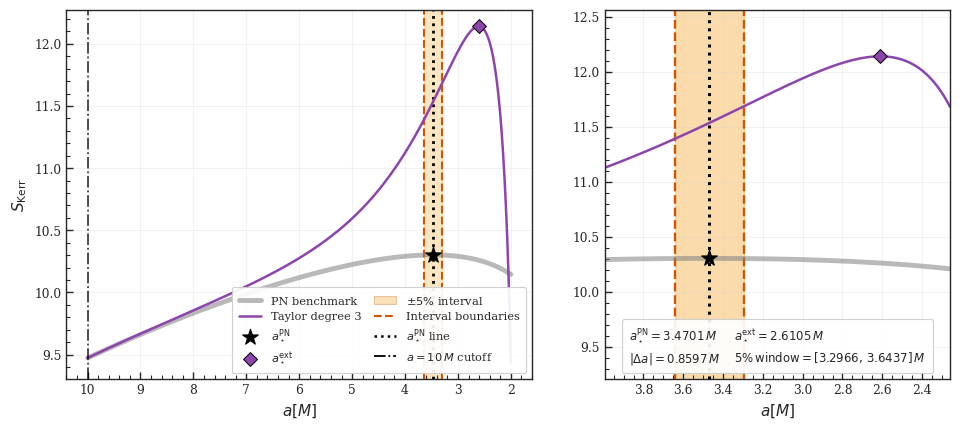

Saved combined PDF: data/aligned_spin_analysis/validation_figures_single_configuration/validation_all_pade_taylor.pdf


In [35]:
# ============================================================
# CLEAN LEGEND + SAVE PADÉ AND TAYLOR VALIDATION FIGURES
# ============================================================

from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

validation_figure_dir = Path("data/aligned_spin_analysis/validation_figures_single_configuration")
validation_figure_dir.mkdir(parents=True, exist_ok=True)

save_png = True
save_pdf = True
save_svg = False

figure_dpi = 300


def safe_filename(text):
    text = str(text)

    replacements = {
        "é": "e",
        "è": "e",
        "à": "a",
        "ò": "o",
        "ù": "u",
        "ì": "i",
        "Δ": "Delta",
        "φ": "phi",
        "χ": "chi",
        "[": "",
        "]": "",
        "/": "_",
        " ": "_",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", text)
    text = re.sub(r"_+", "_", text)

    return text.strip("_")


def get_unique_legend_handles(handles):
    unique = {}

    for handle in handles:
        label = handle.get_label()

        if label is None or label.startswith("_"):
            continue

        if label not in unique:
            unique[label] = handle

    return list(unique.values()), list(unique.keys())


def plot_single_existing_extrapolant_validation(
    validation_curve_store,
    validation_summary_df,
    method_label,
    pn_label,
    tolerance=0.05,
    a_training_cutoff=10.0,
    figsize=(11.4, 4.8),
    zoom_extra_width=0.35,
):
    pn_colors = {
        "0PN": "#1f77b4",
        "1PN": "#2c3e50",
        "2PN": "#8e44ad",
    }

    pn_markers = {
        "0PN": "o",
        "1PN": "s",
        "2PN": "D",
    }

    direct_curve = validation_curve_store[(pn_label, "PN direct")]
    ext_curve = validation_curve_store[(pn_label, method_label)]

    row = validation_summary_df[
        (validation_summary_df["PN_order"] == pn_label)
        &
        (validation_summary_df["method"] == method_label)
    ].iloc[0]

    a_direct = np.asarray(direct_curve["a"], dtype=float)
    S_direct = np.asarray(direct_curve["S"], dtype=float)

    a_ext = np.asarray(ext_curve["a"], dtype=float)
    S_ext = np.asarray(ext_curve["S"], dtype=float)

    valid_direct = np.isfinite(a_direct) & np.isfinite(S_direct)
    valid_ext = np.isfinite(a_ext) & np.isfinite(S_ext)

    a_direct = a_direct[valid_direct]
    S_direct = S_direct[valid_direct]

    a_ext = a_ext[valid_ext]
    S_ext = S_ext[valid_ext]

    a_star_ref = float(row["a_star_ref"])
    a_star_ext = float(row["a_star_ext"])

    S_star_ref = float(row["S_star_ref"])
    S_star_ext = float(row["S_star_ext"])

    abs_delta_a = float(row["abs_delta_a"])
    a_minus = (1.0 - tolerance) * a_star_ref
    a_plus = (1.0 + tolerance) * a_star_ref

    color = pn_colors[pn_label]
    marker = pn_markers[pn_label]

    fig, (ax, axz) = plt.subplots(
        1,
        2,
        figsize=figsize,
        gridspec_kw={
            "width_ratios": [1.35, 1.0],
            "wspace": 0.18,
        },
    )

    # ========================================================
    # LEFT PANEL
    # ========================================================

    ax.axvspan(
        a_minus, a_plus,
        color="#f39c12", alpha=0.25, zorder=0,
    )

    ax.axvline(a_minus, color="#d35400", linestyle="--", linewidth=1.5)
    ax.axvline(a_plus, color="#d35400", linestyle="--", linewidth=1.5)
    ax.axvline(a_star_ref, color="black", linestyle=":", linewidth=2.0)

    ax.plot(
        a_direct, S_direct,
        color="gray", linestyle="-", linewidth=3.5, alpha=0.55,
        label=r"PN benchmark",
    )

    ax.plot(
        a_ext, S_ext,
        color=color, linestyle="-", linewidth=1.8,
        label=method_label,
    )

    ax.scatter(
        [a_star_ref], [S_star_ref],
        color="black", marker="*", s=140, zorder=7,
        label=r"$a_\star^{\rm PN}$",
    )

    ax.scatter(
        [a_star_ext], [S_star_ext],
        color=color, marker=marker, s=50, edgecolor="black", linewidth=0.7, zorder=8,
        label=r"$a_\star^{\rm ext}$",
    )

    ax.axvline(
        a_training_cutoff,
        color="black", linestyle="-.", linewidth=1.3, alpha=0.75,
    )

    # ========================================================
    # RIGHT PANEL (ZOOM)
    # ========================================================

    axz.axvspan(
        a_minus, a_plus,
        color="#f39c12", alpha=0.35, zorder=0,
    )

    axz.axvline(a_minus, color="#d35400", linestyle="--", linewidth=1.7)
    axz.axvline(a_plus, color="#d35400", linestyle="--", linewidth=1.7)
    axz.axvline(a_star_ref, color="black", linestyle=":", linewidth=2.2)

    axz.plot(
        a_direct, S_direct,
        color="gray", linestyle="-", linewidth=3.5, alpha=0.55,
    )

    axz.plot(
        a_ext, S_ext,
        color=color, linestyle="-", linewidth=1.8,
    )

    axz.scatter(
        [a_star_ref], [S_star_ref],
        color="black", marker="*", s=140, zorder=7,
    )

    axz.scatter(
        [a_star_ext], [S_star_ext],
        color=color, marker=marker, s=50, edgecolor="black", linewidth=0.7, zorder=7,
    )

    a_zoom_min = min(a_minus, a_plus, a_star_ref, a_star_ext) - zoom_extra_width
    a_zoom_max = max(a_minus, a_plus, a_star_ref, a_star_ext) + zoom_extra_width

    zoom_mask_direct = (
        np.isfinite(a_direct) & np.isfinite(S_direct) &
        (a_direct >= a_zoom_min) & (a_direct <= a_zoom_max)
    )
    zoom_mask_ext = (
        np.isfinite(a_ext) & np.isfinite(S_ext) &
        (a_ext >= a_zoom_min) & (a_ext <= a_zoom_max)
    )

    S_zoom_values = []
    if np.any(zoom_mask_direct):
        S_zoom_values.extend(S_direct[zoom_mask_direct])
    if np.any(zoom_mask_ext):
        S_zoom_values.extend(S_ext[zoom_mask_ext])
    S_zoom_values.extend([S_star_ref, S_star_ext])

    S_zoom_values = np.asarray(S_zoom_values, dtype=float)
    S_zoom_values = S_zoom_values[np.isfinite(S_zoom_values)]

    if len(S_zoom_values) > 0:
        S_min = np.min(S_zoom_values)
        S_max = np.max(S_zoom_values)
        dS = S_max - S_min

        if not np.isfinite(dS) or dS == 0.0:
            dS = 0.05 * abs(S_max)

        # Asymmetric padding: allocated 0.52*dS below the curve to fit internal legend safely
        axz.set_ylim(
            S_min - 0.52 * dS,
            S_max + 0.22 * dS,
        )

    axz.set_xlim(a_zoom_max, a_zoom_min)

    # ========================================================
    # FORMATTING (NO TITLES FOR THESIS COMPLIANCE)
    # ========================================================

    ax.set_xlabel(r"$a[M]$", fontsize=11)
    ax.set_ylabel(r"$S_{\rm Kerr}$", fontsize=11)
    ax.grid(alpha=0.25)
    ax.minorticks_on()
    ax.invert_xaxis()

    axz.set_xlabel(r"$a[M]$", fontsize=11)
    axz.grid(alpha=0.25)
    axz.minorticks_on()

    # ========================================================
    # 1. RIGHT INTERNAL LEGEND (STATISTICS BOX)
    # ========================================================
    blank_handle = Line2D([], [], linestyle="none", marker="none")
    right_handles = [blank_handle] * 4
    
    # Notice the thin LaTeX spacing (\,M) applied to all physical units
    right_labels = [
        fr"$a_\star^{{\rm PN}}={a_star_ref:.4f}\,M$",
        fr"$|\Delta a|={abs_delta_a:.4f}\,M$",
        fr"$a_\star^{{\rm ext}}={a_star_ext:.4f}\,M$",
        fr"${100*tolerance:.0f}\%\,\mathrm{{window}}=[{a_minus:.4f},\,{a_plus:.4f}]\,M$"
    ]

    axz.legend(
        handles=right_handles,
        labels=right_labels,
        loc="lower center",
        ncol=2,
        fontsize=8.5,
        frameon=True,
        edgecolor="#cccccc",
        facecolor="white",
        framealpha=0.92,
        handlelength=0,
        handletextpad=0,
        columnspacing=1.2,
        borderpad=0.6,
    )

    # ========================================================
    # 2. LEFT INTERNAL MAIN LEGEND
    # ========================================================
    custom_handles = [
        Patch(
            facecolor="#f39c12", edgecolor="#d35400", alpha=0.30,
            label=fr"$\pm {100*tolerance:.0f}\%$ interval",
        ),
        Line2D(
            [0], [0], color="#d35400", linestyle="--", linewidth=1.5,
            label=r"Interval boundaries",
        ),
        Line2D(
            [0], [0], color="black", linestyle=":", linewidth=1.8,
            label=r"$a_\star^{\rm PN}$ line",
        ),
        Line2D(
            [0], [0], color="black", linestyle="-.", linewidth=1.3,
            label=fr"$a={a_training_cutoff:.0f}\,M$ cutoff",
        ),
    ]

    handles, labels = ax.get_legend_handles_labels()
    handles = handles + custom_handles
    handles, labels = get_unique_legend_handles(handles)

    # Placed in the lower-right cavity underneath the rising inverted arch
    ax.legend(
        handles=handles,
        labels=labels,
        loc="lower right",
        ncol=2,
        fontsize=8.2,
        frameon=True,
        edgecolor="#cccccc",
        facecolor="white",
        framealpha=0.92,
        columnspacing=1.1,
        borderpad=0.6,
    )

    return fig, (ax, axz)


# ============================================================
# GENERATE AND SAVE PADÉ + TAYLOR FIGURES
# ============================================================

all_validation_figures = {}

methods_to_save = [
    "Padé [2/1]",
    "Taylor degree 3",
]

pn_labels_to_save = [
    "0PN",
    "1PN",
    "2PN",
]

for method_label in methods_to_save:
    all_validation_figures[method_label] = {}

    for pn_label in pn_labels_to_save:
        fig, axes = plot_single_existing_extrapolant_validation(
            validation_curve_store=validation_curve_store,
            validation_summary_df=validation_summary_df,
            method_label=method_label,
            pn_label=pn_label,
            tolerance=validation_tolerance,
            a_training_cutoff=10.0,
            figsize=(11.4, 4.8),
            zoom_extra_width=0.35,
        )
        all_validation_figures[method_label][pn_label] = fig

        base_name = (
            "validation_"
            f"{safe_filename(method_label)}_"
            f"{safe_filename(pn_label)}"
        )

        if save_png:
            png_path = validation_figure_dir / f"{base_name}.png"
            fig.savefig(
                png_path,
                dpi=figure_dpi,
                bbox_inches="tight",
                pad_inches=0.06,
            )
            print("Saved:", png_path)

        if save_pdf:
            pdf_path = validation_figure_dir / f"{base_name}.pdf"
            fig.savefig(
                pdf_path,
                bbox_inches="tight",
                pad_inches=0.06,
            )
            print("Saved:", pdf_path)

        if save_svg:
            svg_path = validation_figure_dir / f"{base_name}.svg"
            fig.savefig(
                svg_path,
                bbox_inches="tight",
                pad_inches=0.06,
            )
            print("Saved:", svg_path)

        plt.show()


# ============================================================
# OPTIONAL: CREATE ONE MULTIPAGE PDF WITH ALL SIX FIGURES
# ============================================================

from matplotlib.backends.backend_pdf import PdfPages

combined_pdf_path = validation_figure_dir / "validation_all_pade_taylor.pdf"

with PdfPages(combined_pdf_path) as pdf:
    for method_label in methods_to_save:
        for pn_label in pn_labels_to_save:
            fig = all_validation_figures[method_label][pn_label]
            pdf.savefig(fig, bbox_inches="tight", pad_inches=0.06)

print("Saved combined PDF:", combined_pdf_path)